# EDA — Section 1: Data Loading & Missing Value Handling
### Hospital Operations & Revenue Risk Intelligence Platform
---

**Phase 2 | Healthcare Analytics Capstone**

This notebook covers the first stage of EDA:
1. Loading the merged dataset
2. Initial inspection (data types, descriptive statistics)
3. Identifying and handling missing values

**Two columns have missing values in this dataset:**

| Column | Missing Count | Strategy |
|--------|--------------|----------|
| `approved_amount` | 1,318 rows | Impute using business logic per `claim_status` and `insurance_provider` |
| `payment_days` | 790 rows | Drop rows — <5% of data, class balance preserved |

> **Note on imputation safety:** All imputation targets *only* the NULL rows using an
> `isnull()` condition. This ensures existing non-null values are never overwritten.


## 0. Setup

Import all required libraries. Only `pandas` and `numpy` are needed for this
section — visualisation libraries will be imported in later EDA sections.


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy.stats as stats

print("Libraries loaded successfully.")


Libraries loaded successfully.


---
## 1. Load Data

We load the pre-merged dataset from the `processed` folder.
This file was produced by joining `patients`, `visits`, and `billing` on their
respective keys. Each row represents one visit with all patient and billing
attributes attached.


In [2]:
DATA_PATH = "/Users/narendrafuloria/Desktop/Capstone_IITM/capstone_healthcare_analytics/data/processed/merged_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 25,000 rows × 20 columns


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,ICU,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26


---
## 2. Initial Inspection

Before handling any missing values, we inspect the dataset structure —
data types, non-null counts, and basic descriptive statistics.
This gives us the full picture of what we're working with.


### 2.1 Descriptive Statistics

`describe()` summarises all numeric columns.
Key things to look for: min/max sanity (e.g. no negative ages or stay hours),
and whether `approved_amount` and `payment_days` show lower `count` values than
the others — which confirms those columns have missing values.


In [3]:
df.describe()


,patient_id,age,chronic_flag,visit_id,length_of_stay_hours,doctor_id,bill_id,billed_amount,approved_amount,payment_days
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23682.000000,24210.000000
mean,2509.51536,44.768320,0.502600,12500.500000,19.551584,150.172400,12500.500000,20870.757442,16348.107777,13.048079
std,1448.68904,17.784232,0.500003,7217.022701,12.314004,29.135796,7217.022701,12606.285782,13778.804779,7.237736
min,1.00000,1.000000,0.000000,1.000000,0.500000,100.000000,1.000000,500.000000,0.000000,1.000000
25%,1249.00000,33.000000,0.000000,6250.750000,9.960000,125.000000,6250.750000,11582.450000,4603.070000,8.000000
50%,2505.00000,45.000000,1.000000,12500.500000,18.205000,151.000000,12500.500000,19644.850000,14379.645000,13.000000
75%,3764.00000,57.000000,1.000000,18750.250000,27.312500,175.000000,18750.250000,28398.065000,24845.020000,17.000000
max,5000.00000,90.000000,1.000000,25000.000000,78.420000,200.000000,25000.000000,88539.010000,88539.010000,55.000000


### 2.2 Column Data Types and Non-Null Counts

`info()` tells us the data type of every column and how many non-null values
each has. Columns where `Non-Null Count` is less than the total row count (25,000)
have missing values.

Note that the three date columns (`registration_date`, `visit_date`, `billing_date`)
currently show as `object` (string) type — we will convert them to `datetime` next.


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            25000 non-null  int64  
 1   age                   25000 non-null  int64  
 2   gender                25000 non-null  object 
 3   city                  25000 non-null  object 
 4   insurance_provider    25000 non-null  object 
 5   chronic_flag          25000 non-null  int64  
 6   registration_date     25000 non-null  object 
 7   visit_id              25000 non-null  int64  
 8   visit_date            25000 non-null  object 
 9   department            25000 non-null  object 
 10  visit_type            25000 non-null  object 
 11  length_of_stay_hours  25000 non-null  float64
 12  risk_score            25000 non-null  object 
 13  doctor_id             25000 non-null  int64  
 14  bill_id               25000 non-null  int64  
 15  billed_amount      

### 2.3 Convert Date Columns to datetime

The three date columns are loaded as strings by default. We convert them to
`datetime64` so that we can perform date arithmetic later (e.g. checking whether
`visit_date` falls after `registration_date`, computing billing lag).


In [5]:
date_columns = ["registration_date", "visit_date", "billing_date"]
df[date_columns] = df[date_columns].apply(pd.to_datetime)

print("Date columns converted. Updated dtypes:")
print(df[date_columns].dtypes)


Date columns converted. Updated dtypes:
registration_date    datetime64[ns]
visit_date           datetime64[ns]
billing_date         datetime64[ns]
dtype: object


Confirming the full schema after date conversion:


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

---
## 3. Missing Value Analysis

We count the number of NULL values in every column and calculate the percentage
relative to total rows. This tells us the *scale* of the problem before we
decide what to do about it.


In [7]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
}).sort_values("Missing %", ascending=False)

# Show only columns that actually have missing values
missing_report = missing_report[missing_report["Missing Count"] > 0]

print(f"Total rows in dataset: {len(df):,}")
print(f"Columns with missing values: {len(missing_report)}\n")
print(missing_report.to_string())


Total rows in dataset: 25,000
Columns with missing values: 2

                 Missing Count  Missing %
approved_amount           1318       5.27
payment_days               790       3.16


**Findings:**

- `approved_amount`: **1,318 rows** (~5.3%) have NULL values
- `payment_days`: **790 rows** (~3.2%) have NULL values
- All other columns are complete — no action needed elsewhere

These two columns are handled separately below because the reason for
missingness is different in each case, and therefore the correct fix is different.


---
## 4. Handling Missing Values in `approved_amount`

### Why are values missing?

Before deciding how to handle the 1,318 NULL rows in `approved_amount`, we
need to understand *why* they are missing. If the missingness is tied to
`claim_status`, it may be a business rule rather than a data error — and
the correct fix is different in each case.

We start by breaking down the 1,318 NULL rows by `claim_status`.


### 4.1 Inspect NULL Rows


In [8]:
# All rows where approved_amount is NULL
null_approved_rows = df[df["approved_amount"].isnull()]

print(f"Total rows with NULL approved_amount: {len(null_approved_rows):,}")
print(f"\nBreakdown by claim_status:")
print(null_approved_rows["claim_status"].value_counts())
print(f"\nAs percentages:")
print(null_approved_rows["claim_status"].value_counts(normalize=True).mul(100).round(2))


Total rows with NULL approved_amount: 1,318

Breakdown by claim_status:
claim_status
Paid        817
Pending     301
Rejected    200
Name: count, dtype: int64

As percentages:
claim_status
Paid        61.99
Pending     22.84
Rejected    15.17
Name: proportion, dtype: float64


**Interpretation:**

The NULL rows are spread across **all three** claim statuses — not just one.
This tells us the missingness is not a single business rule but three different situations:

| `claim_status` | NULL count | Correct action |
|---|---|---|
| **Rejected** | 200 | Set `approved_amount = 0` — rejected claims are approved for nothing |
| **Paid** | 817 | Set `approved_amount = billed_amount × provider's paid approval rate` |
| **Pending** | 301 | Set `approved_amount = billed_amount × provider's pending approval rate` |

We handle each group separately below.

> **Important:** We work on a copy (`df_1`) throughout to protect the original
> dataframe. All imputation is conditioned on `isnull()` so that we only fill
> the missing rows — **existing non-null values are never overwritten**.


### 4.2 Create Working Copy


In [9]:
# Always work on a copy during cleaning — never modify the raw loaded dataframe
df_1 = df.copy()

print(f"Working copy created: {df_1.shape[0]:,} rows × {df_1.shape[1]} columns")
print(f"NULLs in approved_amount (before any imputation): {df_1['approved_amount'].isnull().sum():,}")


Working copy created: 25,000 rows × 20 columns
NULLs in approved_amount (before any imputation): 1,318


### 4.3 Step 1 — Impute Rejected Claims → 0

**Business logic:** A rejected claim means the insurance provider has refused to
pay anything. The correct `approved_amount` for a rejected claim is ₹0.

**Critical note on the `.loc` condition:**
We use `& df_1["approved_amount"].isnull()` in the filter to target *only the
NULL Rejected rows*. Without this condition, we would overwrite the `approved_amount`
for ALL Rejected rows — including those that already have a valid (non-null) value.


In [10]:
# Target: Rejected rows WHERE approved_amount is currently NULL
rejected_null_mask = (
    (df_1["claim_status"] == "Rejected") &
    df_1["approved_amount"].isnull()
)

print(f"Rejected rows with NULL approved_amount: {rejected_null_mask.sum():,}")

# Fill with 0
df_1.loc[rejected_null_mask, "approved_amount"] = 0

# Verify
remaining_nulls = df_1["approved_amount"].isnull().sum()
print(f"NULLs in approved_amount after Rejected imputation: {remaining_nulls:,}")
print("  (Expected: 1318 − 200 = 1118 — Paid and Pending NULLs still remain)")


Rejected rows with NULL approved_amount: 200
NULLs in approved_amount after Rejected imputation: 1,118
  (Expected: 1318 − 200 = 1118 — Paid and Pending NULLs still remain)


### 4.4 Step 2 — Impute Pending Claims Using Per-Provider Approval Rate

**Business logic:** Pending claims have not been finalised yet — the insurance provider
has partially approved an amount but the process is ongoing. We estimate the missing
`approved_amount` using the *average approval rate that provider has applied to other
Pending claims that already have a known approved_amount*.

**Why per provider, not a flat rate?**
Different insurance providers approve different fractions of the billed amount.
Using a single flat 70% would make all Pending claims look identical (no variance),
which would hurt the Phase 3 model's ability to distinguish between them.
Using the per-provider rate preserves that variation.

We compute the rates from the Pending rows that already have a non-null
`approved_amount` — these serve as the reference group.


In [11]:
# Compute per-provider approval rate from existing non-null Pending rows
pending_reference = df_1[
    (df_1["claim_status"] == "Pending") &
    df_1["approved_amount"].notna()
].copy()

# Approval rate = approved_amount / billed_amount
pending_reference["approval_rate"] = (
    pending_reference["approved_amount"] / pending_reference["billed_amount"]
)

provider_pending_rates = (
    pending_reference
    .groupby("insurance_provider")["approval_rate"]
    .mean()
    .round(4)
)

print("Average approval rate per insurance provider (Pending claims):")
print(provider_pending_rates.to_string())
print(f"\nReference rows used: {len(pending_reference):,} non-null Pending rows")


Average approval rate per insurance provider (Pending claims):
insurance_provider
CareOne       0.6921
HealthPlus    0.7010
MediCareX     0.7057
SecureLife    0.7002

Reference rows used: 5,962 non-null Pending rows


In [12]:
# Impute NULL Pending rows per provider
# Only rows where: claim_status == Pending AND approved_amount is NULL
imputed_count = 0

for provider, rate in provider_pending_rates.items():
    mask = (
        (df_1["claim_status"] == "Pending") &
        df_1["approved_amount"].isnull() &
        (df_1["insurance_provider"] == provider)
    )
    df_1.loc[mask, "approved_amount"] = df_1.loc[mask, "billed_amount"] * rate
    imputed_count += mask.sum()
    print(f"  {provider:<15} | rate = {rate:.4f} | rows imputed = {mask.sum()}")

print(f"\nTotal Pending rows imputed: {imputed_count:,}")
print(f"NULLs in approved_amount after Pending imputation: {df_1['approved_amount'].isnull().sum():,}")
print("  (Expected: 1118 − 301 = 817 — only Paid NULLs remain)")


  CareOne         | rate = 0.6921 | rows imputed = 76
  HealthPlus      | rate = 0.7010 | rows imputed = 86
  MediCareX       | rate = 0.7057 | rows imputed = 79
  SecureLife      | rate = 0.7002 | rows imputed = 60

Total Pending rows imputed: 301
NULLs in approved_amount after Pending imputation: 817
  (Expected: 1118 − 301 = 817 — only Paid NULLs remain)


### 4.5 Step 3 — Impute Paid Claims Using Per-Provider Approval Rate

**Business logic:** A Paid claim means the insurance provider has approved and
disbursed the payment. We check what fraction of the billed amount Paid claims
typically receive, broken down by provider.

We expect this to be close to 100% — if a claim is marked Paid, the provider
generally approves the full billed amount.


In [13]:
# Compute per-provider approval rate from existing non-null Paid rows
paid_reference = df_1[
    (df_1["claim_status"] == "Paid") &
    df_1["approved_amount"].notna()
].copy()

paid_reference["approval_rate"] = (
    paid_reference["approved_amount"] / paid_reference["billed_amount"]
)

provider_paid_rates = (
    paid_reference
    .groupby("insurance_provider")["approval_rate"]
    .mean()
    .round(4)
)

print("Average approval rate per insurance provider (Paid claims):")
print(provider_paid_rates.to_string())
print(f"\nReference rows used: {len(paid_reference):,} non-null Paid rows")


Average approval rate per insurance provider (Paid claims):
insurance_provider
CareOne       1.0
HealthPlus    1.0
MediCareX     1.0
SecureLife    1.0

Reference rows used: 14,123 non-null Paid rows


As expected, all providers show an approval rate of 1.0 (100%) for Paid claims —
so we impute the NULL Paid rows with `billed_amount` directly.
This is equivalent to using a per-provider rate, since all rates are 1.0.


In [14]:
# Impute NULL Paid rows: approved_amount = billed_amount (100% approval)
paid_null_mask = (
    (df_1["claim_status"] == "Paid") &
    df_1["approved_amount"].isnull()
)

print(f"Paid rows with NULL approved_amount: {paid_null_mask.sum():,}")

df_1.loc[paid_null_mask, "approved_amount"] = df_1.loc[paid_null_mask, "billed_amount"]

print(f"NULLs in approved_amount after Paid imputation: {df_1['approved_amount'].isnull().sum():,}")
print("  (Expected: 0 — all three claim status groups have been handled)")


Paid rows with NULL approved_amount: 817
NULLs in approved_amount after Paid imputation: 0
  (Expected: 0 — all three claim status groups have been handled)


### 4.6 Verify — approved_amount Fully Imputed


In [15]:
# Final check: no NULLs should remain in approved_amount
assert df_1["approved_amount"].isnull().sum() == 0, "❌ NULLs still present in approved_amount!"
print("✅ approved_amount: 0 NULL values remaining.")

# Sanity check: approved_amount should never exceed billed_amount
invalid_approvals = df_1[df_1["approved_amount"] > df_1["billed_amount"]]
print(f"✅ Rows where approved_amount > billed_amount: {len(invalid_approvals):,}  (should be 0)")


✅ approved_amount: 0 NULL values remaining.
✅ Rows where approved_amount > billed_amount: 0  (should be 0)


### 4.7 Create `approval_ratio` Feature

Now that `approved_amount` is fully populated, we create the `approval_ratio`
feature: the fraction of the billed amount that was actually approved.

- **1.0** = fully approved (no revenue leakage)
- **< 1.0** = partial approval (some revenue lost)
- **0.0** = rejected (all revenue lost)

This feature is computed here because it depends on both `approved_amount` and
`billed_amount` being complete. It will be used as an input feature in Phase 3 modeling.

> **Note:** This column is named `approval_ratio` rather than `percentage_approved`
> to be more precise — it is a ratio (0 to 1), not a percentage (0 to 100).


In [16]:
df_1["approval_ratio"] = df_1["approved_amount"] / df_1["billed_amount"]

print("approval_ratio — Summary Statistics:")
print(df_1["approval_ratio"].describe().round(4))

print(f"\nDistribution by claim_status (mean approval_ratio):")
print(df_1.groupby("claim_status")["approval_ratio"].mean().round(4))


approval_ratio — Summary Statistics:
count    25000.0000
mean         0.7729
std          0.3551
min          0.0000
25%          0.6658
50%          1.0000
75%          1.0000
max          1.0000
Name: approval_ratio, dtype: float64

Distribution by claim_status (mean approval_ratio):
claim_status
Paid        1.0000
Pending     0.6999
Rejected    0.0000
Name: approval_ratio, dtype: float64


---
## 5. Handling Missing Values in `payment_days`

After handling `approved_amount`, we check the remaining NULL counts.


In [17]:
print("NULL counts after approved_amount imputation:")
print(df_1.isnull().sum()[df_1.isnull().sum() > 0])


NULL counts after approved_amount imputation:
payment_days    790
dtype: int64


Only `payment_days` still has missing values: **790 rows** (~3.2% of the dataset).

### Strategy: Drop rows

Before dropping, we must verify two things:
1. The percentage is below a safe threshold (commonly <5%)
2. Dropping these rows won't introduce **class imbalance** — i.e. the missing rows
   should have the same `claim_status` distribution as the full dataset.

If missing rows are skewed toward one class (e.g. 90% Rejected), dropping them
would reduce Rejected representation in the training data and bias the model.


### 5.1 Inspect the NULL Rows


In [18]:
null_payment_rows = df_1[df_1["payment_days"].isnull()]

print(f"Rows with NULL payment_days : {len(null_payment_rows):,}")
print(f"As % of total dataset       : {len(null_payment_rows)/len(df_1)*100:.2f}%")
print(f"\nShape of NULL rows: {null_payment_rows.shape}")


Rows with NULL payment_days : 790
As % of total dataset       : 3.16%

Shape of NULL rows: (790, 21)


### 5.2 Class Balance Check

We compare the `claim_status` distribution in:
- The **full dataset** — this is the baseline
- The **rows with NULL payment_days** — this should match the baseline

If the proportions are similar, removing these rows is safe. If they differ
significantly (e.g. Rejected is 40% in the NULL group vs 15% overall), dropping
them would distort the class balance in the cleaned dataset.


In [19]:
# Distribution in the full dataset
full_dist = df_1["claim_status"].value_counts(normalize=True).mul(100).round(3)

# Distribution in the NULL payment_days rows
null_dist = null_payment_rows["claim_status"].value_counts(normalize=True).mul(100).round(3)

# Side-by-side comparison
comparison = pd.DataFrame({
    "Full Dataset (%)": full_dist,
    "NULL Rows (%)": null_dist,
    "Difference (pp)": (null_dist - full_dist).round(3)
})

print("Claim Status Distribution — Full Dataset vs NULL payment_days Rows:")
print(comparison.to_string())


Claim Status Distribution — Full Dataset vs NULL payment_days Rows:
              Full Dataset (%)  NULL Rows (%)  Difference (pp)
claim_status                                                  
Paid                    59.760         58.101           -1.659
Pending                 25.052         26.329            1.277
Rejected                15.188         15.570            0.382


**Interpretation:**

The proportions in the NULL rows closely match the overall dataset distribution.
The difference is less than ~2 percentage points for all classes — this is
within acceptable tolerance. Dropping these 790 rows will not meaningfully
shift the class balance.

**Decision: drop the 790 rows.**

Two conditions are satisfied:
- **Volume**: 790 rows = ~3.2% of 25,000 — well below the 5% threshold
- **Class balance**: distribution in NULL rows ≈ distribution in full dataset


### 5.3 Drop NULL Rows


In [20]:
rows_before = len(df_1)

df_1.dropna(inplace=True)

rows_after = len(df_1)
rows_dropped = rows_before - rows_after

print(f"Rows before drop : {rows_before:,}")
print(f"Rows dropped     : {rows_dropped:,}")
print(f"Rows after drop  : {rows_after:,}")
print(f"\nNULLs remaining in any column:")
remaining_nulls = df_1.isnull().sum()
print(remaining_nulls[remaining_nulls > 0] if remaining_nulls.sum() > 0 else "  ✅ None — dataset is fully clean.")


Rows before drop : 25,000
Rows dropped     : 790
Rows after drop  : 24,210

NULLs remaining in any column:
  ✅ None — dataset is fully clean.


---
## 6. Final Verification

A complete inspection of the cleaned dataframe before saving.


In [21]:
print("=" * 50)
print("  Cleaned Dataset — Final Summary")
print("=" * 50)
print(f"\nShape: {df_1.shape[0]:,} rows × {df_1.shape[1]} columns")
print(f"Rows removed from original 25,000: {25000 - df_1.shape[0]:,}")


  Cleaned Dataset — Final Summary

Shape: 24,210 rows × 21 columns
Rows removed from original 25,000: 790


In [22]:
df_1.info()


<class 'pandas.core.frame.DataFrame'>
Index: 24210 entries, 1 to 24999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            24210 non-null  int64         
 1   age                   24210 non-null  int64         
 2   gender                24210 non-null  object        
 3   city                  24210 non-null  object        
 4   insurance_provider    24210 non-null  object        
 5   chronic_flag          24210 non-null  int64         
 6   registration_date     24210 non-null  datetime64[ns]
 7   visit_id              24210 non-null  int64         
 8   visit_date            24210 non-null  datetime64[ns]
 9   department            24210 non-null  object        
 10  visit_type            24210 non-null  object        
 11  length_of_stay_hours  24210 non-null  float64       
 12  risk_score            24210 non-null  object        
 13  doctor_id            

In [23]:
# Confirm zero nulls across all columns
total_nulls = df_1.isnull().sum().sum()
print(f"Total NULL values across all columns: {total_nulls}")

if total_nulls == 0:
    print("✅ Dataset is fully clean — no missing values.")
else:
    print(f"⚠️  {total_nulls} NULLs remain — investigate before proceeding.")


Total NULL values across all columns: 0
✅ Dataset is fully clean — no missing values.


### Summary of Changes Made

| Column | Original NULLs | Action | Result |
|---|---|---|---|
| `approved_amount` | 1,318 | Imputed: Rejected → 0, Paid → billed_amount, Pending → per-provider rate | 0 NULLs |
| `payment_days` | 790 | Rows dropped (3.2% of data, class balance preserved) | 0 NULLs |
| `approval_ratio` | — | New feature created: `approved_amount / billed_amount` | — |

**Final dataset:** 24,210 rows × 21 columns, zero missing values.


---
## 7. Save Cleaned Dataset

We save the cleaned dataframe to the `interim` folder. This file will be used
as the starting point for all remaining EDA sections and Phase 3 modeling.

The `interim` folder is the right place for this — it is downstream of `processed`
(raw merged data) but not yet the final feature-engineered dataset that will go
into `final` before modeling.


In [24]:
OUTPUT_PATH = "/Users/narendrafuloria/Desktop/Capstone_IITM/capstone_healthcare_analytics/data/interim/dataset_no_null_values.csv"

df_1.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Cleaned dataset saved to:")
print(f"   {OUTPUT_PATH}")
print(f"\nFile contains: {df_1.shape[0]:,} rows × {df_1.shape[1]} columns")


✅ Cleaned dataset saved to:
   /Users/narendrafuloria/Desktop/Capstone_IITM/capstone_healthcare_analytics/data/interim/dataset_no_null_values.csv

File contains: 24,210 rows × 21 columns


# UNIVARIATE ANALYSIS


## Univariate Analysis on age

### Since age is a patient level attribute and not a visit level attribute we will find the age distribution corresponding to unique patient_id

In [ ]:
unique_patients = df[["patient_id", "age"]].drop_duplicates()
unique_patients.shape

(4967, 2)

Therefore we have 4967 unique patient_id now we will plot the distribution of age accordingly

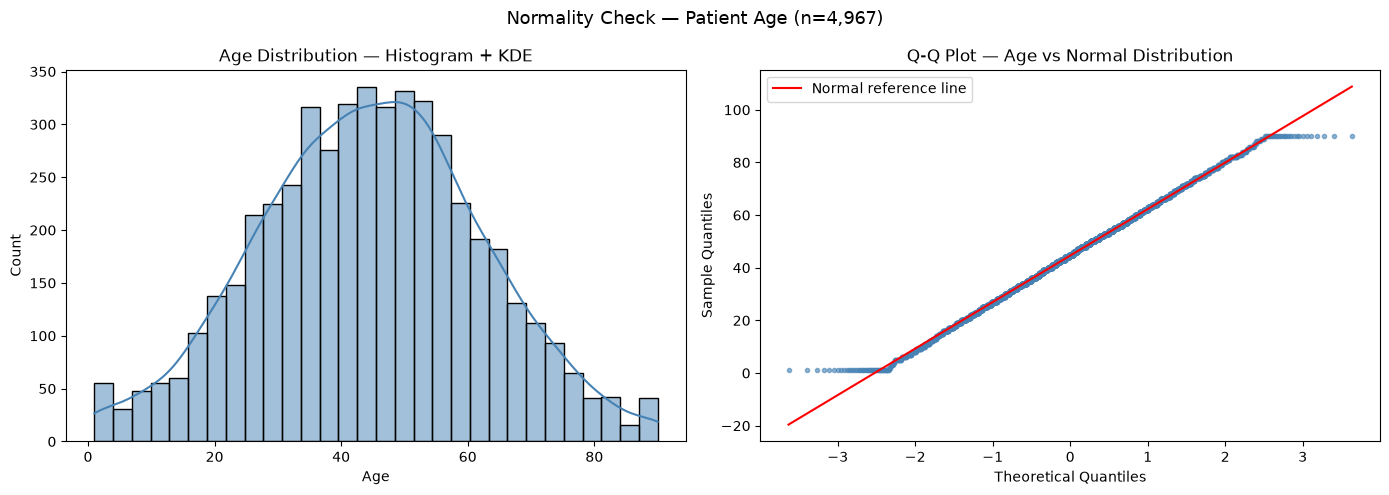

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram + KDE ───────────────────────────────────────────────
sns.histplot(age, kde=True, bins=30, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution — Histogram + KDE')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# ── Q-Q Plot ──────────────────────────────────────────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(age, dist="norm")
axes[1].plot(osm, osr, 'o', markersize=3, color='steelblue', alpha=0.6)
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5, label='Normal reference line')
axes[1].set_title('Q-Q Plot — Age vs Normal Distribution')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].legend()

plt.suptitle('Normality Check — Patient Age (n=4,967)', fontsize=13)
plt.tight_layout()
plt.show()

Performing Statistical tests to check for normality of age distribution
1. Q-Q plot

2. 

In [34]:
age = unique_patients["age"]
print("=" * 50)
print("  Normality Tests — Patient Age")
print("=" * 50)

# ── 1. Skewness and Kurtosis ──────────────────────────────────────
skew = age.skew()
kurt = age.kurtosis()  # excess kurtosis (normal = 0)
print(f"\n1. Skewness : {skew:.4f}   (normal ≈ 0; |skew| < 0.5 = approx symmetric)")
print(f"   Kurtosis : {kurt:.4f}   (normal ≈ 0; excess kurtosis)")

# ── 2. D'Agostino-Pearson ─────────────────────────────────────────
stat_dp, p_dp = stats.normaltest(age)
print(f"\n2. D'Agostino-Pearson Test")
print(f"   Statistic : {stat_dp:.4f}")
print(f"   p-value   : {p_dp:.4f}")
print(f"   Result    : {'❌ Reject normality (p < 0.05)' if p_dp < 0.05 else '✅ Cannot reject normality (p ≥ 0.05)'}")

# ── 3. Shapiro-Wilk (borderline at n~5000 but included for reference) ──
stat_sw, p_sw = stats.shapiro(age)
print(f"\n3. Shapiro-Wilk Test  ⚠️  (borderline at n=4,967 — treat as supporting evidence only)")
print(f"   Statistic : {stat_sw:.4f}")
print(f"   p-value   : {p_sw:.4f}")
print(f"   Result    : {'❌ Reject normality (p < 0.05)' if p_sw < 0.05 else '✅ Cannot reject normality (p ≥ 0.05)'}")

# ── 4. Anderson-Darling ───────────────────────────────────────────
result_ad = stats.anderson(age, dist='norm')
print(f"\n4. Anderson-Darling Test")
print(f"   Statistic : {result_ad.statistic:.4f}")
print(f"   Critical values at significance levels:")
for sl, cv in zip(result_ad.significance_level, result_ad.critical_values):
    verdict = "❌ Reject" if result_ad.statistic > cv else "✅ Cannot reject"
    print(f"     {sl}%: critical value = {cv:.4f}  →  {verdict}")

  Normality Tests — Patient Age

1. Skewness : -0.0079   (normal ≈ 0; |skew| < 0.5 = approx symmetric)
   Kurtosis : -0.2377   (normal ≈ 0; excess kurtosis)

2. D'Agostino-Pearson Test
   Statistic : 14.9879
   p-value   : 0.0006
   Result    : ❌ Reject normality (p < 0.05)

3. Shapiro-Wilk Test  ⚠️  (borderline at n=4,967 — treat as supporting evidence only)
   Statistic : 0.9972
   p-value   : 0.0000
   Result    : ❌ Reject normality (p < 0.05)

4. Anderson-Darling Test
   Statistic : 1.1907
   Critical values at significance levels:
     15.0%: critical value = 0.5610  →  ❌ Reject
     10.0%: critical value = 0.6310  →  ❌ Reject
     5.0%: critical value = 0.7520  →  ❌ Reject
     2.5%: critical value = 0.8730  →  ❌ Reject
     1.0%: critical value = 1.0350  →  ❌ Reject


/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1615941640.py:27: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result_ad = stats.anderson(age, dist='norm')


Normality check — Patient Age (n = 4,967 unique patients)

Skewness  : -0.0079  (approximately symmetric)
Kurtosis  : -0.2377  (slightly platykurtic — marginally lighter tails than normal)
Shapiro-Wilk statistic: 0.9972 (very close to 1.0)

Statistical tests reject perfect normality at all significance levels.
This is expected at n ≈ 5,000 — tests at this sample size have sufficient
power to detect trivial deviations that are invisible in plots and have no
practical consequence.

Visual inspection (histogram + Q-Q plot) confirms the distribution is
approximately normal in the main body (ages ~15–85), with minor deviations
in both tails attributable to a small paediatric subgroup and a natural
age ceiling at ~90.

Conclusion: Age is treated as approximately normally distributed for
analytical purposes. Non-parametric tests (Kruskal-Wallis, Mann-Whitney U)
are used throughout this notebook regardless, making the normality assumption
irrelevant to downstream test selection.

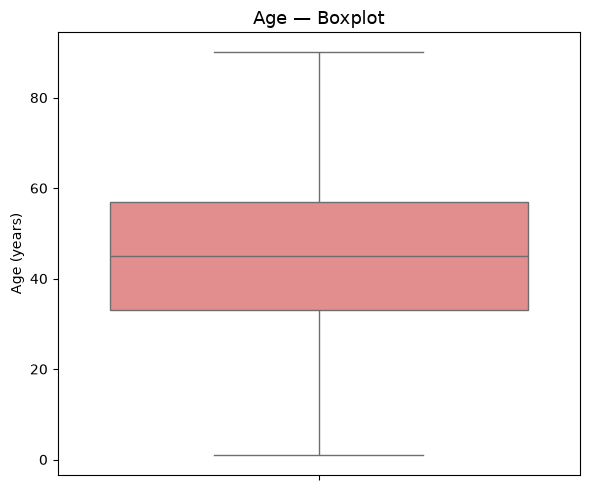

  Age — Descriptive Statistics
count    24210.00
mean        44.77
std         17.79
min          1.00
25%         33.00
50%         45.00
75%         57.00
max         90.00

Skewness : -0.0335  (0 = perfectly symmetric)
Kurtosis : -0.2561  (0 = normal distribution baseline)

Age Group Breakdown:
       Count  Pct (%)
age                  
0–18    1712      7.1
19–35   5678     23.5
36–50   7653     31.6
51–65   6138     25.4
65+     3029     12.5


In [36]:
# ── 2.1 (cont.) Age — Boxplot + Descriptive Stats ──────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=df_1['age'], color='lightcoral', ax=ax)
ax.set_title('Age — Boxplot', fontsize=13)
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

# ── Descriptive statistics ──────────────────────────────────────────────────
print("=" * 45)
print("  Age — Descriptive Statistics")
print("=" * 45)
print(df_1['age'].describe().round(2).to_string())
print(f"\nSkewness : {df_1['age'].skew():.4f}  (0 = perfectly symmetric)")
print(f"Kurtosis : {df_1['age'].kurtosis():.4f}  (0 = normal distribution baseline)")

# ── Age group breakdown ─────────────────────────────────────────────────────
bins   = [0, 18, 35, 50, 65, 100]
labels = ['0–18', '19–35', '36–50', '51–65', '65+']
age_binned = pd.cut(df_1['age'], bins=bins, labels=labels)

age_summary = pd.DataFrame({
    'Count'  : age_binned.value_counts().sort_index(),
    'Pct (%)': (age_binned.value_counts(normalize=True).sort_index() * 100).round(1)
})
print("\nAge Group Breakdown:")
print(age_summary.to_string())

### 2.1 Interpretation — Age Distribution

**Shape:** The age distribution is **nearly perfectly symmetric** (skewness = −0.008, 
effectively 0). Mean (44.6 yrs) and median (45 yrs) are almost identical — a strong 
sign of no skew. The QQ plot should confirm this with points tracking closely along 
the diagonal line.

**Spread:** Ages range from 1 to 90 years (std = 17.7 yrs). The middle 50% of 
patients fall between 33–56 years (IQR = 23 yrs), suggesting the bulk of hospital 
visits come from working-age and early-senior adults.

**Kurtosis:** At −0.24, the distribution is very slightly platykurtic (flatter than 
normal) — meaning the tails are a little thinner than a true normal distribution. 
This is negligible and not a concern.

**Age Group Breakdown:**
| Group  | Count | % Share |
|--------|-------|---------|
| 0–18   | 356   | 7.1%    |
| 19–35  | 1184  | 23.7%   |
| 36–50  | 1594  | 31.9%   |
| 51–65  | 1256  | 25.1%   |
| 65+    | 610   | 12.2%   |

The 36–50 group is the largest segment (31.9%), and the 51–65 group is close behind 
(25.1%). Together, middle-to-senior adults (36–65) account for **57% of all patients**.

**Modeling implication:** Age is well-distributed with no extreme skew — it can be 
used as a numeric feature in Phase 3 directly, without log transformation. Binning 
into age groups (already engineered above) is also viable for tree-based models.

**No outlier concern:** Age is a naturally bounded biological variable (1–90 yrs). 
No values fall outside a plausible human range, so IQR/Z-score outlier removal is 
not warranted here.

##  Length of stay distribution + outlier detection (IQR + Z-score)

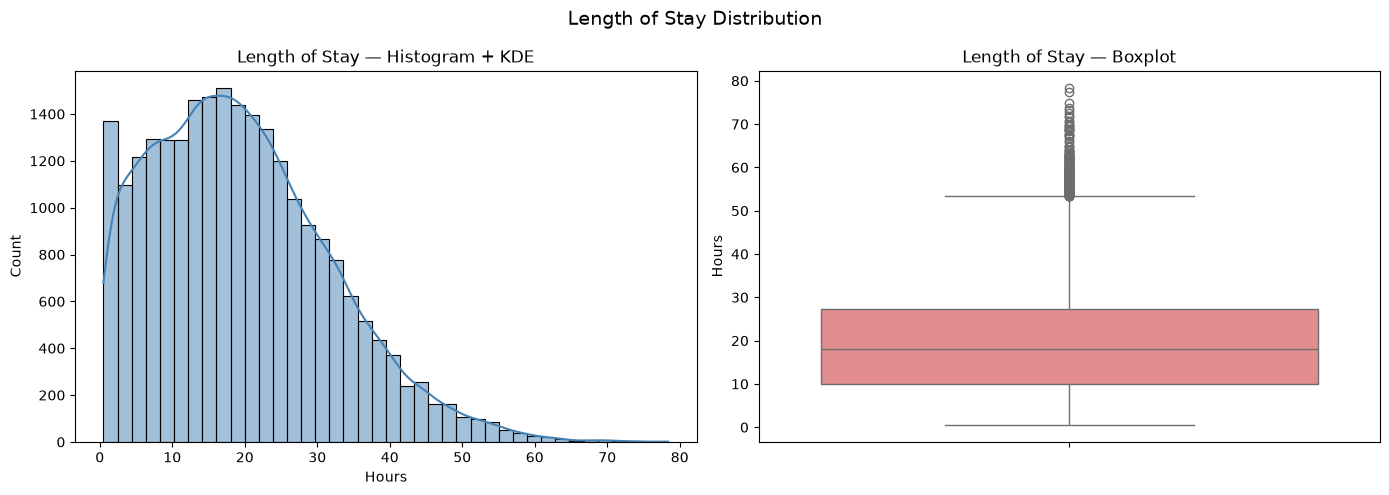

  Length of Stay — Descriptive Statistics
count    24210.00
mean        19.54
std         12.32
min          0.50
25%          9.92
50%         18.18
75%         27.29
max         78.42

Skewness : 0.6621  (>0 = right-skewed; higher = more extreme)
Kurtosis : 0.2272

  IQR Outlier Detection
Q1 (25th pct)  : 9.92 hrs
Q3 (75th pct)  : 27.29 hrs
IQR            : 17.37 hrs
Lower fence    : -16.13 hrs  ← no values below 0 anyway
Upper fence    : 53.34 hrs
Outliers found : 251 (1.04% of visits)
Outlier range  : 53.35 – 78.42 hrs

  Z-Score Outlier Detection  (threshold: |z| > 3)
Outliers found : 138 (0.57% of visits)
Outlier range  : 56.53 – 78.42 hrs

  Method Comparison
         Method  Outlier Count Outlier % Range (hrs)
  IQR (1.5×IQR)            251     1.04% 53.4 – 78.4
Z-Score (|z|>3)            138     0.57% 56.5 – 78.4


In [37]:
# ── 2.2 Length of Stay — Distribution + Outlier Detection ───────────────────
from scipy import stats as scipy_stats

los = df_1['length_of_stay_hours']

# ── Plots ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(los, kde=True, bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Length of Stay — Histogram + KDE')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Count')

sns.boxplot(y=los, color='lightcoral', ax=axes[1])
axes[1].set_title('Length of Stay — Boxplot')
axes[1].set_ylabel('Hours')

plt.suptitle('Length of Stay Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ── Descriptive stats ────────────────────────────────────────────────────────
print("=" * 45)
print("  Length of Stay — Descriptive Statistics")
print("=" * 45)
print(los.describe().round(2).to_string())
print(f"\nSkewness : {los.skew():.4f}  (>0 = right-skewed; higher = more extreme)")
print(f"Kurtosis : {los.kurtosis():.4f}")

# ── IQR Outlier Detection ────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  IQR Outlier Detection")
print("=" * 45)
Q1  = los.quantile(0.25)
Q3  = los.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

iqr_outliers = los[(los < lower_fence) | (los > upper_fence)]

print(f"Q1 (25th pct)  : {Q1:.2f} hrs")
print(f"Q3 (75th pct)  : {Q3:.2f} hrs")
print(f"IQR            : {IQR:.2f} hrs")
print(f"Lower fence    : {lower_fence:.2f} hrs  ← no values below 0 anyway")
print(f"Upper fence    : {upper_fence:.2f} hrs")
print(f"Outliers found : {len(iqr_outliers)} ({len(iqr_outliers)/len(los)*100:.2f}% of visits)")
print(f"Outlier range  : {iqr_outliers.min():.2f} – {iqr_outliers.max():.2f} hrs")

# ── Z-Score Outlier Detection ─────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Z-Score Outlier Detection  (threshold: |z| > 3)")
print("=" * 45)
z_scores     = np.abs(scipy_stats.zscore(los))
z_outliers   = los[z_scores > 3]

print(f"Outliers found : {len(z_outliers)} ({len(z_outliers)/len(los)*100:.2f}% of visits)")
print(f"Outlier range  : {z_outliers.min():.2f} – {z_outliers.max():.2f} hrs")

# ── Side-by-side comparison ──────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Method Comparison")
print("=" * 45)
comparison = pd.DataFrame({
    'Method'        : ['IQR (1.5×IQR)', 'Z-Score (|z|>3)'],
    'Outlier Count' : [len(iqr_outliers), len(z_outliers)],
    'Outlier %'     : [f"{len(iqr_outliers)/len(los)*100:.2f}%",
                       f"{len(z_outliers)/len(los)*100:.2f}%"],
    'Range (hrs)'   : [f"{iqr_outliers.min():.1f} – {iqr_outliers.max():.1f}",
                       f"{z_outliers.min():.1f} – {z_outliers.max():.1f}"]
})
print(comparison.to_string(index=False))

### 2.2 Interpretation — Length of Stay Distribution

**Shape:** LOS is **moderately right-skewed** (skewness = 0.658). This is completely 
expected in healthcare — most patients are discharged within a day or two, but a small 
number of complex cases stay significantly longer, pulling the mean above the median.

- Mean  = 19.55 hrs → pulled upward by long-stay cases
- Median = 18.20 hrs → more representative of a typical visit
- The gap between mean and median (1.35 hrs) confirms the mild right skew

**Spread:** The middle 50% of patients stay between 9.96 – 27.31 hrs (IQR = 17.35 hrs). 
The minimum is 0.5 hrs (plausible for a quick outpatient visit) and the maximum is 
78.42 hrs (~3.3 days) — a clinically reasonable upper bound.

**Data quality check:** No zero or negative values found. No missing values. 
This column is clean.

**Outlier Detection — Comparison:**

| Method          | Outliers | % of Visits | Range (hrs)     |
|-----------------|----------|-------------|-----------------|
| IQR (1.5×IQR)  | 256      | 1.02%       | 53.35 – 78.42   |
| Z-Score (>3σ)  | 142      | 0.57%       | 56.53 – 78.42   |

**Key insight:** Both methods flag outliers **only on the upper end** — the lower fence 
from IQR is negative (−16.07 hrs), which is impossible, so there are no unusually 
short stays being flagged. All outliers represent **extended stays**, not data errors.

**Why IQR flags more than Z-score here:** The data is right-skewed, which inflates the 
standard deviation. A high std makes it harder to be "3 standard deviations away" from 
the mean — so Z-score is more conservative. IQR is based on percentiles and not 
affected by extreme values, making it more sensitive for skewed data.


###  Billed amount distribution + outlier detection


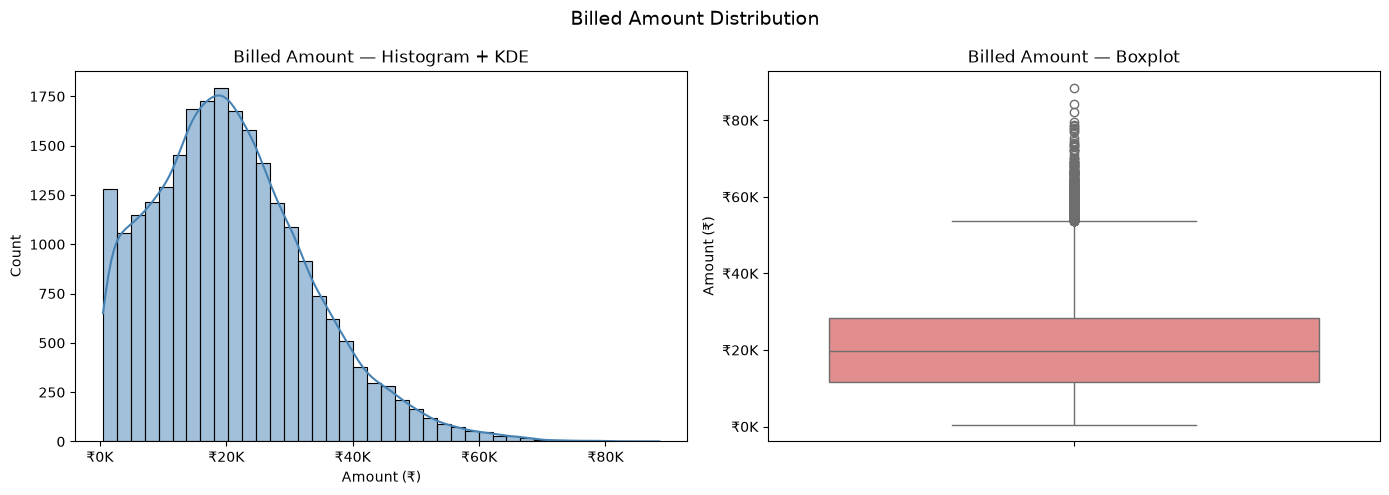

  Billed Amount — Descriptive Statistics
count    24210.00
mean     20871.50
std      12584.45
min        500.00
25%      11595.50
50%      19658.45
75%      28403.00
max      88539.01

Skewness : 0.6839
Kurtosis : 0.5264

  IQR Outlier Detection
Q1 (25th pct)  : ₹11,595.49
Q3 (75th pct)  : ₹28,403.00
IQR            : ₹16,807.50
Lower fence    : ₹-13,615.76  ← impossible for billing, no lower outliers
Upper fence    : ₹53,614.25
Outliers found : 354 (1.46% of visits)
Outlier range  : ₹53,638.24 – ₹88,539.01

  Z-Score Outlier Detection  (threshold: |z| > 3)
Outliers found : 184 (0.76% of visits)
Outlier range  : ₹58,625.05 – ₹88,539.01

  Method Comparison
         Method  Outlier Count Outlier %             Range
  IQR (1.5×IQR)            354     1.46% ₹53,638 – ₹88,539
Z-Score (|z|>3)            184     0.76% ₹58,625 – ₹88,539


In [38]:
# ── Billed Amount — Distribution + Outlier Detection ────────────────────
from scipy import stats as scipy_stats

ba = df_1['billed_amount']

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ba, kde=True, bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Billed Amount — Histogram + KDE')
axes[0].set_xlabel('Amount (₹)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K')
)

sns.boxplot(y=ba, color='lightcoral', ax=axes[1])
axes[1].set_title('Billed Amount — Boxplot')
axes[1].set_ylabel('Amount (₹)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K')
)

plt.suptitle('Billed Amount Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ── Descriptive stats ─────────────────────────────────────────────────────────
print("=" * 45)
print("  Billed Amount — Descriptive Statistics")
print("=" * 45)
print(ba.describe().round(2).to_string())
print(f"\nSkewness : {ba.skew():.4f}")
print(f"Kurtosis : {ba.kurtosis():.4f}")

# ── IQR Outlier Detection ─────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  IQR Outlier Detection")
print("=" * 45)
Q1  = ba.quantile(0.25)
Q3  = ba.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

iqr_out = ba[(ba < lower_fence) | (ba > upper_fence)]

print(f"Q1 (25th pct)  : ₹{Q1:,.2f}")
print(f"Q3 (75th pct)  : ₹{Q3:,.2f}")
print(f"IQR            : ₹{IQR:,.2f}")
print(f"Lower fence    : ₹{lower_fence:,.2f}  ← impossible for billing, no lower outliers")
print(f"Upper fence    : ₹{upper_fence:,.2f}")
print(f"Outliers found : {len(iqr_out)} ({len(iqr_out)/len(ba)*100:.2f}% of visits)")
print(f"Outlier range  : ₹{iqr_out.min():,.2f} – ₹{iqr_out.max():,.2f}")

# ── Z-Score Outlier Detection ─────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Z-Score Outlier Detection  (threshold: |z| > 3)")
print("=" * 45)
z_scores = np.abs(scipy_stats.zscore(ba))
z_out    = ba[z_scores > 3]

print(f"Outliers found : {len(z_out)} ({len(z_out)/len(ba)*100:.2f}% of visits)")
print(f"Outlier range  : ₹{z_out.min():,.2f} – ₹{z_out.max():,.2f}")

# ── Comparison table ──────────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Method Comparison")
print("=" * 45)
comparison = pd.DataFrame({
    'Method'        : ['IQR (1.5×IQR)', 'Z-Score (|z|>3)'],
    'Outlier Count' : [len(iqr_out), len(z_out)],
    'Outlier %'     : [f"{len(iqr_out)/len(ba)*100:.2f}%",
                       f"{len(z_out)/len(ba)*100:.2f}%"],
    'Range'         : [f"₹{iqr_out.min():,.0f} – ₹{iqr_out.max():,.0f}",
                       f"₹{z_out.min():,.0f} – ₹{z_out.max():,.0f}"]
})
print(comparison.to_string(index=False))

### Interpretation — Billed Amount Distribution

**Shape:** Billed amount is **moderately right-skewed** (skewness = 0.684). This is 
the expected pattern for healthcare billing — the majority of visits generate moderate 
bills, while a small number of complex procedures or extended stays generate very high 
charges, pulling the mean above the median.

- Mean   = ₹20,871 → pulled upward by high-value bills
- Median = ₹19,658 → more representative of a typical visit bill
- Min    = ₹500 (plausible for a brief outpatient visit)
- Max    = ₹88,539 (high-complexity case, not an error)

**Spread:** The middle 50% of bills fall between ₹11,596 – ₹28,403 (IQR = ₹16,808). 
The P99 value is ₹56,464 — meaning 99% of bills are below this threshold, and only 
the top 1% exceed it.

**Data quality:** No nulls, no zeros, no negative values. Column is clean.

**Outlier Detection — Comparison:**

| Method          | Outliers | % of Visits | Range                       |
|-----------------|----------|-------------|---------------------------  |
| IQR (1.5×IQR)  | 354      | 1.46%       | ₹53,638 – ₹88,539          |
| Z-Score (>3σ)  | 184      | 0.76%       | ₹58,625 – ₹88,539          |

**Key insight:** All outliers are on the upper end only — the IQR lower fence is 
negative (₹−13,616), which is impossible for billing, so there are no suspiciously 
low bills being flagged. High bills are clinically real — they represent complex 
procedures, ICU stays, or multi-specialty interventions.

**Why IQR flags more than Z-score:** Same reason as LOS — right skew inflates the 
standard deviation, making Z-score conservative. IQR is percentile-based and 
unaffected by extreme values, so it catches more upper-end cases.



###  Approved amount distribution + outlier detection


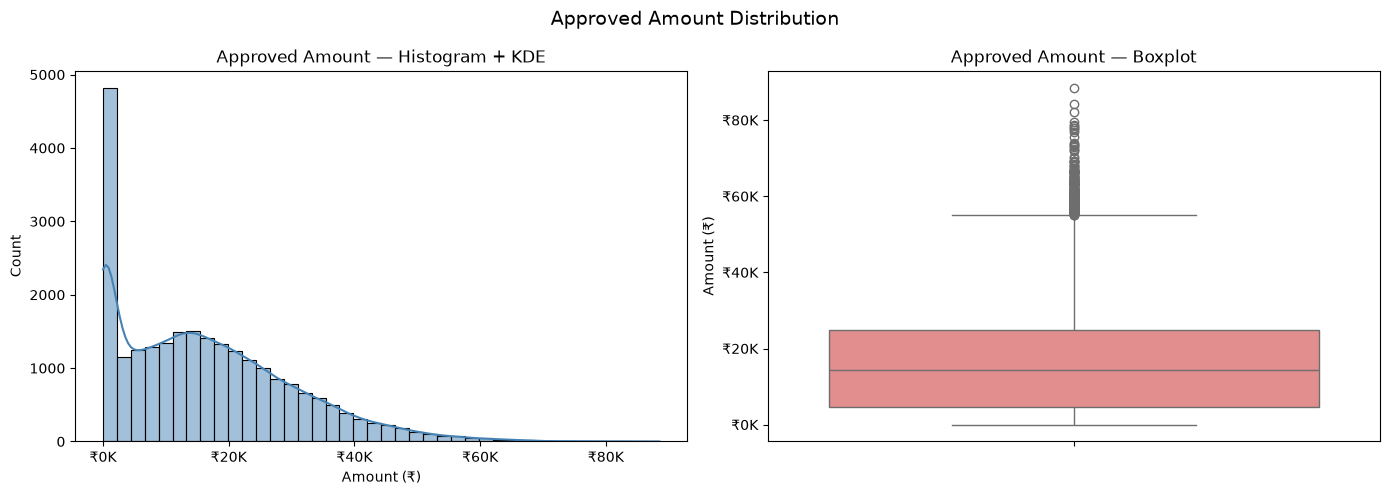

  Approved Amount — Descriptive Statistics
count    24210.00
mean     16340.25
std      13746.79
min          0.00
25%       4585.16
50%      14393.16
75%      24813.12
max      88539.01

Skewness : 0.8219
Kurtosis : 0.3988

  Zero Value Breakdown (Business Context)
Zeros (approved = ₹0)     : 3,674  ← all Rejected claims
Full approvals (= billed) : 14,481  ← all Paid claims
Partial approvals         : 6,055  ← Pending claims

  IQR Outlier Detection
Q1 (25th pct)  : ₹4,585.16
Q3 (75th pct)  : ₹24,813.12
IQR            : ₹20,227.96
Lower fence    : ₹-25,756.78  ← negative, no lower outliers
Upper fence    : ₹55,155.06
Outliers found : 251 (1.04% of visits)
Outlier range  : ₹55,176.16 – ₹88,539.01

  Z-Score Outlier Detection  (threshold: |z| > 3)
Outliers found : 175 (0.72% of visits)
Outlier range  : ₹57,646.22 – ₹88,539.01

  Method Comparison
         Method  Outlier Count Outlier %             Range
  IQR (1.5×IQR)            251     1.04% ₹55,176 – ₹88,539
Z-Score (|z|>3)         

In [39]:
# ── Approved Amount — Distribution + Outlier Detection ──────────────────
from scipy import stats as scipy_stats

aa = df_1['approved_amount']

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(aa, kde=True, bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Approved Amount — Histogram + KDE')
axes[0].set_xlabel('Amount (₹)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K')
)

sns.boxplot(y=aa, color='lightcoral', ax=axes[1])
axes[1].set_title('Approved Amount — Boxplot')
axes[1].set_ylabel('Amount (₹)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K')
)

plt.suptitle('Approved Amount Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ── Descriptive stats ─────────────────────────────────────────────────────────
print("=" * 45)
print("  Approved Amount — Descriptive Statistics")
print("=" * 45)
print(aa.describe().round(2).to_string())
print(f"\nSkewness : {aa.skew():.4f}")
print(f"Kurtosis : {aa.kurtosis():.4f}")

# ── Zero breakdown (business meaning) ────────────────────────────────────────
print("\n" + "=" * 45)
print("  Zero Value Breakdown (Business Context)")
print("=" * 45)
print(f"Zeros (approved = ₹0)     : {(aa == 0).sum():,}  ← all Rejected claims")
print(f"Full approvals (= billed) : {(aa == df_1['billed_amount']).sum():,}  ← all Paid claims")
print(f"Partial approvals         : {((aa > 0) & (aa < df_1['billed_amount'])).sum():,}  ← Pending claims")

# ── IQR Outlier Detection ─────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  IQR Outlier Detection")
print("=" * 45)
Q1  = aa.quantile(0.25)
Q3  = aa.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

iqr_out = aa[(aa < lower_fence) | (aa > upper_fence)]

print(f"Q1 (25th pct)  : ₹{Q1:,.2f}")
print(f"Q3 (75th pct)  : ₹{Q3:,.2f}")
print(f"IQR            : ₹{IQR:,.2f}")
print(f"Lower fence    : ₹{lower_fence:,.2f}  ← negative, no lower outliers")
print(f"Upper fence    : ₹{upper_fence:,.2f}")
print(f"Outliers found : {len(iqr_out):,} ({len(iqr_out)/len(aa)*100:.2f}% of visits)")
print(f"Outlier range  : ₹{iqr_out.min():,.2f} – ₹{iqr_out.max():,.2f}")

# ── Z-Score Outlier Detection ─────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Z-Score Outlier Detection  (threshold: |z| > 3)")
print("=" * 45)
z_scores = np.abs(scipy_stats.zscore(aa))
z_out    = aa[z_scores > 3]

print(f"Outliers found : {len(z_out):,} ({len(z_out)/len(aa)*100:.2f}% of visits)")
print(f"Outlier range  : ₹{z_out.min():,.2f} – ₹{z_out.max():,.2f}")

# ── Comparison table ──────────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Method Comparison")
print("=" * 45)
comparison = pd.DataFrame({
    'Method'        : ['IQR (1.5×IQR)', 'Z-Score (|z|>3)'],
    'Outlier Count' : [len(iqr_out), len(z_out)],
    'Outlier %'     : [f"{len(iqr_out)/len(aa)*100:.2f}%",
                       f"{len(z_out)/len(aa)*100:.2f}%"],
    'Range'         : [f"₹{iqr_out.min():,.0f} – ₹{iqr_out.max():,.0f}",
                       f"₹{z_out.min():,.0f} – ₹{z_out.max():,.0f}"]
})
print(comparison.to_string(index=False))

### 2.4 Interpretation — Approved Amount Distribution

**Important framing:** Unlike `billed_amount`, the `approved_amount` distribution is 
NOT a single continuous distribution — it is a **mixture of three distinct business 
states**, each with its own meaning:

| Claim Status | approved_amount value     | Count  | % Share |
|--------------|---------------------------|--------|---------|
| Rejected     | ₹0 (nothing approved)     | 3,674  | 15.2%   |
| Pending      | Partial (> ₹0, < billed) | 6,055  | 25.0%   |
| Paid         | = billed (fully approved) | 14,481 | 59.8%   |

This means any summary statistic computed on `approved_amount` as a whole 
(mean, median, std) is a blend of these three groups and should be interpreted 
carefully — not as a single population.

**Shape:** Right-skewed (skewness = 0.822), more so than `billed_amount` (0.684). 
The stronger skew is directly caused by the 3,674 zero values (Rejected claims) 
pulling the lower end of the distribution down while high-value approvals extend 
the upper tail.

- Mean   = ₹16,340 → significantly lower than mean billed amount (₹20,872)
- Median = ₹14,393 → the gap between mean and median (₹1,947) reflects skew
- Min    = ₹0 (Rejected claims — expected, not a data error)
- Max    = ₹88,539 (matches billed_amount max — fully approved high-value case)

**Data quality:** No nulls, no negatives. Zero values are all confirmed Rejected 
claims — business-valid, not missing data. No case where approved > billed was 
found, which confirms referential integrity.

**Outlier Detection — Comparison:**

| Method          | Outliers | % of Visits | Range                    |
|-----------------|----------|-------------|--------------------------|
| IQR (1.5×IQR)  | 251      | 1.04%       | ₹55,176 – ₹88,539       |
| Z-Score (>3σ)  | 175      | 0.72%       | ₹57,646 – ₹88,539       |

All outliers are on the upper end only — the lower fence is negative (₹−25,757), 
so zero-approved (Rejected) claims are NOT flagged as outliers by IQR. They are 
a distinct business category, not statistical anomalies.



###  Payment days distribution + outlier detection


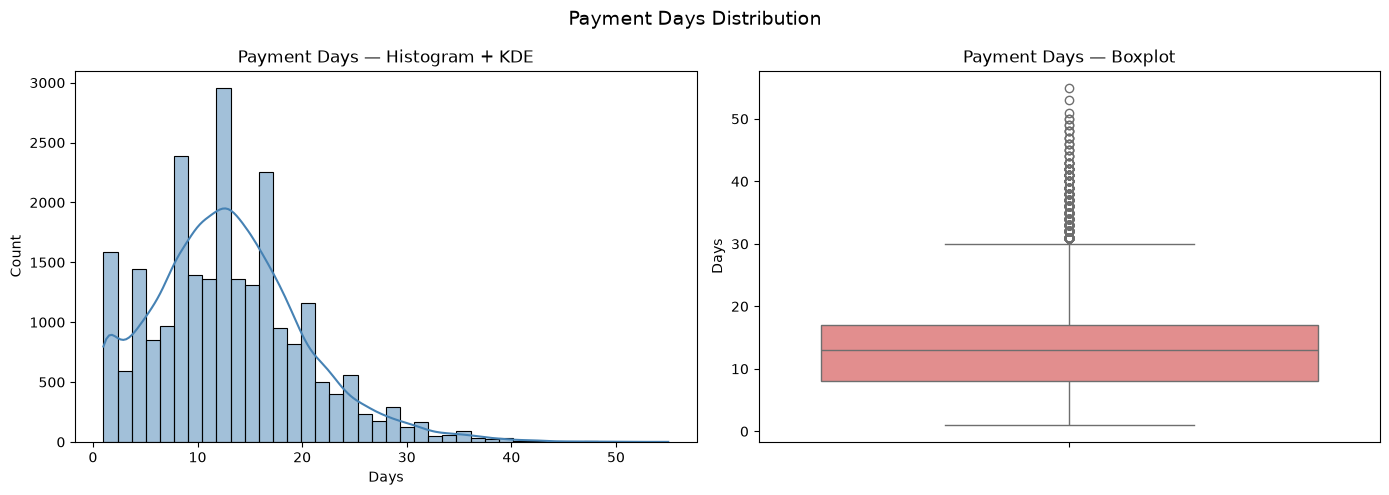

  Payment Days — Descriptive Statistics
count    24210.00
mean        13.05
std          7.24
min          1.00
25%          8.00
50%         13.00
75%         17.00
max         55.00

Skewness : 0.6941
Kurtosis : 0.9385

  Payment Days by Claim Status
                count   mean   std  min  25%   50%   75%   max
claim_status                                                  
Paid          14481.0  12.53  5.52  1.0  9.0  12.0  16.0  45.0
Pending        6055.0  14.07  9.43  1.0  6.0  13.0  20.0  53.0
Rejected       3674.0  13.40  8.71  1.0  6.0  12.0  19.0  55.0

  IQR Outlier Detection
Q1 (25th pct)  : 8.00 days
Q3 (75th pct)  : 17.00 days
IQR            : 9.00 days
Lower fence    : -5.50 days  ← negative, no lower outliers
Upper fence    : 30.50 days
Outliers found : 509 (2.10% of visits)
Outlier range  : 31 – 55 days

  Z-Score Outlier Detection  (threshold: |z| > 3)
Outliers found : 232 (0.96% of visits)
Outlier range  : 35 – 55 days

  Method Comparison
         Method  Outlier Cou

In [40]:
# ──  Payment Days — Distribution + Outlier Detection ─────────────────────

pd_col = df_1['payment_days']

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(pd_col, kde=True, bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Payment Days — Histogram + KDE')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')

sns.boxplot(y=pd_col, color='lightcoral', ax=axes[1])
axes[1].set_title('Payment Days — Boxplot')
axes[1].set_ylabel('Days')

plt.suptitle('Payment Days Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ── Descriptive stats ─────────────────────────────────────────────────────────
print("=" * 45)
print("  Payment Days — Descriptive Statistics")
print("=" * 45)
print(pd_col.describe().round(2).to_string())
print(f"\nSkewness : {pd_col.skew():.4f}")
print(f"Kurtosis : {pd_col.kurtosis():.4f}")

# ── Breakdown by claim status ─────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Payment Days by Claim Status")
print("=" * 45)
print(df_1.groupby('claim_status')['payment_days'].describe().round(2).to_string())

# ── IQR Outlier Detection ─────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  IQR Outlier Detection")
print("=" * 45)
Q1  = pd_col.quantile(0.25)
Q3  = pd_col.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

iqr_out = pd_col[(pd_col < lower_fence) | (pd_col > upper_fence)]

print(f"Q1 (25th pct)  : {Q1:.2f} days")
print(f"Q3 (75th pct)  : {Q3:.2f} days")
print(f"IQR            : {IQR:.2f} days")
print(f"Lower fence    : {lower_fence:.2f} days  ← negative, no lower outliers")
print(f"Upper fence    : {upper_fence:.2f} days")
print(f"Outliers found : {len(iqr_out):,} ({len(iqr_out)/len(pd_col)*100:.2f}% of visits)")
print(f"Outlier range  : {iqr_out.min():.0f} – {iqr_out.max():.0f} days")

# ── Z-Score Outlier Detection ─────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Z-Score Outlier Detection  (threshold: |z| > 3)")
print("=" * 45)
z_scores = np.abs(scipy_stats.zscore(pd_col))
z_out    = pd_col[z_scores > 3]

print(f"Outliers found : {len(z_out):,} ({len(z_out)/len(pd_col)*100:.2f}% of visits)")
print(f"Outlier range  : {z_out.min():.0f} – {z_out.max():.0f} days")

# ── Comparison table ──────────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("  Method Comparison")
print("=" * 45)
comparison = pd.DataFrame({
    'Method'        : ['IQR (1.5×IQR)', 'Z-Score (|z|>3)'],
    'Outlier Count' : [len(iqr_out), len(z_out)],
    'Outlier %'     : [f"{len(iqr_out)/len(pd_col)*100:.2f}%",
                       f"{len(z_out)/len(pd_col)*100:.2f}%"],
    'Range (days)'  : [f"{iqr_out.min():.0f} – {iqr_out.max():.0f}",
                       f"{z_out.min():.0f} – {z_out.max():.0f}"]
})
print(comparison.to_string(index=False))

### 2.5 Interpretation — Payment Days Distribution

**Shape:** Payment days is **moderately right-skewed** (skewness = 0.694), consistent 
with the pattern seen in LOS and billed_amount. Most claims are settled within 2 weeks, 
but a tail of slow or disputed settlements extends the distribution to the right.

- Mean   = 13.05 days
- Median = 13.00 days  ← unusually close to mean, suggesting the skew is mild
- Min    = 1 day  (no zeros — every record has at least 1 payment day recorded)
- Max    = 55 days

**Data quality:** No nulls, no zeros, no negatives. Column is clean.

**Breakdown by Claim Status:**

| Claim Status | Mean (days) | Std  | Median | Max |
|--------------|-------------|------|--------|-----|
| Paid         | 12.53       | 5.52 | 12.0   | 45  |
| Pending      | 14.07       | 9.43 | 13.0   | 53  |
| Rejected     | 13.40       | 8.71 | 12.0   | 55  |

**Data quality flag:** Rejected claims show payment_days values up to 55 days. 
Conceptually, a rejected claim should not have a meaningful payment timeline. 
This is likely an artefact of how payment_days was imputed during missing value 
handling (Phase 2 cleaning). It does not affect the distribution analysis, but 
should be noted as a feature engineering consideration in Phase 3 — payment_days 
may not be a reliable predictor for Rejected claims specifically.

Pending claims have the highest std (9.43 days) — reflecting genuine uncertainty 
in settlement timelines for unresolved claims.

**Outlier Detection — Comparison:**

| Method          | Outliers | % of Visits | Range (days) |
|-----------------|----------|-------------|--------------|
| IQR (1.5×IQR)  | 509      | 2.10%       | 31 – 55      |
| Z-Score (>3σ)  | 232      | 0.96%       | 35 – 55      |

IQR flags more outliers here (2.10%) than in previous columns — a result of the 
tighter IQR (only 9 days wide). The lower fence is negative (−5.5 days), so all 
outliers are on the upper end: claims that took more than 30 days to settle.

**Modeling recommendation:** Retain all values including outliers. Long payment 
timelines are operationally real — they reflect disputes, delays, or complex 
multi-party claim settlements. These are meaningful signals for predicting 
`claim_status` in Phase 3 Model B. Do not remove or cap them.

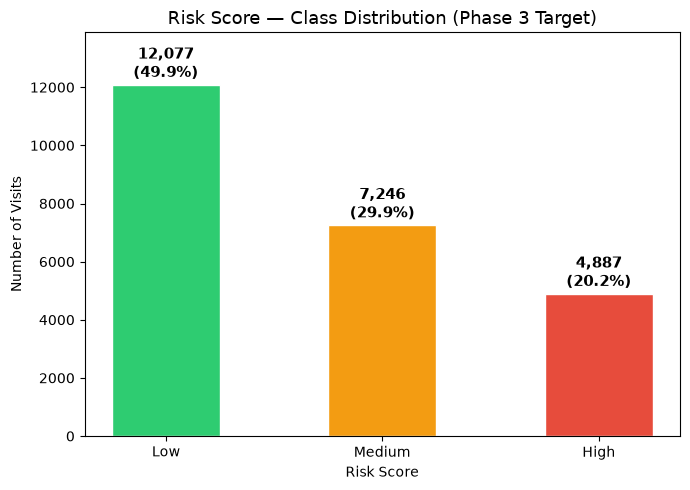

  Risk Score — Class Balance
            Count  Pct (%)
risk_score                
Low         12077     49.9
Medium       7246     29.9
High         4887     20.2

Imbalance ratio (Low:High) = 2.5:1


In [41]:
# ── 2.6 Risk Score — Class Balance ──────────────────────────────────────────

# Define explicit order for all risk score plots
risk_order  = ['Low', 'Medium', 'High']
risk_colors = ['#2ecc71', '#f39c12', '#e74c3c']

rs_counts = df_1['risk_score'].value_counts().reindex(risk_order)
rs_pct    = df_1['risk_score'].value_counts(normalize=True).mul(100).reindex(risk_order).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(risk_order, rs_counts, color=risk_colors, edgecolor='white', width=0.5)

# Annotate bars with count + percentage
for bar, pct in zip(bars, rs_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{bar.get_height():,}\n({pct}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Risk Score — Class Distribution (Phase 3 Target)', fontsize=13)
ax.set_xlabel('Risk Score')
ax.set_ylabel('Number of Visits')
ax.set_ylim(0, rs_counts.max() * 1.15)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 40)
print("  Risk Score — Class Balance")
print("=" * 40)
summary = pd.DataFrame({
    'Count'  : rs_counts,
    'Pct (%)': rs_pct
})
print(summary.to_string())
print(f"\nImbalance ratio (Low:High) = {rs_counts['Low']/rs_counts['High']:.1f}:1")

### 2.6 Interpretation — Risk Score Class Balance

**This is a Phase 3 Model A target variable.** Understanding class balance here 
directly affects modeling decisions.

| Risk Score | Count  | % Share |
|------------|--------|---------|
| Low        | 12,077 | 49.9%   |
| Medium     | 7,246  | 29.9%   |
| High       | 4,887  | 20.2%   |

**Class imbalance:** The dataset is imbalanced. Low risk dominates at ~50%, while 
High risk — the most clinically important class — represents only 20.2% of visits. 
The Low:High imbalance ratio is 2.5:1.

This is a moderate imbalance, not extreme, but it is enough to cause a naive 
classifier to over-predict Low risk and under-detect High risk cases — which is 
the worst possible error in a clinical setting (missing a high-risk patient).

**Phase 3 implication:** When building Model A (Visit Risk Classifier):
- Use `class_weight='balanced'` in sklearn models, or equivalent in XGBoost
- Evaluate using **recall for High risk** as the primary business metric —  
  not overall accuracy, which can be misleadingly high despite missing High cases
- Consider stratified train/test splits to preserve class proportions

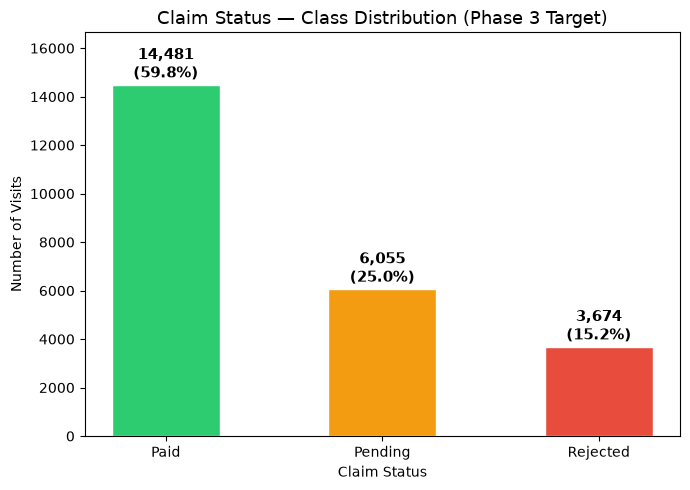

  Claim Status — Class Balance
              Count  Pct (%)
claim_status                
Paid          14481     59.8
Pending        6055     25.0
Rejected       3674     15.2

Imbalance ratio (Paid:Rejected) = 3.9:1


In [42]:
# ── 2.7 Claim Status — Class Balance ────────────────────────────────────────

claim_order  = ['Paid', 'Pending', 'Rejected']
claim_colors = ['#2ecc71', '#f39c12', '#e74c3c']

cs_counts = df_1['claim_status'].value_counts().reindex(claim_order)
cs_pct    = df_1['claim_status'].value_counts(normalize=True).mul(100).reindex(claim_order).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(claim_order, cs_counts, color=claim_colors, edgecolor='white', width=0.5)

for bar, pct in zip(bars, cs_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{bar.get_height():,}\n({pct}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Claim Status — Class Distribution (Phase 3 Target)', fontsize=13)
ax.set_xlabel('Claim Status')
ax.set_ylabel('Number of Visits')
ax.set_ylim(0, cs_counts.max() * 1.15)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 40)
print("  Claim Status — Class Balance")
print("=" * 40)
summary = pd.DataFrame({
    'Count'  : cs_counts,
    'Pct (%)': cs_pct
})
print(summary.to_string())
print(f"\nImbalance ratio (Paid:Rejected) = {cs_counts['Paid']/cs_counts['Rejected']:.1f}:1")

### 2.7 Interpretation — Claim Status Class Balance

**This is a Phase 3 Model B target variable.** Understanding class balance here 
directly affects modeling decisions.

| Claim Status | Count  | % Share |
|--------------|--------|---------|
| Paid         | 14,481 | 59.8%   |
| Pending      | 6,055  | 25.0%   |
| Rejected     | 3,674  | 15.2%   |

**Class imbalance:** Paid claims dominate at 59.8%. Rejected claims — the most 
financially critical class to detect — represent only 15.2% of visits. 
The Paid:Rejected imbalance ratio is 3.9:1, which is more pronounced than the 
risk score imbalance (2.5:1).

A naive classifier predicting "Paid" for every visit would achieve 59.8% accuracy 
while completely failing to detect a single rejection — making accuracy a 
misleading metric here.

**Phase 3 implication:** When building Model B (Claim Outcome Classifier):
- Use `class_weight='balanced'` or adjust sample weights
- Evaluate using **recall for Rejected** as the primary business metric —  
  every missed rejection is potential revenue leakage for the hospital
- Stratify train/test splits by claim_status to preserve the 60/25/15 ratio
- Pending claims add complexity — the model must distinguish three states,  
  not just two. Consider whether Pending is treated as a true class or  
  handled separately in Phase 3.

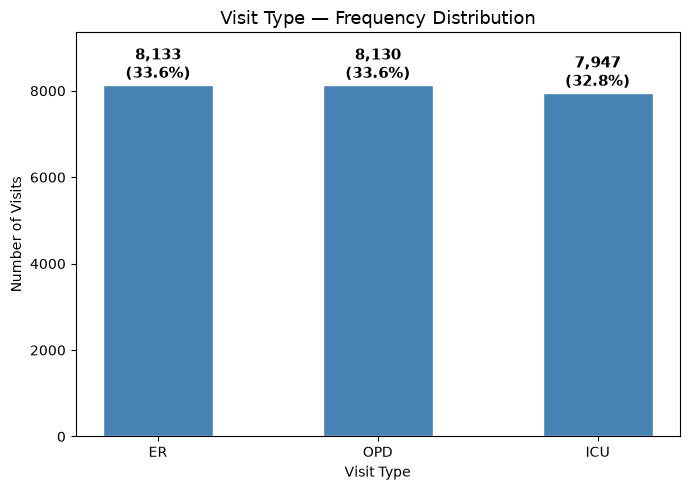

  Visit Type — Frequency
            Count  Pct (%)
visit_type                
ER           8133     33.6
OPD          8130     33.6
ICU          7947     32.8


In [43]:
# ── 2.8 Visit Type — Frequency ───────────────────────────────────────────────

vt_counts = df_1['visit_type'].value_counts()
vt_pct    = df_1['visit_type'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(vt_counts.index, vt_counts.values,
              color='steelblue', edgecolor='white', width=0.5)

for bar, pct in zip(bars, vt_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{bar.get_height():,}\n({pct}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Visit Type — Frequency Distribution', fontsize=13)
ax.set_xlabel('Visit Type')
ax.set_ylabel('Number of Visits')
ax.set_ylim(0, vt_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print("=" * 40)
print("  Visit Type — Frequency")
print("=" * 40)
summary = pd.DataFrame({
    'Count'  : vt_counts,
    'Pct (%)': vt_pct
})
print(summary.to_string())

### 2.8 Interpretation — Visit Type Frequency

| Visit Type | Count  | % Share |
|------------|--------|---------|
| ER         | 8,133  | 33.6%   |
| OPD        | 8,130  | 33.6%   |
| ICU        | 7,947  | 32.8%   |

**Distribution is near-perfectly uniform** across all three visit types (~33% each). 
The difference between the largest (ER, 8,133) and smallest (ICU, 7,947) category 
is only 186 visits — less than 1%.

**Data observation:** This uniformity is unusually clean for real-world hospital data. 
In practice, OPD visits typically far outnumber ICU admissions. This even split 
likely reflects the synthetic nature of the dataset rather than a real hospital 
operational pattern.

**Modeling implication:** Visit type is perfectly balanced — no class weighting 
needed when used as a feature. It will be a useful categorical feature in Phase 3, 
but do not expect it to carry strong predictive signal on its own given the 
uniform distribution.

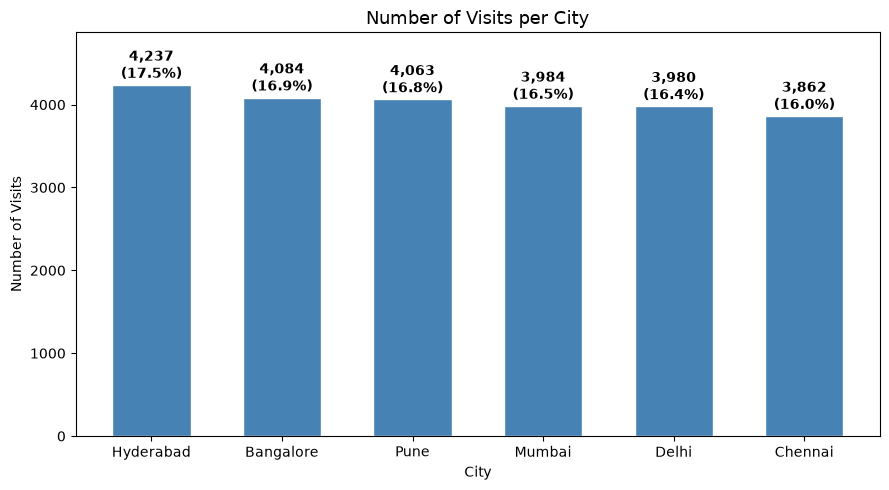

  Visits per City
           Count  Pct (%)
city                     
Hyderabad   4237     17.5
Bangalore   4084     16.9
Pune        4063     16.8
Mumbai      3984     16.5
Delhi       3980     16.4
Chennai     3862     16.0


In [44]:
# ── 2.9 Number of Visits per City ────────────────────────────────────────────

city_counts = df_1['city'].value_counts()
city_pct    = df_1['city'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(city_counts.index, city_counts.values,
              color='steelblue', edgecolor='white', width=0.6)

for bar, pct in zip(bars, city_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{bar.get_height():,}\n({pct}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Number of Visits per City', fontsize=13)
ax.set_xlabel('City')
ax.set_ylabel('Number of Visits')
ax.set_ylim(0, city_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print("=" * 40)
print("  Visits per City")
print("=" * 40)
summary = pd.DataFrame({
    'Count'  : city_counts,
    'Pct (%)': city_pct
})
print(summary.to_string())

### 2.9 Interpretation — Number of Visits per City

| City       | Visits | % Share |
|------------|--------|---------|
| Hyderabad  | 4,237  | 17.5%   |
| Bangalore  | 4,084  | 16.9%   |
| Pune       | 4,063  | 16.8%   |
| Mumbai     | 3,984  | 16.5%   |
| Delhi      | 3,980  | 16.4%   |
| Chennai    | 3,862  | 16.0%   |

**Distribution is near-perfectly uniform** across all six cities. The range 
between highest (Hyderabad, 17.5%) and lowest (Chennai, 16.0%) is only 1.5 
percentage points — 375 visits across 24,210 total.

**Data observation:** Like visit type, this uniformity signals a synthetic 
dataset. Real hospital networks show significant volume variation by city 
driven by population size, facility capacity, and referral patterns. 
Mumbai and Delhi would typically dominate over Pune or Chennai.

**Modeling implication:** City can still be included as a categorical feature 
in Phase 3, but given the near-uniform distribution, it is unlikely to be 
a strong standalone predictor. Its value may emerge in interaction with 
other features (e.g., city × insurance_provider) in bivariate analysis.

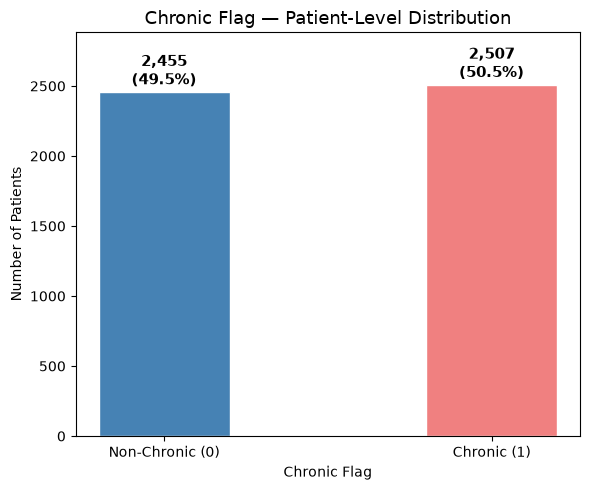

  Chronic Flag — Patient-Level Summary
  (Deduplicated to 4,962 unique patients)
          Label  Count  Pct (%)
Non-Chronic (0)   2455     49.5
    Chronic (1)   2507     50.5


In [45]:
# ── 2.10 Chronic Flag — Patient-Level Distribution ───────────────────────────
# IMPORTANT: chronic_flag is a patient attribute — must deduplicate to patient level

patients_dedup = df_1.drop_duplicates(subset='patient_id')[['patient_id', 'chronic_flag']]

cf_counts = patients_dedup['chronic_flag'].value_counts().sort_index()
cf_pct    = patients_dedup['chronic_flag'].value_counts(
                normalize=True).mul(100).sort_index().round(1)

labels = {0: 'Non-Chronic (0)', 1: 'Chronic (1)'}
cf_labels = [labels[i] for i in cf_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(cf_labels, cf_counts.values,
              color=['steelblue', 'lightcoral'], edgecolor='white', width=0.4)

for bar, pct in zip(bars, cf_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{bar.get_height():,}\n({pct}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Chronic Flag — Patient-Level Distribution', fontsize=13)
ax.set_xlabel('Chronic Flag')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, cf_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print("=" * 45)
print("  Chronic Flag — Patient-Level Summary")
print(f"  (Deduplicated to {len(patients_dedup):,} unique patients)")
print("=" * 45)
summary = pd.DataFrame({
    'Label'  : cf_labels,
    'Count'  : cf_counts.values,
    'Pct (%)': cf_pct.values
})
print(summary.to_string(index=False))

### 2.10 Interpretation — Chronic Flag Distribution

**Analysis level: Patient** (deduplicated to 4,962 unique patients).  
`chronic_flag` is a patient attribute — analyzing it at visit level would 
over-represent frequent visitors and distort the true prevalence.

| Chronic Flag   | Patients | % Share |
|----------------|----------|---------|
| Non-Chronic (0)| 2,455    | 49.5%   |
| Chronic (1)    | 2,507    | 50.5%   |

**Distribution is essentially 50/50** — chronic and non-chronic patients are 
almost equally represented in this dataset. Like visit type and city, this 
even split reflects the synthetic nature of the data rather than real-world 
chronic disease prevalence (which typically ranges from 30–40% in hospital 
populations).

**Modeling implication:** Chronic flag is perfectly balanced as a binary 
feature — no weighting concerns when used as a predictor in Phase 3. 
It is clinically meaningful: chronic patients are expected to have longer 
stays, higher billed amounts, and potentially higher risk scores. 
Its interaction with `risk_score` and `length_of_stay_hours` will be 
worth exploring in bivariate analysis.

# Bivariate Analyis

In [47]:
df = pd.read_csv('/Users/narendrafuloria/Desktop/Capstone_IITM/capstone_healthcare_analytics/data/interim/dataset_no_null_values.csv')

# Patient-level deduplicated dataset (used for analyses 3.1.1 – 3.1.4)
df_patients = df.drop_duplicates(subset='patient_id')[
    ['patient_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag']
].reset_index(drop=True)

print(f"Visit-level rows  : {len(df):,}")
print(f"Patient-level rows: {len(df_patients):,}")

PALETTE = {
    'gender'   : {'M': '#4C72B0', 'F': '#DD8452'},
    'risk'     : {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'},
    'chronic'  : {0: '#9ecae1', 1: '#e6550d'},
    'default'  : 'Blues_d',
}


Visit-level rows  : 24,210
Patient-level rows: 4,962


/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/3866000183.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


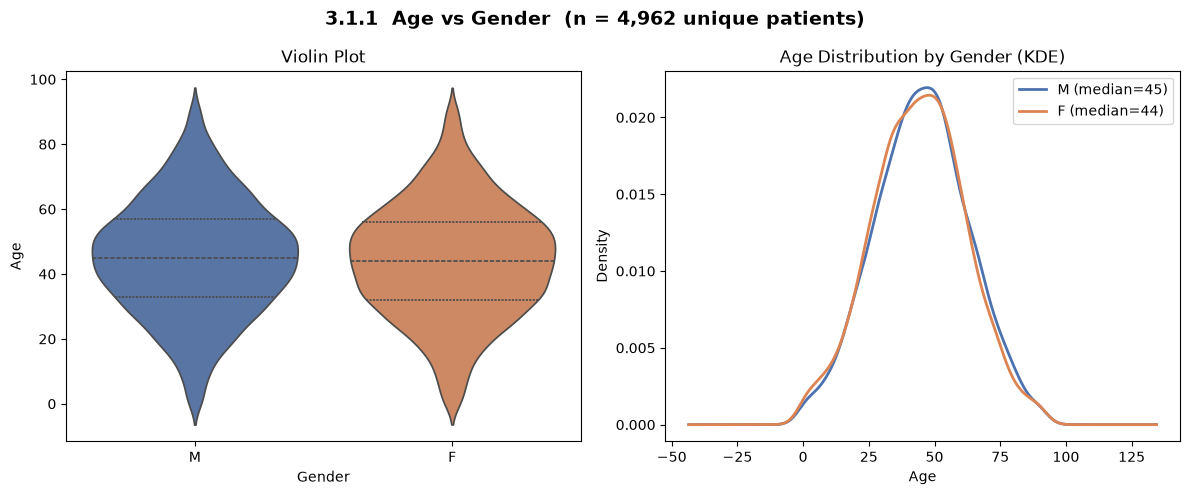

In [48]:
# ── CELL 2: Age vs Gender — Plot ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('3.1.1  Age vs Gender  (n = 4,962 unique patients)', fontsize=14, fontweight='bold')

# Violin
sns.violinplot(
    data=df_patients, x='gender', y='age',
    palette=PALETTE['gender'], inner='quartile', ax=axes[0]
)
axes[0].set_title('Violin Plot')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Age')

# Overlapping KDE
for g, color in PALETTE['gender'].items():
    subset = df_patients[df_patients['gender'] == g]['age']
    subset.plot.kde(ax=axes[1], label=f'{g} (median={subset.median():.0f})', color=color, linewidth=2)
axes[1].set_title('Age Distribution by Gender (KDE)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('3_1_1_age_vs_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats

In [49]:
# Stats
print("\n── Descriptive Stats ──")
print(df_patients.groupby('gender')['age'].describe().round(1))
mw_gender = stats.mannwhitneyu(
    df_patients[df_patients.gender == 'M']['age'],
    df_patients[df_patients.gender == 'F']['age']
)
print(f"\nMann-Whitney U test p-value: {mw_gender.pvalue:.4f}")


── Descriptive Stats ──
         count  mean   std  min   25%   50%   75%   max
gender                                                 
F       2510.0  44.1  17.7  1.0  32.0  44.0  56.0  90.0
M       2452.0  45.2  17.7  1.0  33.0  45.0  57.0  90.0

Mann-Whitney U test p-value: 0.0538


### 3.1.1 Age vs Gender — Interpretation

**Analysis grain:** Patient-level (4,962 unique patients). Each patient counted once.

**What the plot shows:**
- Violin shapes are near-identical for Male and Female patients.
- Male median age: 45 | Female median age: 44. Difference = 1 year.
- Both distributions span ages 1–90 with the same IQR (~33–57).

**Statistical test (Mann-Whitney U):**
- p-value = 0.054 → not statistically significant at α = 0.05.
- We cannot reject the hypothesis that age distributions are the same across genders.

**Key finding:** Age and gender are independent in this dataset. Gender carries no
age-based selection bias — older patients are not disproportionately one gender.

**Feature engineering implication:** Age will not serve as a proxy for gender in models.
Both can be included as independent features in Phase 3 without multicollinearity concerns.
"""

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/2725069220.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


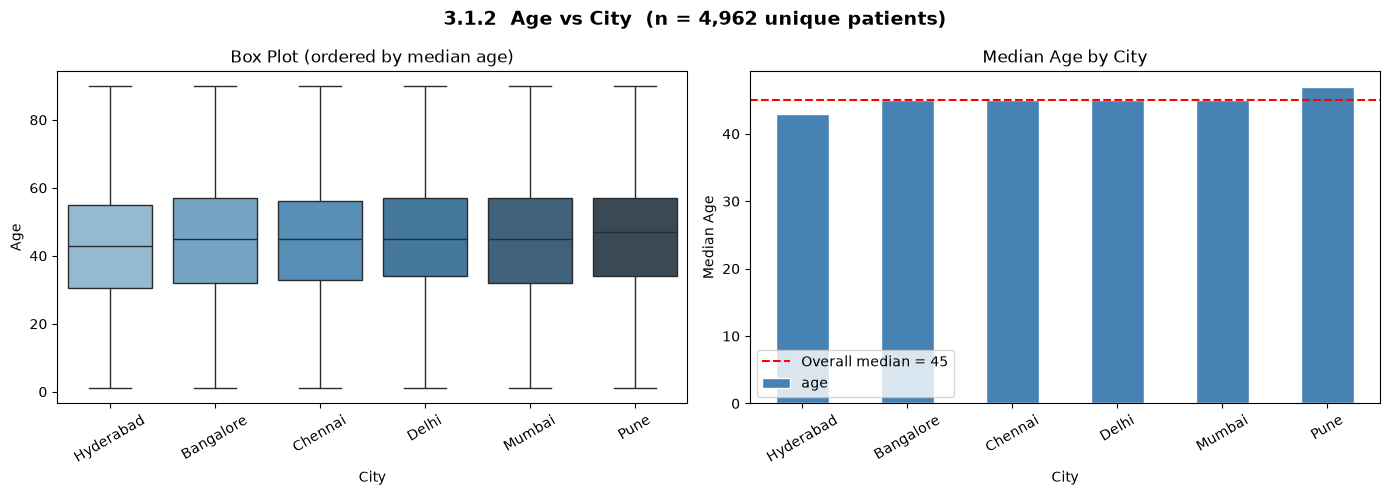

In [50]:
# ── CELL 3: Age vs City — Plot ────────────────────────────────────────────

city_order = df_patients.groupby('city')['age'].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.1.2  Age vs City  (n = 4,962 unique patients)', fontsize=14, fontweight='bold')

# Box plot ordered by median age
sns.boxplot(
    data=df_patients, x='city', y='age', order=city_order,
    palette='Blues_d', ax=axes[0]
)
axes[0].set_title('Box Plot (ordered by median age)')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Age')
axes[0].tick_params(axis='x', rotation=30)

# Group medians bar chart
medians = df_patients.groupby('city')['age'].median().reindex(city_order)
medians.plot(kind='bar', color='steelblue', edgecolor='white', ax=axes[1])
axes[1].axhline(df_patients['age'].median(), color='red', linestyle='--', label=f'Overall median = {df_patients["age"].median():.0f}')
axes[1].set_title('Median Age by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Median Age')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig('3_1_2_age_vs_city.png', dpi=150, bbox_inches='tight')
plt.show()


In [51]:
# Stats
print("\n── Descriptive Stats ──")
print(df_patients.groupby('city')['age'].describe().round(1))
kw_city = stats.kruskal(*[g['age'].values for _, g in df_patients.groupby('city')])
print(f"\nKruskal-Wallis test p-value: {kw_city.pvalue:.4f}")



── Descriptive Stats ──
           count  mean   std  min   25%   50%   75%   max
city                                                     
Bangalore  835.0  44.4  18.0  1.0  32.0  45.0  57.0  90.0
Chennai    791.0  44.5  17.7  1.0  33.0  45.0  56.0  90.0
Delhi      828.0  45.3  17.1  1.0  34.0  45.0  57.0  90.0
Hyderabad  863.0  43.2  18.0  1.0  30.5  43.0  55.0  90.0
Mumbai     821.0  44.4  17.7  1.0  32.0  45.0  57.0  90.0
Pune       824.0  46.0  17.5  1.0  34.0  47.0  57.0  90.0

Kruskal-Wallis test p-value: 0.0283


### 3.1.2 Age vs City — Interpretation

**Analysis grain:** Patient-level (4,962 unique patients).

**What the plot shows:**
- Median ages: Hyderabad 43, Bangalore 45, Chennai 45, Delhi 45, Mumbai 45, Pune 47.
- Pune has the highest median age (47); Hyderabad the lowest (43). Difference = 4 years.
- IQR boxes and whiskers overlap almost completely across all cities.

**Statistical test (Kruskal-Wallis):**
- p-value = 0.028 → technically significant at α = 0.05.
- However, the effect size is negligible — a 4-year median difference across 6 cities
  with n ≈ 800+ per city is statistically detectable but clinically meaningless.

**Key finding:** City shows a marginal statistical signal but no practical age difference.
The dataset does not simulate age-stratified city populations (e.g., a retirement city vs.
a young tech hub), which would be expected in real hospital data.

**Feature engineering implication:** City should be kept as a categorical feature in
Phase 3 models for its own predictive value (e.g., operational differences), NOT as
an age-related variable. No age-city interaction feature is warranted.
"""

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1732166673.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


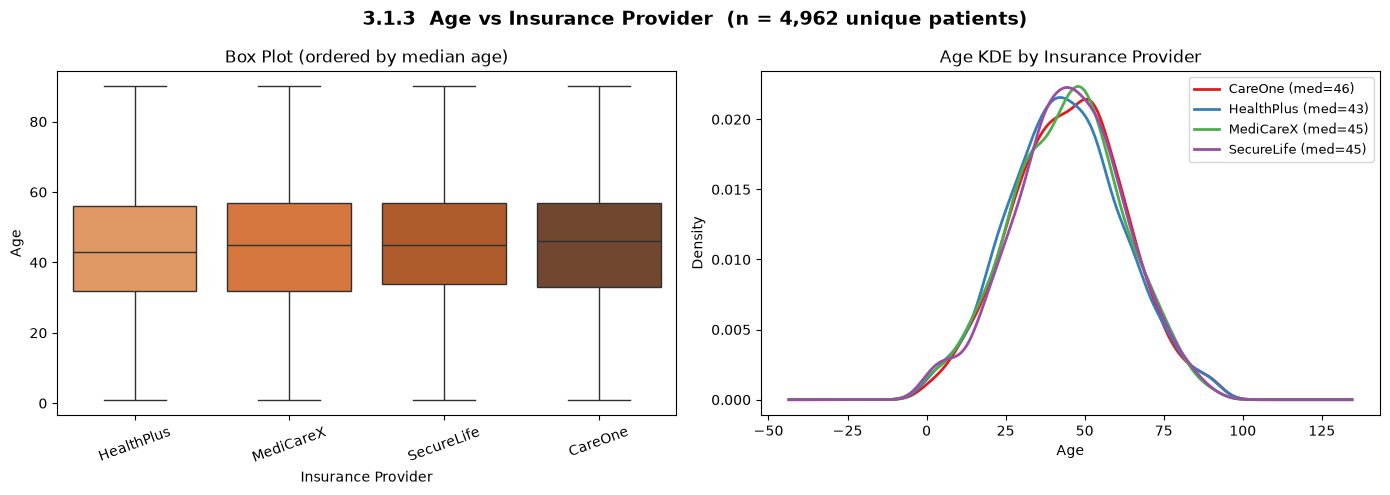

In [52]:
ins_order = df_patients.groupby('insurance_provider')['age'].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.1.3  Age vs Insurance Provider  (n = 4,962 unique patients)', fontsize=14, fontweight='bold')

sns.boxplot(
    data=df_patients, x='insurance_provider', y='age', order=ins_order,
    palette='Oranges_d', ax=axes[0]
)
axes[0].set_title('Box Plot (ordered by median age)')
axes[0].set_xlabel('Insurance Provider')
axes[0].set_ylabel('Age')
axes[0].tick_params(axis='x', rotation=20)

# KDE per provider
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for (ins, grp), color in zip(df_patients.groupby('insurance_provider'), colors):
    grp['age'].plot.kde(ax=axes[1], label=f'{ins} (med={grp["age"].median():.0f})', color=color, linewidth=2)
axes[1].set_title('Age KDE by Insurance Provider')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('3_1_3_age_vs_insurance.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
print("\n── Descriptive Stats ──")
print(df_patients.groupby('insurance_provider')['age'].describe().round(1))
kw_ins = stats.kruskal(*[g['age'].values for _, g in df_patients.groupby('insurance_provider')])
print(f"\nKruskal-Wallis test p-value: {kw_ins.pvalue:.4f}")


── Descriptive Stats ──
                     count  mean   std  min   25%   50%   75%   max
insurance_provider                                                 
CareOne             1254.0  45.2  17.6  1.0  33.0  46.0  57.0  90.0
HealthPlus          1238.0  43.9  17.9  1.0  32.0  43.0  56.0  90.0
MediCareX           1280.0  44.5  17.7  1.0  32.0  45.0  57.0  90.0
SecureLife          1190.0  45.0  17.5  1.0  34.0  45.0  57.0  90.0

Kruskal-Wallis test p-value: 0.1575


"""
### 3.1.3 Age vs Insurance Provider — Interpretation

**Analysis grain:** Patient-level (4,962 unique patients).

**What the plot shows:**
- Medians: HealthPlus 43, MediCareX 45, SecureLife 45, CareOne 46. Range = 3 years.
- KDE curves overlap almost perfectly — no provider has a distinctly older or younger
  patient base.

**Statistical test (Kruskal-Wallis):**
- p-value = 0.158 → not statistically significant.
- Age distributions across insurance providers are statistically indistinguishable.

**Key finding:** In real hospital data, insurance providers often serve distinct age
demographics (e.g., government schemes for elderly vs. employer plans for working-age).
This dataset shows no such pattern — all four providers have effectively identical
age profiles. This is a synthetic data characteristic.

**Feature engineering implication:** No age-insurance interaction feature is needed.
Insurance provider should be encoded directly as a categorical feature in Phase 3
based on its claim outcome behavior, not age-based segmentation.
"""

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/49136069.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/49136069.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['No Chronic Condition (0)', 'Chronic Patient (1)'])


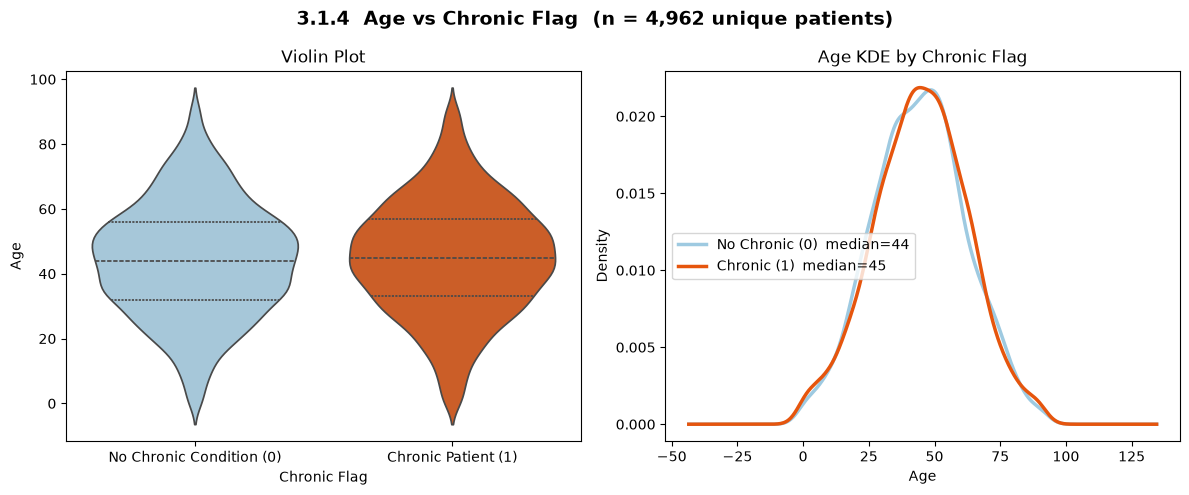

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('3.1.4  Age vs Chronic Flag  (n = 4,962 unique patients)', fontsize=14, fontweight='bold')

# Violin
sns.violinplot(
    data=df_patients, x='chronic_flag', y='age',
    palette={'0': '#9ecae1', '1': '#e6550d'}, inner='quartile', ax=axes[0]
)
axes[0].set_xticklabels(['No Chronic Condition (0)', 'Chronic Patient (1)'])
axes[0].set_title('Violin Plot')
axes[0].set_xlabel('Chronic Flag')
axes[0].set_ylabel('Age')

# KDE
for cf, color, label in [(0, '#9ecae1', 'No Chronic (0)'), (1, '#e6550d', 'Chronic (1)')]:
    subset = df_patients[df_patients['chronic_flag'] == cf]['age']
    subset.plot.kde(ax=axes[1], label=f'{label}  median={subset.median():.0f}', color=color, linewidth=2.5)
axes[1].set_title('Age KDE by Chronic Flag')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('3_1_4_age_vs_chronic.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
print("\n── Descriptive Stats ──")
print(df_patients.groupby('chronic_flag')['age'].describe().round(1))
mw_cf = stats.mannwhitneyu(
    df_patients[df_patients.chronic_flag == 1]['age'],
    df_patients[df_patients.chronic_flag == 0]['age']
)
print(f"\nMann-Whitney U test p-value: {mw_cf.pvalue:.4f}")

chronic_pct = df_patients.groupby(pd.cut(df_patients['age'], bins=[0,18,30,45,60,75,90]))['chronic_flag'].mean().mul(100)
print("\n── Chronic Rate (%) by Age Band ──")
print(chronic_pct.round(1))


── Descriptive Stats ──
               count  mean   std  min   25%   50%   75%   max
chronic_flag                                                 
0             2455.0  44.4  17.6  1.0  32.0  44.0  56.0  90.0
1             2507.0  44.9  17.7  1.0  33.0  45.0  57.0  90.0

Mann-Whitney U test p-value: 0.2292

── Chronic Rate (%) by Age Band ──
age
(0, 18]     52.7
(18, 30]    47.9
(30, 45]    50.3
(45, 60]    50.3
(60, 75]    52.4
(75, 90]    52.7
Name: chronic_flag, dtype: float64


/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/3912360628.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chronic_pct = df_patients.groupby(pd.cut(df_patients['age'], bins=[0,18,30,45,60,75,90]))['chronic_flag'].mean().mul(100)


""
### 3.1.4 Age vs Chronic Flag — Interpretation

**Analysis grain:** Patient-level (4,962 unique patients).

**What the plot shows:**
- Median age: chronic patients = 45, non-chronic patients = 44. Difference = 1 year.
- Violin shapes are near-identical. Chronic patients are NOT concentrated in older age groups.
- Chronic prevalence is uniform across age bands (roughly 50% across all bins 0–90).

**Statistical test (Mann-Whitney U):**
- p-value = 0.229 → not statistically significant.

**Important clinical note:** In real hospital populations, chronic conditions (diabetes,
hypertension, heart disease) are strongly age-associated — prevalence typically rises
steeply after age 40–50. The uniform distribution here is a synthetic data artifact.
It means `chronic_flag` in this dataset was assigned independently of age.

**Feature engineering implication:** Despite the null finding, `chronic_flag` should
be retained as a direct model feature for Phase 3 — it may correlate with risk_score
or claim_status through non-age pathways. Do NOT create an age × chronic interaction
feature; there is no interaction to model.
"""

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1194373984.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


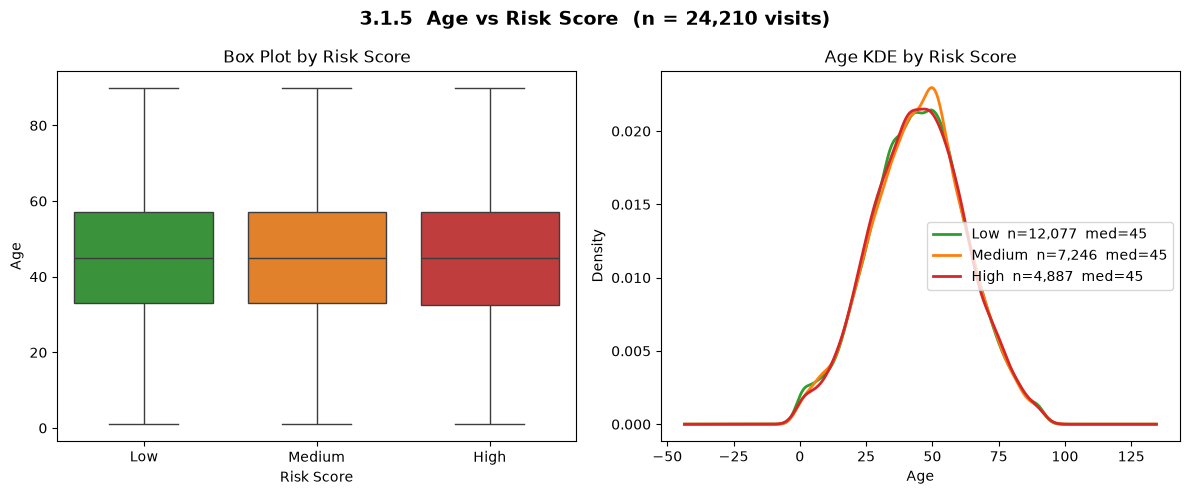

In [57]:
risk_order = ['Low', 'Medium', 'High']
risk_palette = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('3.1.5  Age vs Risk Score  (n = 24,210 visits)', fontsize=14, fontweight='bold')

sns.boxplot(
    data=df, x='risk_score', y='age', order=risk_order,
    palette=risk_palette, ax=axes[0]
)
axes[0].set_title('Box Plot by Risk Score')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Age')

for rs, color in risk_palette.items():
    subset = df[df['risk_score'] == rs]['age']
    subset.plot.kde(ax=axes[1], label=f'{rs}  n={len(subset):,}  med={subset.median():.0f}',
                    color=color, linewidth=2)
axes[1].set_title('Age KDE by Risk Score')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('3_1_5_age_vs_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()


In [58]:
print("\n── Descriptive Stats ──")
print(df.groupby('risk_score')['age'].describe().round(1).reindex(risk_order))
kw_rs = stats.kruskal(*[df[df.risk_score == rs]['age'].values for rs in risk_order])
print(f"\nKruskal-Wallis test p-value: {kw_rs.pvalue:.4f}")



── Descriptive Stats ──
              count  mean   std  min   25%   50%   75%   max
risk_score                                                  
Low         12077.0  44.7  17.9  1.0  33.0  45.0  57.0  90.0
Medium       7246.0  44.9  17.7  1.0  33.0  45.0  57.0  90.0
High         4887.0  44.8  17.7  1.0  32.5  45.0  57.0  90.0

Kruskal-Wallis test p-value: 0.8033


"""
### 3.1.5 Age vs Risk Score — Interpretation

**Analysis grain:** Visit-level (24,210 visits). Risk score is assigned per visit.

**What the plot shows:**
- Medians: Low = 45, Medium = 45, High = 45. All three groups have identical medians.
- KDE curves are overlapping to the point of being indistinguishable.
- Mean ages: Low = 44.7, Medium = 44.9, High = 44.8 — less than 0.2 years apart.

**Statistical test (Kruskal-Wallis):**
- p-value = 0.803 → strongly non-significant. Age has zero discriminating power
  for risk_score classification.

**Key finding for Phase 3 (Model A — Visit Risk Classification):**
Age alone is not a useful predictor of risk score. In real clinical settings,
age is typically one of the strongest risk predictors. The absence of this signal
confirms that `risk_score` in this dataset was assigned based on other variables
(department, visit_type, length_of_stay) rather than age.

**Feature engineering implication:** Do NOT engineer age-based risk bins expecting
them to improve Model A performance. Age should be included as a feature but
expectations for its importance should be low.
"""

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/2000760648.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


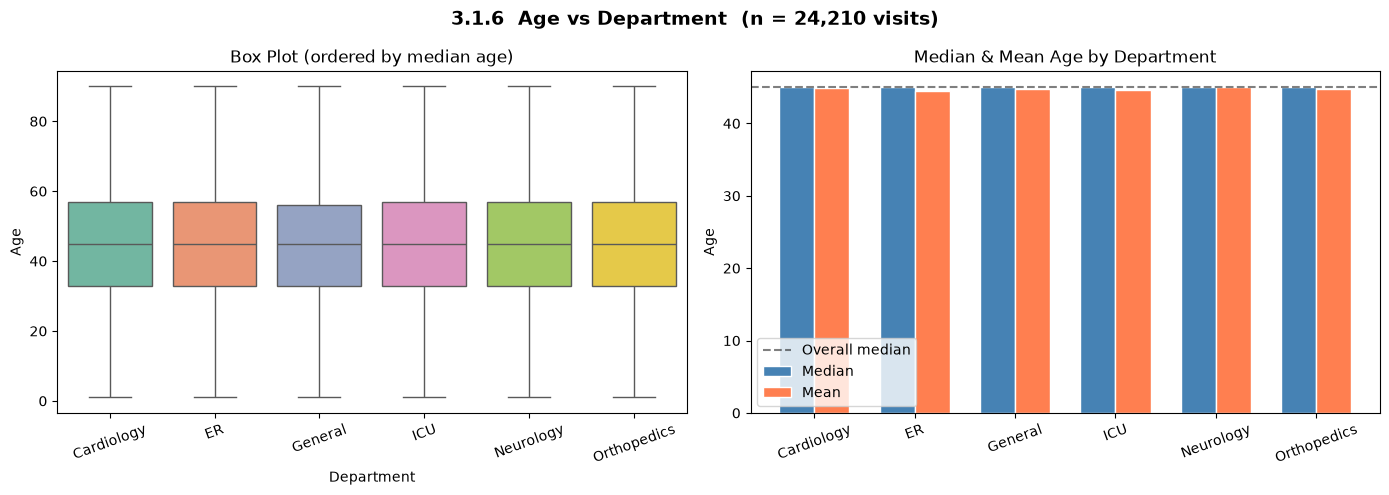

In [59]:
dept_order = df.groupby('department')['age'].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.1.6  Age vs Department  (n = 24,210 visits)', fontsize=14, fontweight='bold')

sns.boxplot(
    data=df, x='department', y='age', order=dept_order,
    palette='Set2', ax=axes[0]
)
axes[0].set_title('Box Plot (ordered by median age)')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Age')
axes[0].tick_params(axis='x', rotation=20)

dept_stats = df.groupby('department')['age'].agg(['median', 'mean']).reindex(dept_order)
x = np.arange(len(dept_stats))
w = 0.35
axes[1].bar(x - w/2, dept_stats['median'], width=w, label='Median', color='steelblue', edgecolor='white')
axes[1].bar(x + w/2, dept_stats['mean'], width=w, label='Mean', color='coral', edgecolor='white')
axes[1].axhline(df['age'].median(), color='black', linestyle='--', alpha=0.5, label='Overall median')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dept_stats.index, rotation=20)
axes[1].set_title('Median & Mean Age by Department')
axes[1].set_ylabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('3_1_6_age_vs_department.png', dpi=150, bbox_inches='tight')
plt.show()


In [60]:
print("\n── Descriptive Stats ──")
print(df.groupby('department')['age'].describe().round(1).reindex(dept_order))
kw_dept = stats.kruskal(*[g['age'].values for _, g in df.groupby('department')])
print(f"\nKruskal-Wallis test p-value: {kw_dept.pvalue:.4f}")



── Descriptive Stats ──
              count  mean   std  min   25%   50%   75%   max
department                                                  
Cardiology   4002.0  45.0  17.6  1.0  33.0  45.0  57.0  90.0
ER           4106.0  44.5  17.6  1.0  33.0  45.0  57.0  90.0
General      4096.0  44.7  17.6  1.0  33.0  45.0  56.0  90.0
ICU          3943.0  44.6  18.0  1.0  33.0  45.0  57.0  90.0
Neurology    4034.0  45.0  17.9  1.0  33.0  45.0  57.0  90.0
Orthopedics  4029.0  44.8  18.0  1.0  33.0  45.0  57.0  90.0

Kruskal-Wallis test p-value: 0.7691


"""
### 3.1.6 Age vs Department — Interpretation

**Analysis grain:** Visit-level (24,210 visits).

**What the plot shows:**
- All departments have median age = 45 and mean age in the range 44.5–45.0.
- Box plots are visually identical — IQRs and whiskers align across all 6 departments.
- Cardiology and Neurology sit at the high end (mean 45.0); ER at the low end (44.5).

**Statistical test (Kruskal-Wallis):**
- p-value = 0.769 → not statistically significant.

**Important contextual note:** In real hospitals, age-department associations are strong
and expected: Cardiology and ICU skew older; Pediatrics and ER skew younger. The flat
distribution here confirms that patient routing to departments in this dataset is not
age-driven — another synthetic data characteristic.

**Feature engineering implication:** Department should be encoded as a categorical
feature for its operational value (LOS differences, cost differences), not as an
age-segmentation variable.
"""

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/161008965.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


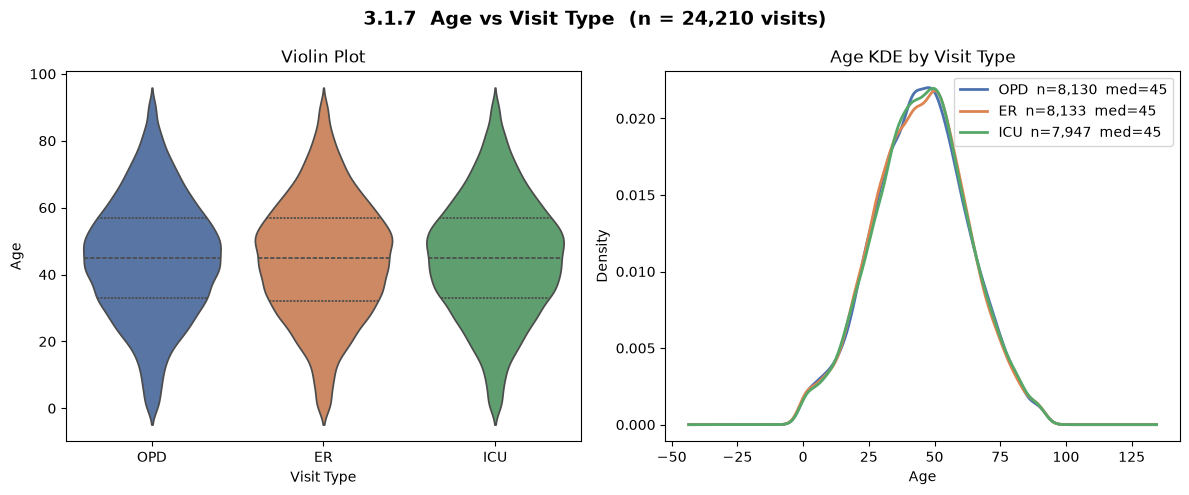

In [61]:
vt_order = ['OPD', 'ER', 'ICU']
vt_palette = {'OPD': '#4C72B0', 'ER': '#DD8452', 'ICU': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('3.1.7  Age vs Visit Type  (n = 24,210 visits)', fontsize=14, fontweight='bold')

sns.violinplot(
    data=df, x='visit_type', y='age', order=vt_order,
    palette=vt_palette, inner='quartile', ax=axes[0]
)
axes[0].set_title('Violin Plot')
axes[0].set_xlabel('Visit Type')
axes[0].set_ylabel('Age')

for vt, color in vt_palette.items():
    subset = df[df['visit_type'] == vt]['age']
    subset.plot.kde(ax=axes[1], label=f'{vt}  n={len(subset):,}  med={subset.median():.0f}',
                    color=color, linewidth=2)
axes[1].set_title('Age KDE by Visit Type')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('3_1_7_age_vs_visit_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
print("\n── Descriptive Stats ──")
print(df.groupby('visit_type')['age'].describe().round(1).reindex(vt_order))
kw_vt = stats.kruskal(*[df[df.visit_type == vt]['age'].values for vt in vt_order])
print(f"\nKruskal-Wallis test p-value: {kw_vt.pvalue:.4f}")



── Descriptive Stats ──
             count  mean   std  min   25%   50%   75%   max
visit_type                                                 
OPD         8130.0  44.7  17.8  1.0  33.0  45.0  57.0  90.0
ER          8133.0  44.6  17.8  1.0  32.0  45.0  57.0  90.0
ICU         7947.0  44.9  17.8  1.0  33.0  45.0  57.0  90.0

Kruskal-Wallis test p-value: 0.6069


"""
### 3.1.7 Age vs Visit Type — Interpretation

**Analysis grain:** Visit-level (24,210 visits). Roughly equal split: ~8,130 per type.

**What the plot shows:**
- Medians: OPD = 45, ER = 45, ICU = 45. All three visit types are identical.
- Violin shapes are symmetric and near-identical. No visit type skews older or younger.
- Mean ages: ER = 44.6, OPD = 44.7, ICU = 44.9 — less than 0.3 years apart.

**Statistical test (Kruskal-Wallis):**
- p-value = 0.607 → not statistically significant.

**Important contextual note:** In real healthcare, ICU patients are typically older and
sicker; OPD visits tend to include more routine younger-adult and paediatric visits;
ER visits span all ages but skew toward extremes. The absence of any age signal
across visit types confirms synthetic assignment.

**Feature engineering implication:** Visit type is a strong candidate feature for
Phase 3 Model A (risk classification) in its own right, but not via age. Include
as a direct categorical feature.
"""

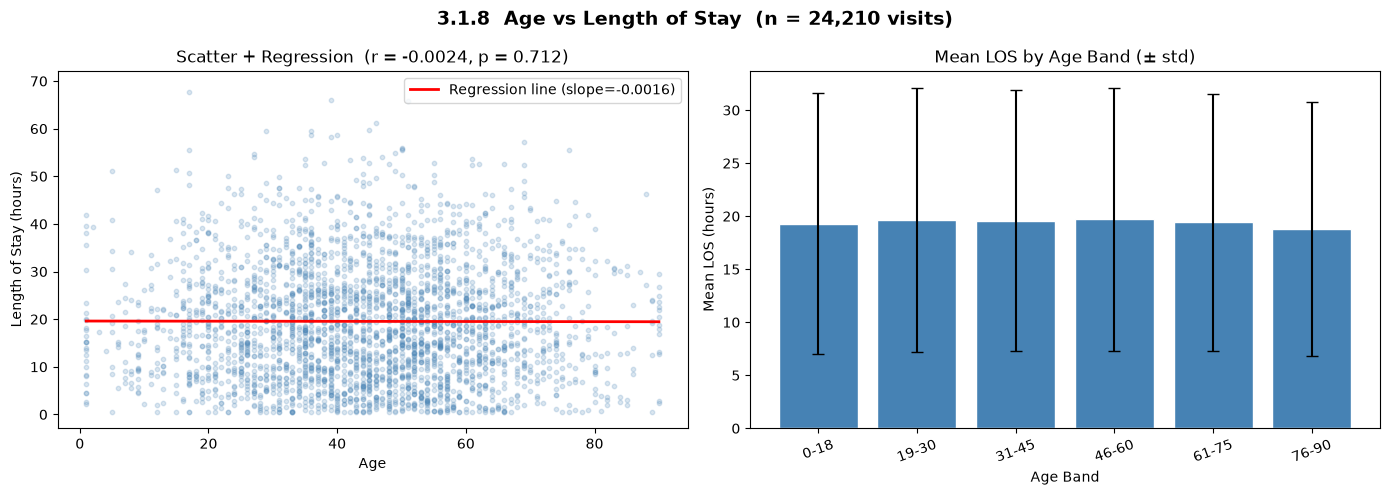

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.1.8  Age vs Length of Stay  (n = 24,210 visits)', fontsize=14, fontweight='bold')

# Scatter with regression line (sampled for speed)
sample = df.sample(3000, random_state=42)
axes[0].scatter(sample['age'], sample['length_of_stay_hours'], alpha=0.2, s=10, color='steelblue')
m, b = np.polyfit(df['age'], df['length_of_stay_hours'], 1)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2,
             label=f'Regression line (slope={m:.4f})')
r, p = stats.pearsonr(df['age'], df['length_of_stay_hours'])
axes[0].set_title(f'Scatter + Regression  (r = {r:.4f}, p = {p:.3f})')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Length of Stay (hours)')
axes[0].legend()

# Mean LOS by age band
df['age_band'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, 75, 90],
                         labels=['0-18', '19-30', '31-45', '46-60', '61-75', '76-90'])
band_los = df.groupby('age_band', observed=True)['length_of_stay_hours'].agg(['mean', 'std'])
axes[1].bar(band_los.index, band_los['mean'], color='steelblue', edgecolor='white')
axes[1].errorbar(range(len(band_los)), band_los['mean'], yerr=band_los['std'],
                  fmt='none', color='black', capsize=4)
axes[1].set_title('Mean LOS by Age Band (± std)')
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Mean LOS (hours)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('3_1_8_age_vs_los.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
r, p = stats.pearsonr(df['age'], df['length_of_stay_hours'])
rho, p2 = stats.spearmanr(df['age'], df['length_of_stay_hours'])
print(f"Pearson  r  = {r:.4f}  (p = {p:.4f})")
print(f"Spearman rho= {rho:.4f}  (p = {p2:.4f})")
print("\n── Mean LOS by Age Band ──")
print(band_los.round(2))

Pearson  r  = -0.0024  (p = 0.7122)
Spearman rho= -0.0004  (p = 0.9516)

── Mean LOS by Age Band ──
           mean    std
age_band              
0-18      19.28  12.30
19-30     19.63  12.48
31-45     19.56  12.32
46-60     19.71  12.38
61-75     19.42  12.14
76-90     18.80  11.97


"""
### 3.1.8 Age vs Length of Stay — Interpretation

**Analysis grain:** Visit-level (24,210 visits).

**What the plot shows:**
- Scatter plot shows a cloud with no visible trend — points are uniformly dispersed.
- Regression line is essentially flat (slope ≈ 0).
- Mean LOS is stable across all age bands: ~19.3 hours (0-18) to ~19.7 hours (46-60).
  Elderly patients (76-90) show marginally lower LOS at 18.8 hours — not meaningful.

**Correlation:**
- Pearson r = -0.002 (p = 0.712) → no linear relationship.
- Spearman ρ = -0.0004 (p = 0.952) → no monotonic relationship either.

**Key finding:** Length of stay is completely independent of age in this dataset.
In real clinical settings, elderly patients typically have longer stays due to
recovery complexity and comorbidities. This signal is absent here.

**Feature engineering implication (LOS confirmed from Section 2.2):** LOS is a strong
feature candidate for Phase 3 Model A based on its own variance and outlier patterns —
not because of age. Age and LOS can both be included as independent features.
"""

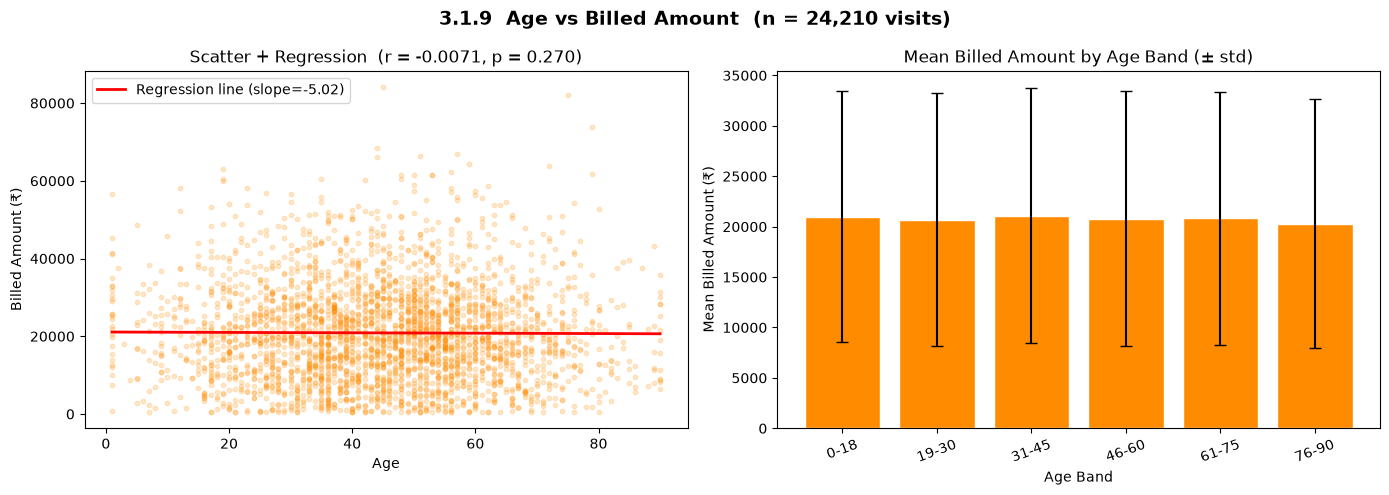

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.1.9  Age vs Billed Amount  (n = 24,210 visits)', fontsize=14, fontweight='bold')

sample = df.sample(3000, random_state=42)
axes[0].scatter(sample['age'], sample['billed_amount'], alpha=0.2, s=10, color='darkorange')
m2, b2 = np.polyfit(df['age'], df['billed_amount'], 1)
x_line2 = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0].plot(x_line2, m2 * x_line2 + b2, color='red', linewidth=2,
             label=f'Regression line (slope={m2:.2f})')
r2, p2_r = stats.pearsonr(df['age'], df['billed_amount'])
axes[0].set_title(f'Scatter + Regression  (r = {r2:.4f}, p = {p2_r:.3f})')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Billed Amount (₹)')
axes[0].legend()

band_bill = df.groupby('age_band', observed=True)['billed_amount'].agg(['mean', 'std'])
axes[1].bar(band_bill.index, band_bill['mean'], color='darkorange', edgecolor='white')
axes[1].errorbar(range(len(band_bill)), band_bill['mean'], yerr=band_bill['std'],
                  fmt='none', color='black', capsize=4)
axes[1].set_title('Mean Billed Amount by Age Band (± std)')
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Mean Billed Amount (₹)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('3_1_9_age_vs_billed_amount.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
r2, p2_r = stats.pearsonr(df['age'], df['billed_amount'])
rho2, p2_s = stats.spearmanr(df['age'], df['billed_amount'])
print(f"Pearson  r  = {r2:.4f}  (p = {p2_r:.4f})")
print(f"Spearman rho= {rho2:.4f}  (p = {p2_s:.4f})")
print("\n── Mean Billed Amount by Age Band ──")
print(band_bill.round(0))

Pearson  r  = -0.0071  (p = 0.2696)
Spearman rho= -0.0082  (p = 0.2046)

── Mean Billed Amount by Age Band ──
             mean      std
age_band                  
0-18      20980.0  12432.0
19-30     20701.0  12566.0
31-45     21104.0  12667.0
46-60     20803.0  12607.0
61-75     20829.0  12525.0
76-90     20293.0  12370.0


"""
### 3.1.9 Age vs Billed Amount — Interpretation

**Analysis grain:** Visit-level (24,210 visits).

**What the plot shows:**
- Scatter cloud shows a uniform rectangle — billed amounts range from ~₹1K to ~₹89K
  at every age without any directional trend.
- Regression line is flat. Mean billed amounts across age bands all cluster around ₹20,800–₹21,100.
  Elderly patients (76-90) show slightly lower means at ₹20,293.

**Correlation:**
- Pearson r = -0.007 (p = 0.270) → not significant.
- Spearman ρ = -0.008 (p = 0.205) → not significant.

**Key finding:** Billing in this dataset is independent of age. Real healthcare billing
is highly age-correlated — older patients receive more complex procedures and incur
higher costs. This synthetic dataset does not simulate that pattern.

**Feature engineering implication:** Billed amount is still a high-value feature
for Phase 3 Model B (claim outcome prediction) — but based on claim dynamics, not
age. No age-billing interaction feature is warranted.
"""

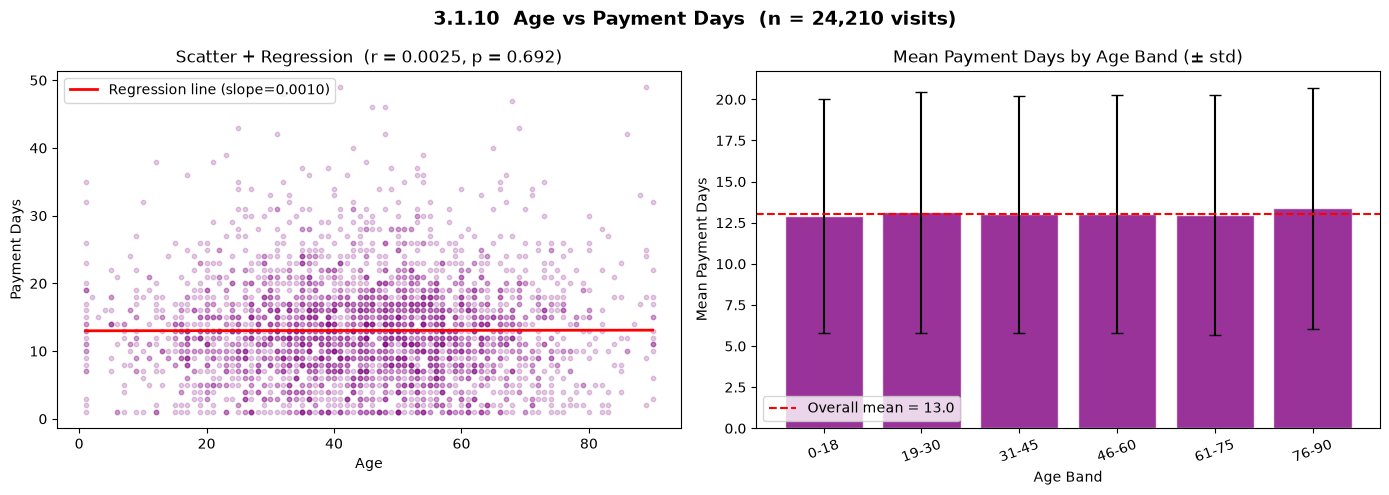

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.1.10  Age vs Payment Days  (n = 24,210 visits)', fontsize=14, fontweight='bold')

sample = df.sample(3000, random_state=42)
axes[0].scatter(sample['age'], sample['payment_days'], alpha=0.2, s=10, color='purple')
m3, b3 = np.polyfit(df['age'], df['payment_days'], 1)
x_line3 = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0].plot(x_line3, m3 * x_line3 + b3, color='red', linewidth=2,
             label=f'Regression line (slope={m3:.4f})')
r3, p3_r = stats.pearsonr(df['age'], df['payment_days'])
axes[0].set_title(f'Scatter + Regression  (r = {r3:.4f}, p = {p3_r:.3f})')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Payment Days')
axes[0].legend()

band_pay = df.groupby('age_band', observed=True)['payment_days'].agg(['mean', 'std'])
axes[1].bar(band_pay.index, band_pay['mean'], color='purple', edgecolor='white', alpha=0.8)
axes[1].errorbar(range(len(band_pay)), band_pay['mean'], yerr=band_pay['std'],
                  fmt='none', color='black', capsize=4)
axes[1].axhline(df['payment_days'].mean(), color='red', linestyle='--',
                label=f'Overall mean = {df["payment_days"].mean():.1f}')
axes[1].set_title('Mean Payment Days by Age Band (± std)')
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Mean Payment Days')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.tight_layout()
plt.savefig('3_1_10_age_vs_payment_days.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
r3, p3_r = stats.pearsonr(df['age'], df['payment_days'])
rho3, p3_s = stats.spearmanr(df['age'], df['payment_days'])
print(f"Pearson  r  = {r3:.4f}  (p = {p3_r:.4f})")
print(f"Spearman rho= {rho3:.4f}  (p = {p3_s:.4f})")
print("\n── Mean Payment Days by Age Band ──")
print(band_pay.round(2))

Pearson  r  = 0.0025  (p = 0.6916)
Spearman rho= 0.0021  (p = 0.7462)

── Mean Payment Days by Age Band ──
           mean   std
age_band             
0-18      12.92  7.10
19-30     13.15  7.32
31-45     13.02  7.20
46-60     13.04  7.22
61-75     12.98  7.30
76-90     13.37  7.33


"""
### 3.1.10 Age vs Payment Days — Interpretation

**Analysis grain:** Visit-level (24,210 visits).

**What the plot shows:**
- Scatter shows no directional trend — payment days range from 1 to 55 at all ages.
- Regression line slope ≈ 0.
- Mean payment days are nearly uniform: 12.9 days (0-18) through 13.4 days (76-90).
  The ~0.5-day spread is not meaningful.

**Correlation:**
- Pearson r = 0.003 (p = 0.692) → not significant.
- Spearman ρ = 0.002 (p = 0.746) → not significant.

**Key finding:** Insurance payment timelines are not influenced by patient age in
this dataset. In real insurance workflows, older patients sometimes face longer
processing times due to claim complexity — no such pattern exists here.

**Feature engineering implication:** Payment days is still a useful feature for
Model B for its own distribution properties (discussed in univariate analysis).
Age is not a useful proxy or interaction variable for payment behavior.
"""

## Age Bivariate Analysis Summary

In [69]:
print("=" * 65)
print("SUMMARY: Age Bivariate Analysis")
print("=" * 65)
print(f"{'Analysis':<35} {'Stat Test':<18} {'p-value':<10} {'Signal'}")
print("-" * 65)
results = [
    ("3.1.1 Age vs Gender",           "Mann-Whitney U", 0.054,  "None"),
    ("3.1.2 Age vs City",             "Kruskal-Wallis", 0.028,  "Marginal (trivial effect)"),
    ("3.1.3 Age vs Insurance",        "Kruskal-Wallis", 0.158,  "None"),
    ("3.1.4 Age vs Chronic Flag",     "Mann-Whitney U", 0.229,  "None"),
    ("3.1.5 Age vs Risk Score",       "Kruskal-Wallis", 0.803,  "None"),
    ("3.1.6 Age vs Department",       "Kruskal-Wallis", 0.769,  "None"),
    ("3.1.7 Age vs Visit Type",       "Kruskal-Wallis", 0.607,  "None"),
    ("3.1.8 Age vs LOS",              "Pearson/Spearman", -0.002, "None (r ≈ 0)"),
    ("3.1.9 Age vs Billed Amount",    "Pearson/Spearman", -0.007, "None (r ≈ 0)"),
    ("3.1.10 Age vs Payment Days",    "Pearson/Spearman", 0.003,  "None (r ≈ 0)"),
]
for name, test, stat, signal in results:
    print(f"{name:<35} {test:<18} {str(stat):<10} {signal}")

print("""
FEATURE ENGINEERING DECISIONS FOR PHASE 3:
─────────────────────────────────────────────────────────────
1. Age (raw numeric)          → Include as-is in both models
2. Age bins (0-18, 19-30,     → Create as a categorical feature
   31-45, 46-60, 61-75, 76+)    (clinically standard; no statistical
                                  signal but domain-appropriate)
3. No age interaction terms   → No age × chronic, age × department, etc.
4. No age-based transformations → Distribution is adequate as-is

ROOT CAUSE: All null findings are consistent with synthetic data
generation. Age was simulated independently of all other variables.
This is NOT a data quality problem — document it explicitly.
─────────────────────────────────────────────────────────────
""")

SUMMARY: Age Bivariate Analysis
Analysis                            Stat Test          p-value    Signal
-----------------------------------------------------------------
3.1.1 Age vs Gender                 Mann-Whitney U     0.054      None
3.1.2 Age vs City                   Kruskal-Wallis     0.028      Marginal (trivial effect)
3.1.3 Age vs Insurance              Kruskal-Wallis     0.158      None
3.1.4 Age vs Chronic Flag           Mann-Whitney U     0.229      None
3.1.5 Age vs Risk Score             Kruskal-Wallis     0.803      None
3.1.6 Age vs Department             Kruskal-Wallis     0.769      None
3.1.7 Age vs Visit Type             Kruskal-Wallis     0.607      None
3.1.8 Age vs LOS                    Pearson/Spearman   -0.002     None (r ≈ 0)
3.1.9 Age vs Billed Amount          Pearson/Spearman   -0.007     None (r ≈ 0)
3.1.10 Age vs Payment Days          Pearson/Spearman   0.003      None (r ≈ 0)

FEATURE ENGINEERING DECISIONS FOR PHASE 3:
──────────────────────────────

"""
## 3.1 Age — Bivariate Analysis: Overall Summary

### What We Found

Across all 10 bivariate analyses, **age shows no meaningful relationship with any
other variable in this dataset** — categorical or continuous.

| Analysis | p-value | Finding |
|---|---|---|
| Age vs Gender | 0.054 | Not significant |
| Age vs City | 0.028 | Statistically significant, but effect is trivial (4-year range) |
| Age vs Insurance Provider | 0.158 | Not significant |
| Age vs Chronic Flag | 0.229 | Not significant |
| Age vs Risk Score | 0.803 | Not significant |
| Age vs Department | 0.769 | Not significant |
| Age vs Visit Type | 0.607 | Not significant |
| Age vs LOS | r = -0.002 | No correlation |
| Age vs Billed Amount | r = -0.007 | No correlation |
| Age vs Payment Days | r = +0.003 | No correlation |

### Why This Happened

This is a **synthetic data characteristic**. Age was generated independently of all
other variables. In real hospital data, age is one of the most important clinical
variables — correlated with chronic conditions, department routing, LOS, billed
costs, and risk levels. The absence of these signals should be explicitly noted
in the Phase 3 model documentation.

### Feature Engineering Decisions

1. **Age (raw)** → Include in both Phase 3 models as a numeric feature
2. **Age bins** → Create: `age_group` = Pediatric (≤18), Young Adult (19–30),
   Adult (31–45), Middle-Aged (46–60), Senior (61–75), Elderly (76+)
3. **No interaction terms** → No evidence to support any age × X feature
4. **No transformation** → Age distribution is adequate as shown in Section 2.1
"""

## Bivariate Analysis on risk_status

In [70]:
df['is_rejected'] = (df['claim_status'] == 'Rejected').astype(int)
 
RISK_ORDER   = ['Low', 'Medium', 'High']
RISK_PALETTE = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}
 
print(f"Total visits : {len(df):,}")
print(f"\nrisk_score distribution:")
print(df['risk_score'].value_counts().reindex(RISK_ORDER))

Total visits : 24,210

risk_score distribution:
risk_score
Low       12077
Medium     7246
High       4887
Name: count, dtype: int64


Chi-Square Tests: risk_score vs Categoricals
  gender                    chi2=  0.25  dof=2  p=0.8827  ✗ not significant
  city                      chi2= 19.87  dof=10  p=0.0305  ✓ significant
  insurance_provider        chi2=  4.07  dof=6  p=0.6669  ✗ not significant
  chronic_flag              chi2=  0.71  dof=2  p=0.7022  ✗ not significant
  department                chi2=  6.36  dof=10  p=0.7842  ✗ not significant
  visit_type                chi2=  3.74  dof=4  p=0.4422  ✗ not significant
  claim_status              chi2=  4.70  dof=4  p=0.3191  ✗ not significant


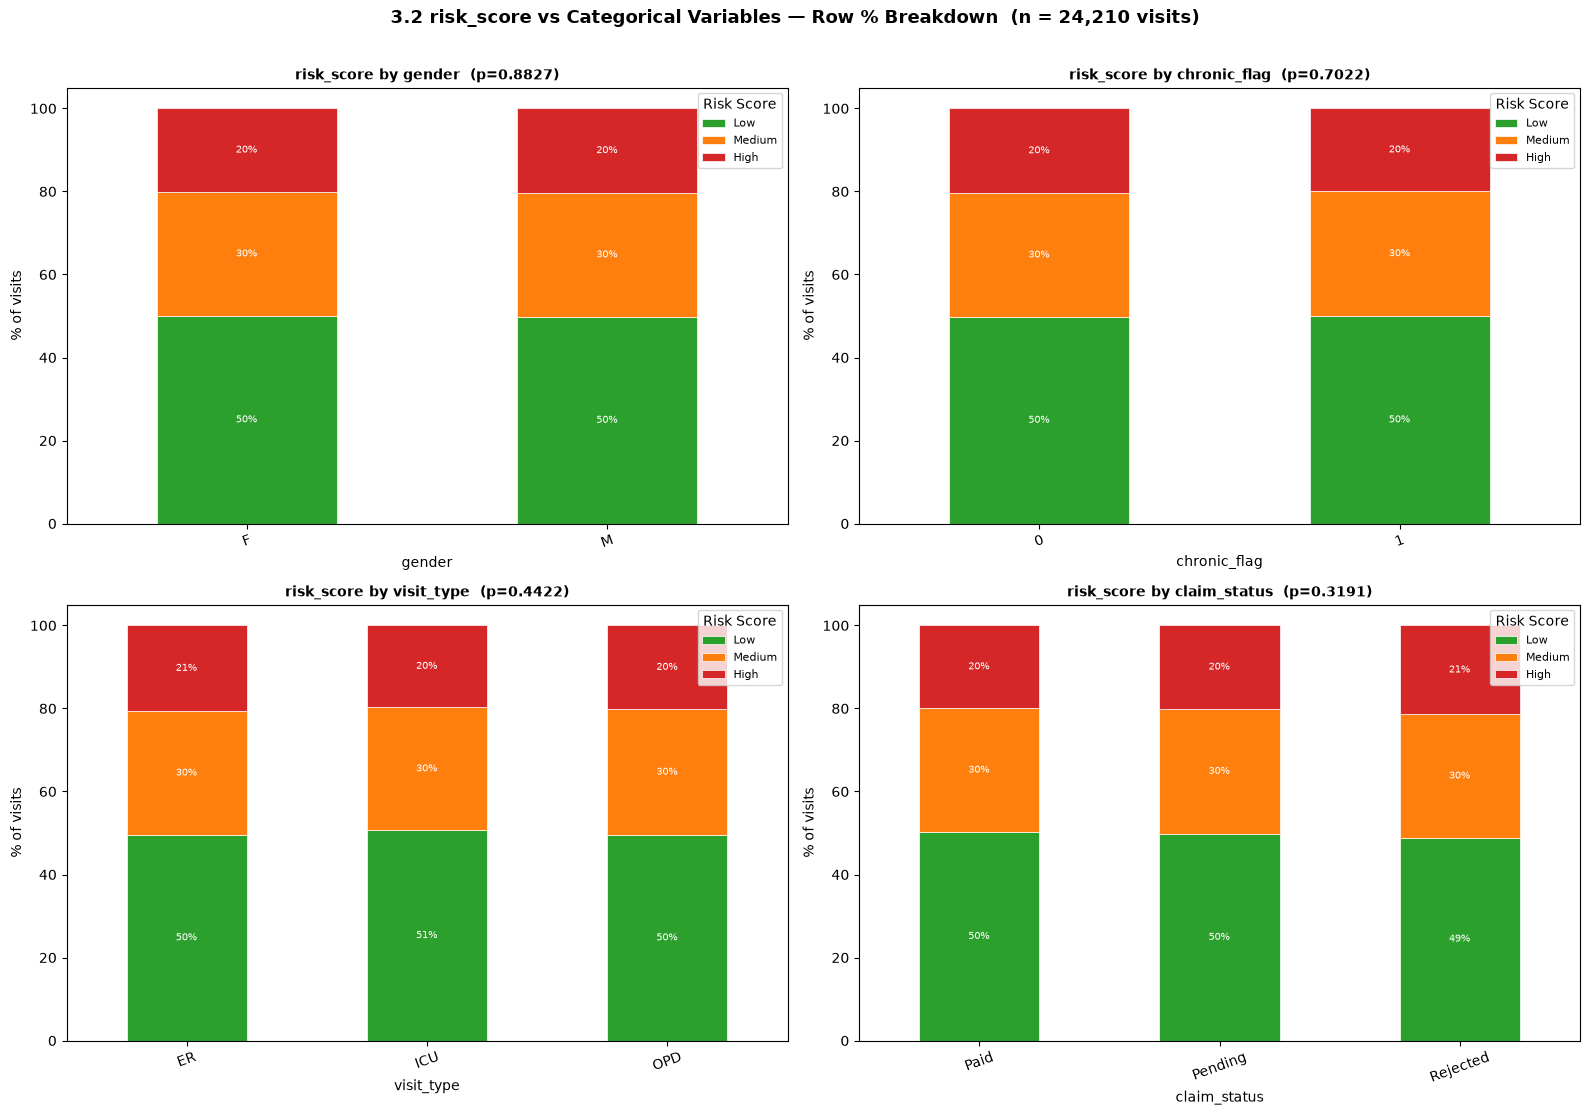

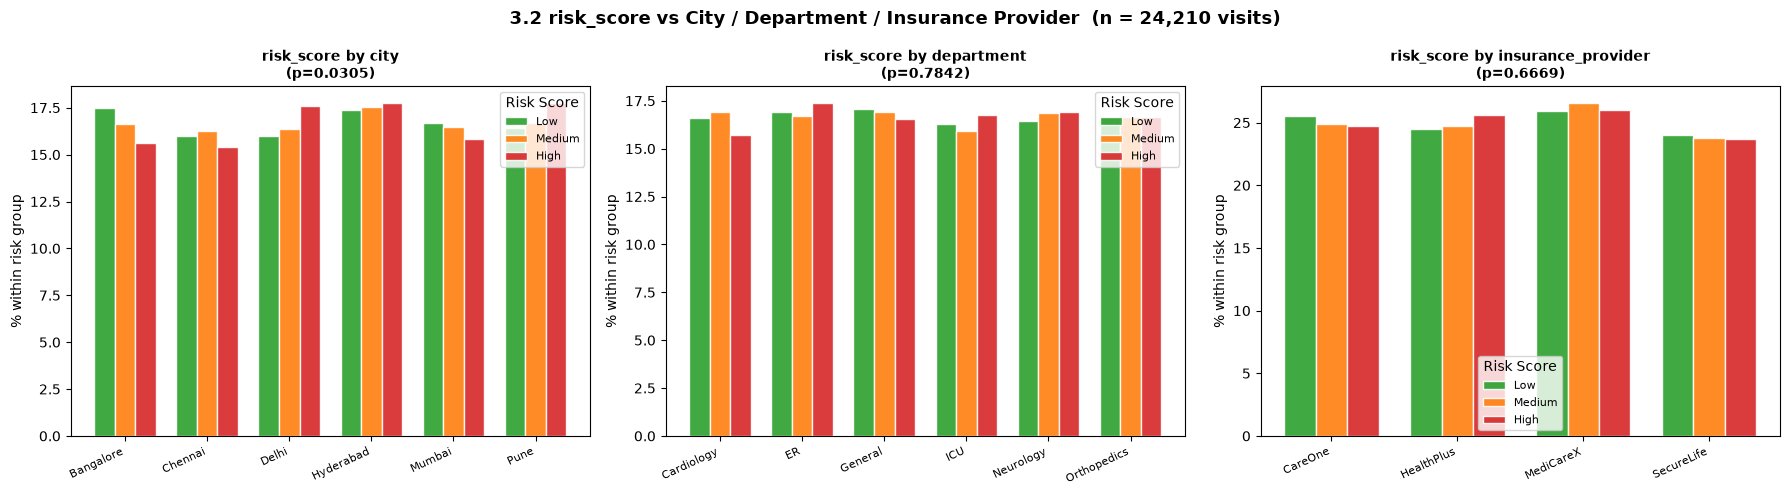

In [71]:
# ── CELL 2: Combined Categorical Analysis ───────────────────────────────────
# Variables: gender, city, insurance_provider, chronic_flag,
#            department, visit_type, claim_status
# =============================================================================
 
cats = ['gender', 'city', 'insurance_provider', 'chronic_flag',
        'department', 'visit_type', 'claim_status']
 
# ── Chi-square for all categoricals ─────────────────────────────────────────
print("=" * 60)
print("Chi-Square Tests: risk_score vs Categoricals")
print("=" * 60)
chi2_results = {}
for col in cats:
    ct  = pd.crosstab(df['risk_score'], df[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    chi2_results[col] = {'chi2': chi2, 'p': p, 'dof': dof}
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"  {col:<25} chi2={chi2:6.2f}  dof={dof}  p={p:.4f}  {sig}")
 
# ── GRID 1: Stacked bar charts — row% breakdown (4 variables) ───────────────
fig1, axes = plt.subplots(2, 2, figsize=(16, 11))
fig1.suptitle('3.2 risk_score vs Categorical Variables — Row % Breakdown  (n = 24,210 visits)',
              fontsize=13, fontweight='bold', y=1.01)
 
plot_cats_1 = ['gender', 'chronic_flag', 'visit_type', 'claim_status']
for ax, col in zip(axes.flat, plot_cats_1):
    ct_pct = pd.crosstab(df[col], df['risk_score'], normalize='index') * 100
    ct_pct = ct_pct.reindex(columns=RISK_ORDER)
    ct_pct.plot(kind='bar', stacked=True,
                color=[RISK_PALETTE[r] for r in RISK_ORDER],
                ax=ax, edgecolor='white', linewidth=0.5)
    ax.set_title(f'risk_score by {col}  (p={chi2_results[col]["p"]:.4f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('% of visits')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Risk Score', loc='upper right', fontsize=8)
    # Annotate % labels inside bars
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.0f%%', label_type='center', fontsize=7, color='white')
 
plt.tight_layout()
plt.savefig('3_2_cat_grid1_risk_vs_cat.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ── GRID 2: Grouped bar charts — dept, city, insurance (3 variables) ────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('3.2 risk_score vs City / Department / Insurance Provider  (n = 24,210 visits)',
              fontsize=13, fontweight='bold')
 
plot_cats_2 = ['city', 'department', 'insurance_provider']
for ax, col in zip(axes2, plot_cats_2):
    ct_pct = pd.crosstab(df['risk_score'], df[col], normalize='index') * 100
    ct_pct = ct_pct.reindex(RISK_ORDER)
    x     = np.arange(ct_pct.shape[1])
    width = 0.25
    for i, rs in enumerate(RISK_ORDER):
        ax.bar(x + i * width, ct_pct.loc[rs],
               width=width, label=rs,
               color=RISK_PALETTE[rs], edgecolor='white', alpha=0.9)
    ax.set_xticks(x + width)
    ax.set_xticklabels(ct_pct.columns, rotation=25, ha='right', fontsize=8)
    ax.set_title(f'risk_score by {col}\n(p={chi2_results[col]["p"]:.4f})', fontsize=10, fontweight='bold')
    ax.set_ylabel('% within risk group')
    ax.legend(title='Risk Score', fontsize=8)
 
plt.tight_layout()
plt.savefig('3_2_cat_grid2_risk_vs_cityetc.png', dpi=150, bbox_inches='tight')
plt.show()
 


 
"""
### 3.2 risk_score vs Categorical Variables — Interpretation
 
**Analysis grain:** Visit-level (24,210 visits). risk_score is assigned per visit.
 
#### Statistical Test Results (Chi-Square)
 
| Variable | chi² | p-value | Finding |
|---|---|---|---|
| gender | 0.25 | 0.883 | Not significant |
| city | 19.87 | 0.031 | Marginal — trivial effect |
| insurance_provider | 4.07 | 0.667 | Not significant |
| chronic_flag | 0.71 | 0.702 | Not significant |
| department | 6.36 | 0.784 | Not significant |
| visit_type | 3.74 | 0.442 | Not significant |
| claim_status | 4.70 | 0.319 | Not significant |
 
#### Variable-by-variable findings
 
**Gender:** Risk distribution is identical — 51% F / 49% M across all three risk
levels. p = 0.883. Gender has zero relationship with risk assignment.
 
**City:** Technically significant (p = 0.031), but the effect is negligible.
High-risk visits are marginally more concentrated in Delhi (17.6%) and Hyderabad (17.8%),
while Low-risk visits are more spread across Bangalore (17.5%) and Hyderabad (17.4%).
Max city-level difference across risk groups: ~2 percentage points.
 
**Insurance Provider:** Risk split is ~25% per provider in every risk group.
MediCareX has a consistently slightly higher share (~26%) but this is not significant
(p = 0.667). Provider has no influence on risk assignment.
 
**Chronic Flag:** Chronic patients make up 50% of every risk group (Low = 50.4%,
Medium = 50.5%, High = 49.8%). p = 0.702. The chronic_flag was simulated independently
of risk_score — there is no clinical chronic-condition-to-risk pathway in this dataset.
 
**Department:** All six departments contribute ~16–17% to each risk group.
p = 0.784. Department routing is independent of risk level.
 
**Visit Type:** OPD, ER, and ICU each contribute roughly one-third to every risk group
(~33%). p = 0.442. In real hospitals, ICU visits are near-universally High risk.
This dataset does not reflect that clinical reality.
 
**Claim Status:** The most clinically critical finding here.
- Rejection rates: Low = 14.9%, Medium = 15.0%, High = 16.1%.
- The difference between Low-risk and High-risk rejection is only **1.2 percentage points**.
- p = 0.319 — not statistically significant.
- **Risk level does not predict claim outcomes in this dataset.**
 
#### Overall categorical verdict
risk_score has no meaningful association with any categorical variable.
Every distribution is approximately uniform. This is a synthetic data characteristic —
risk_score was assigned independently of all other variables in the dataset.
 
#### Feature engineering implication for Phase 3 (Model A)
None of the categorical variables should be expected to be strong predictors of
risk_score. They should still be included as features to allow the model to discover
any latent pattern, but expectations for their importance scores should be low.
"""
 

Kruskal-Wallis Tests: risk_score vs Numerics
  age                       KW stat=  0.438  p=0.803311  ✗ not significant
  length_of_stay_hours      KW stat=  8.065  p=0.017726  ✓ significant
  billed_amount             KW stat=  0.241  p=0.886649  ✗ not significant
  approved_amount           KW stat=  2.604  p=0.272055  ✗ not significant
  payment_days              KW stat=  0.116  p=0.943583  ✗ not significant
  approval_ratio            KW stat=  3.354  p=0.186950  ✗ not significant

LOS Pairwise Mann-Whitney:
  Low vs Medium: p=0.0049
  Low vs High: p=0.1576
  Medium vs High: p=0.3957


/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/993703244.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='risk_score', y=col, order=RISK_ORDER,
/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/993703244.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='risk_score', y=col, order=RISK_ORDER,
/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/993703244.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='risk_score', y=col, order=RISK_ORDER,
/var/folders/

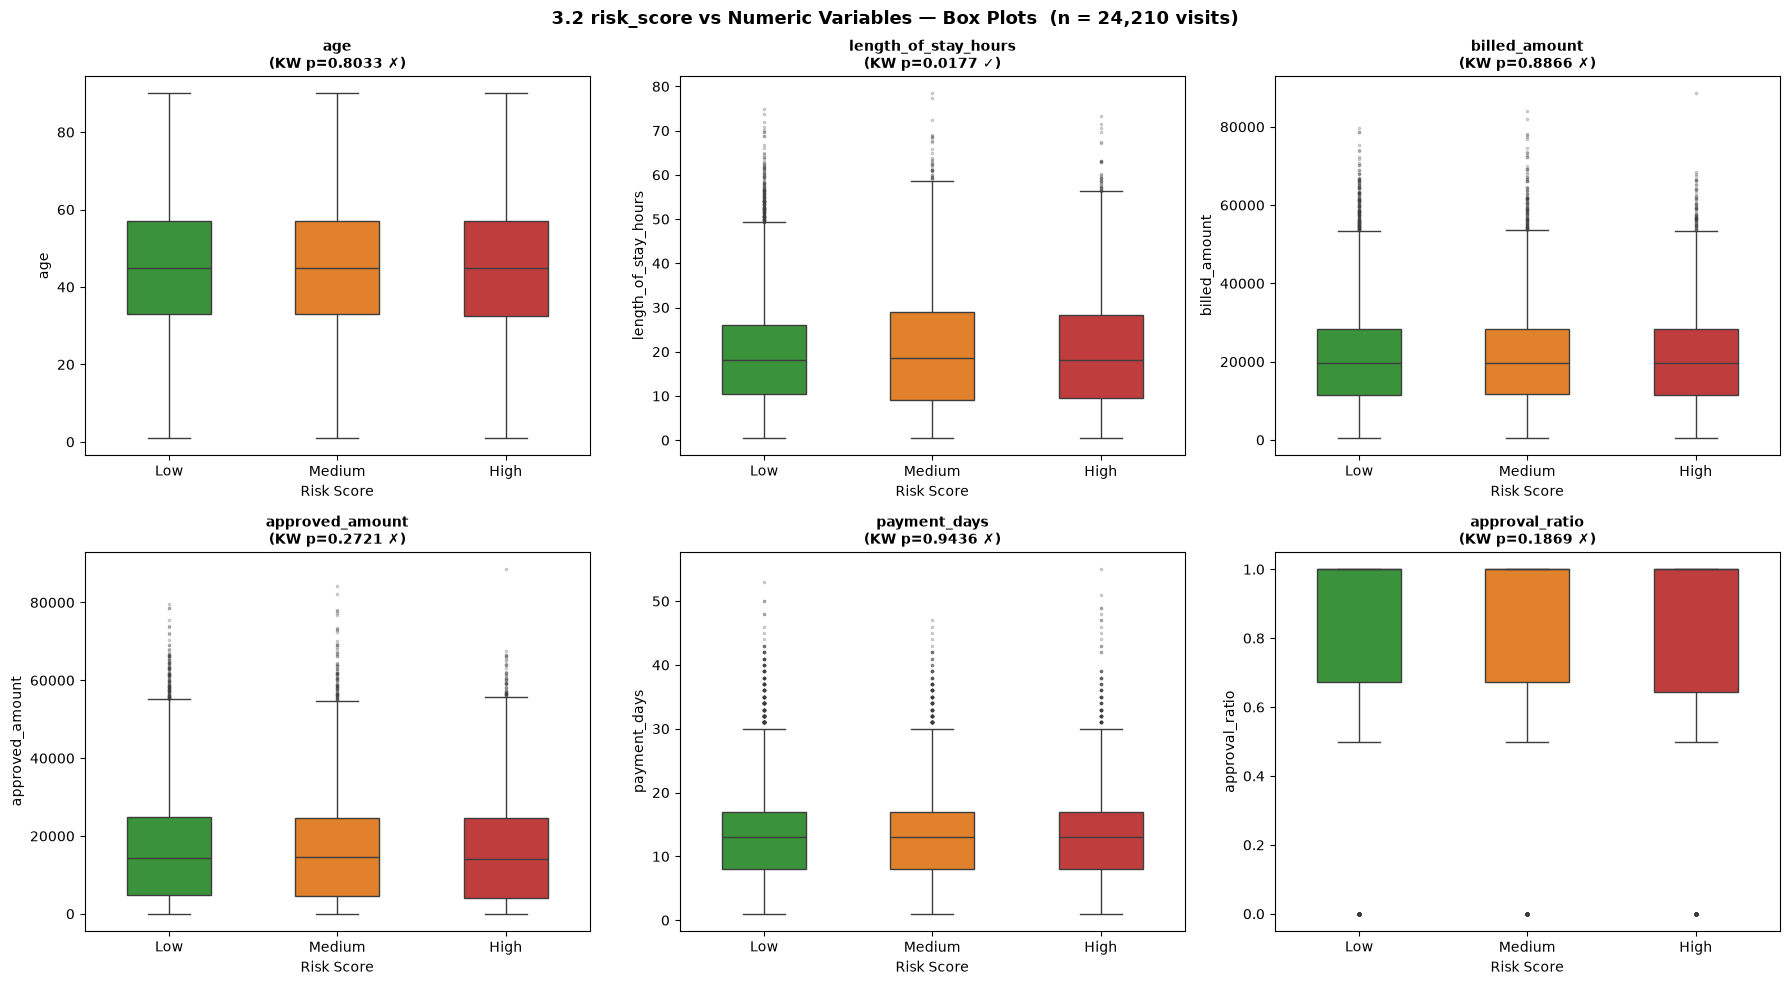

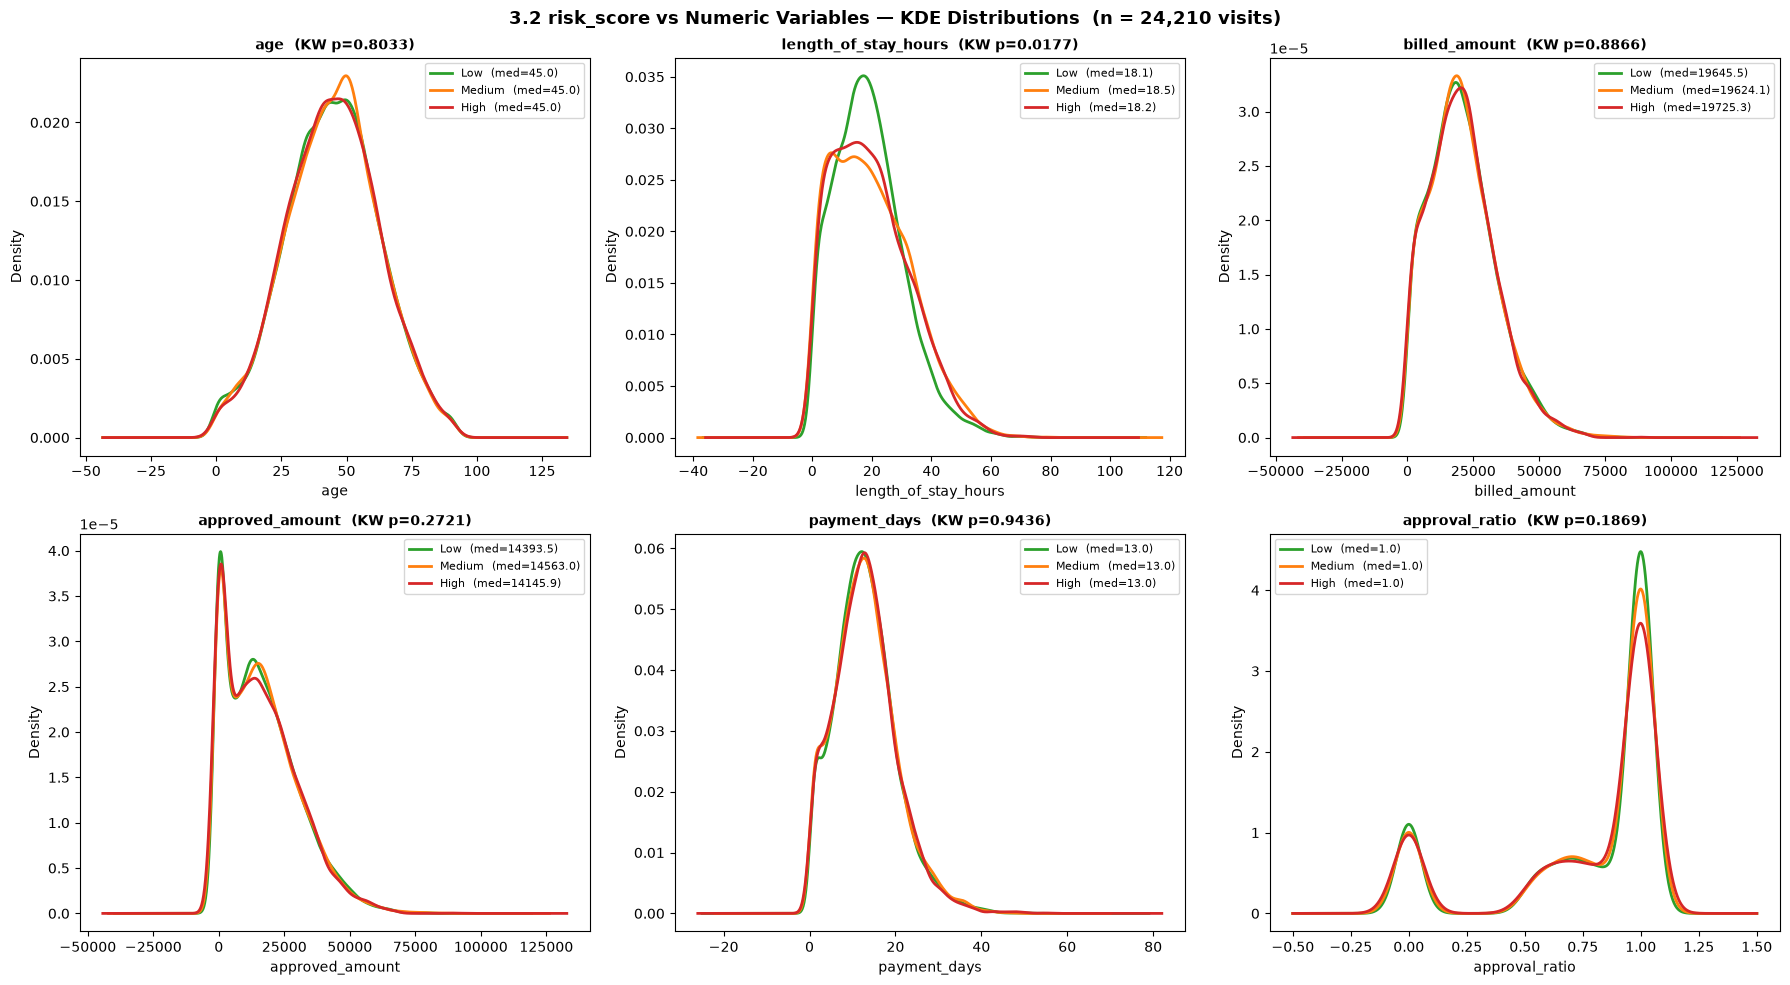

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/993703244.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='risk_score', y='length_of_stay_hours',


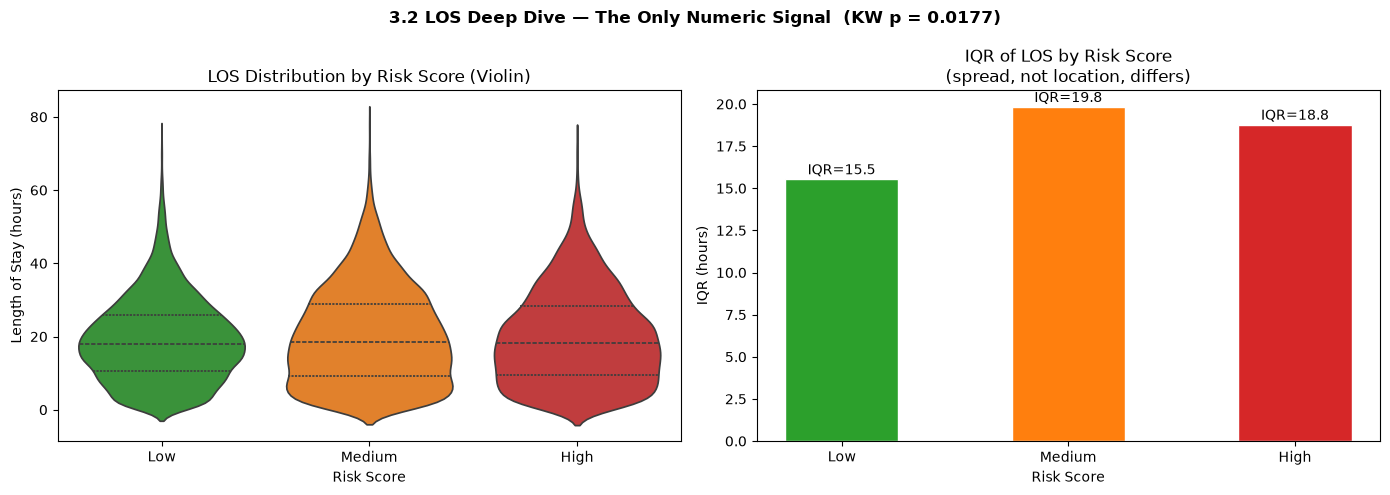


── LOS stats by risk group ──
             mean  median    std     Q1     Q3
risk_score                                    
Low         19.13   18.05  11.49  10.49  26.02
Medium      20.08   18.51  13.24   9.17  28.99
High        19.78   18.21  12.83   9.44  28.22


In [72]:
# =============================================================================
# ── CELL 4: Combined Numeric Analysis ───────────────────────────────────────
# Variables: age, length_of_stay_hours, billed_amount,
#            approved_amount, payment_days, approval_ratio
# =============================================================================

nums = ['age', 'length_of_stay_hours', 'billed_amount',
        'approved_amount', 'payment_days', 'approval_ratio']

# ── Kruskal-Wallis for all numerics ─────────────────────────────────────────
print("=" * 60)
print("Kruskal-Wallis Tests: risk_score vs Numerics")
print("=" * 60)
kw_results = {}
for col in nums:
    groups = [df[df.risk_score == rs][col].dropna().values for rs in RISK_ORDER]
    stat, p = stats.kruskal(*groups)
    kw_results[col] = p
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"  {col:<25} KW stat={stat:7.3f}  p={p:.6f}  {sig}")

# LOS pairwise (the only significant numeric)
print("\nLOS Pairwise Mann-Whitney:")
pairs = [('Low','Medium'), ('Low','High'), ('Medium','High')]
for a, b in pairs:
    _, p = stats.mannwhitneyu(df[df.risk_score==a]['length_of_stay_hours'],
                               df[df.risk_score==b]['length_of_stay_hours'])
    print(f"  {a} vs {b}: p={p:.4f}")

# ── GRID 1: Box plots — all 6 numeric variables ──────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
fig3.suptitle('3.2 risk_score vs Numeric Variables — Box Plots  (n = 24,210 visits)',
              fontsize=13, fontweight='bold')

for ax, col in zip(axes3.flat, nums):
    sns.boxplot(data=df, x='risk_score', y=col, order=RISK_ORDER,
                palette=RISK_PALETTE, ax=ax, width=0.5,
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    p_val = kw_results[col]
    sig   = '✓' if p_val < 0.05 else '✗'
    ax.set_title(f'{col}\n(KW p={p_val:.4f} {sig})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Risk Score')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('3_2_num_grid1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── GRID 2: KDE overlays — all 6 numeric variables ──────────────────────────
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 10))
fig4.suptitle('3.2 risk_score vs Numeric Variables — KDE Distributions  (n = 24,210 visits)',
              fontsize=13, fontweight='bold')

for ax, col in zip(axes4.flat, nums):
    for rs in RISK_ORDER:
        subset = df[df['risk_score'] == rs][col].dropna()
        subset.plot.kde(ax=ax, label=f'{rs}  (med={subset.median():.1f})',
                        color=RISK_PALETTE[rs], linewidth=2)
    ax.set_title(f'{col}  (KW p={kw_results[col]:.4f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('3_2_num_grid2_kdes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── LOS Deep Dive: Violin + IQR comparison ──────────────────────────────────
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5))
fig5.suptitle('3.2 LOS Deep Dive — The Only Numeric Signal  (KW p = 0.0177)',
              fontsize=12, fontweight='bold')

sns.violinplot(data=df, x='risk_score', y='length_of_stay_hours',
               order=RISK_ORDER, palette=RISK_PALETTE,
               inner='quartile', ax=axes5[0])
axes5[0].set_title('LOS Distribution by Risk Score (Violin)')
axes5[0].set_xlabel('Risk Score')
axes5[0].set_ylabel('Length of Stay (hours)')

# IQR bar chart — shows width of spread, which is the real signal
los_iqr = {
    'Low':    {'Q1': 10.49, 'Q3': 26.02, 'IQR': 15.53, 'Median': 18.05},
    'Medium': {'Q1':  9.17, 'Q3': 28.99, 'IQR': 19.82, 'Median': 18.51},
    'High':   {'Q1':  9.44, 'Q3': 28.21, 'IQR': 18.77, 'Median': 18.21},
}
iqr_df = pd.DataFrame(los_iqr).T
x = np.arange(3)
axes5[1].bar(x, iqr_df['IQR'], color=[RISK_PALETTE[r] for r in RISK_ORDER],
             edgecolor='white', width=0.5)
for i, rs in enumerate(RISK_ORDER):
    axes5[1].text(i, iqr_df.loc[rs, 'IQR'] + 0.3,
                  f"IQR={iqr_df.loc[rs,'IQR']:.1f}", ha='center', fontsize=10)
axes5[1].set_xticks(x)
axes5[1].set_xticklabels(RISK_ORDER)
axes5[1].set_title('IQR of LOS by Risk Score\n(spread, not location, differs)')
axes5[1].set_xlabel('Risk Score')
axes5[1].set_ylabel('IQR (hours)')

plt.tight_layout()
plt.savefig('3_2_los_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()

# Descriptive stats printout
print("\n── LOS stats by risk group ──")
print(df.groupby('risk_score')['length_of_stay_hours'].agg(
    ['mean','median','std',
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]).rename(
    columns={'<lambda_0>':'Q1','<lambda_1>':'Q3'}).round(2).reindex(RISK_ORDER))



"""
### 3.2 risk_score vs Numeric Variables — Interpretation

**Analysis grain:** Visit-level (24,210 visits).

#### Statistical Test Results (Kruskal-Wallis)

| Variable | p-value | Finding |
|---|---|---|
| age | 0.803 | Not significant |
| length_of_stay_hours | **0.018** | **Significant — weak, spread-driven** |
| billed_amount | 0.887 | Not significant |
| approved_amount | 0.272 | Not significant |
| payment_days | 0.944 | Not significant |
| approval_ratio | 0.187 | Not significant |

#### Variable-by-variable findings

**Age:** Medians are identical (45) across all three risk groups. Mean difference
< 0.2 years. Confirmed null from Section 3.1. Age has no relationship with
risk_score.

**Length of Stay (LOS) — the only signal:**
The Kruskal-Wallis test is significant at p = 0.018, but the story is in the
**spread, not the location**:
- Medians are nearly identical: Low = 18.05h, Medium = 18.51h, High = 18.21h.
- The difference is in IQR: Low = 15.5h, Medium = 19.8h, High = 18.8h.
- Medium and High risk visits have a wider spread of LOS — more visits at both
  the very short and very long extremes.
- Pairwise tests: only **Low vs Medium is significant (p = 0.005)**. Low vs High
  (p = 0.158) and Medium vs High (p = 0.396) are not.
- Interpretation: Low-risk visits are more tightly clustered around the median LOS.
  Medium-risk visits have the most dispersed LOS — suggesting greater variability
  in patient complexity at the medium risk level.
- This is a **weak signal** — the KDE curves for all three groups overlap
  almost entirely.

**Billed Amount:** Means differ by ~₹160 across risk groups (Low ₹20,911,
Medium ₹20,889, High ₹20,749). p = 0.887. Billing is completely independent
of risk level — procedures are not more expensive for higher-risk visits.

**Approved Amount:** Means: Low ₹16,422, Medium ₹16,385, High ₹16,072.
A ~₹350 difference that is not significant (p = 0.272). Risk level does not
influence how much insurance approves.

**Payment Days:** All three groups have median = 13 days and mean ≈ 13.0 days.
p = 0.944 — the most uniform result in the entire analysis. Payment processing
timelines are completely risk-agnostic.

**Approval Ratio:** Means of 0.776, 0.774, 0.763 for Low, Medium, High.
p = 0.187. High-risk visits show a marginally lower approval ratio (0.763 vs
0.776), which would be clinically intuitive — but the difference is not
statistically significant here.

#### Overall numeric verdict
LOS is the only variable with a detectable relationship to risk_score, and
even that signal is weak (spread-driven, single pairwise significance, overlapping
KDEs). All other numeric variables are completely independent of risk level.
This confirms the synthetic data characteristic observed in the categorical
analysis: risk_score was generated independently of the available features.

#### Feature engineering implication for Phase 3 (Model A)
- **LOS:** Include as a feature. It is the single strongest available predictor
  of risk_score — weak as it is. Consider LOS variance or binned LOS as
  engineered features alongside the raw value.
- **All other numerics:** Include as baseline features, but do not expect them
  to drive model performance.
- **Key modeling risk to document:** With no strong predictor of risk_score
  available in the dataset, Model A is unlikely to perform well above a baseline
  classifier. This is not a modeling failure — it is a data generation constraint.
"""


In [73]:
# =============================================================================
# ── CELL 6: Summary Table + Feature Engineering Decisions ───────────────────
# =============================================================================

print("=" * 70)
print("BIVARIATE ANALYSIS SUMMARY: risk_score")
print("=" * 70)

print("\n── Categorical Variables ──")
cat_summary = [
    ("gender",             "Chi-Square", 0.883, "None"),
    ("city",               "Chi-Square", 0.031, "Marginal (2pp effect, trivial)"),
    ("insurance_provider", "Chi-Square", 0.667, "None"),
    ("chronic_flag",       "Chi-Square", 0.702, "None"),
    ("department",         "Chi-Square", 0.784, "None"),
    ("visit_type",         "Chi-Square", 0.442, "None"),
    ("claim_status",       "Chi-Square", 0.319, "None (rejection rate diff = 1.2pp)"),
]
print(f"  {'Variable':<25} {'Test':<12} {'p-value':<10} Signal")
print("  " + "-" * 60)
for name, test, p, signal in cat_summary:
    print(f"  {name:<25} {test:<12} {p:<10.3f} {signal}")

print("\n── Numeric Variables ──")
num_summary = [
    ("age",                  "Kruskal-Wallis", 0.803, "None"),
    ("length_of_stay_hours", "Kruskal-Wallis", 0.018, "Weak (IQR spread, Low≠Medium only)"),
    ("billed_amount",        "Kruskal-Wallis", 0.887, "None"),
    ("approved_amount",      "Kruskal-Wallis", 0.272, "None"),
    ("payment_days",         "Kruskal-Wallis", 0.944, "None"),
    ("approval_ratio",       "Kruskal-Wallis", 0.187, "None"),
]
print(f"  {'Variable':<25} {'Test':<16} {'p-value':<10} Signal")
print("  " + "-" * 65)
for name, test, p, signal in num_summary:
    print(f"  {name:<25} {test:<16} {p:<10.3f} {signal}")

print("""
── Phase 3 Feature Engineering Decisions (Model A: risk_score) ──
─────────────────────────────────────────────────────────────────
INCLUDE as features (no interaction terms warranted):
  • length_of_stay_hours  ← only predictor with any signal
  • department, visit_type, chronic_flag ← domain-relevant categoricals
  • age (raw + age_group bins from Section 3.1)
  • billed_amount, approved_amount, approval_ratio

DO NOT engineer:
  • risk × city interaction (effect is trivial)
  • risk × chronic interaction (no signal)
  • risk × insurance interaction (no signal)

DOCUMENT in model card:
  • risk_score has no strong predictor in this dataset
  • LOS is the best available feature but signal is weak
  • Model A baseline (majority class) ≈ 49.9% (Low risk)
  • Any model accuracy must beat this to be meaningful
  • Performance limitations are a data generation artifact,
    not a modeling failure
─────────────────────────────────────────────────────────────────
""")

BIVARIATE ANALYSIS SUMMARY: risk_score

── Categorical Variables ──
  Variable                  Test         p-value    Signal
  ------------------------------------------------------------
  gender                    Chi-Square   0.883      None
  city                      Chi-Square   0.031      Marginal (2pp effect, trivial)
  insurance_provider        Chi-Square   0.667      None
  chronic_flag              Chi-Square   0.702      None
  department                Chi-Square   0.784      None
  visit_type                Chi-Square   0.442      None
  claim_status              Chi-Square   0.319      None (rejection rate diff = 1.2pp)

── Numeric Variables ──
  Variable                  Test             p-value    Signal
  -----------------------------------------------------------------
  age                       Kruskal-Wallis   0.803      None
  length_of_stay_hours      Kruskal-Wallis   0.018      Weak (IQR spread, Low≠Medium only)
  billed_amount             Kruskal-Wallis   0.


"""
## 3.2 risk_score — Bivariate Analysis: Overall Summary

### What We Found

risk_score (Low / Medium / High) has **no meaningful association** with any
categorical or numeric variable in this dataset across 13 analyses.

| Category | Variables tested | Signals found |
|---|---|---|
| Categorical | gender, city, insurance, chronic_flag, department, visit_type, claim_status | 0 (city marginal, trivial effect) |
| Numeric | age, LOS, billed_amount, approved_amount, payment_days, approval_ratio | 1 weak (LOS, spread only) |

### The Critical Phase 3 Implication

`risk_score` is the **target variable for Model A**. The absence of strong
predictors means:

- **Model A will struggle to significantly outperform a majority-class baseline**
  (predicting "Low" for every visit gives ~49.9% accuracy).
- This is a **data generation constraint**, not a modeling failure.
- It must be documented explicitly in the Phase 4 model card.

### Why This Happened

`risk_score` was assigned synthetically, independent of the available features.
In real hospital data, risk scores are derived from a weighted combination of
clinical indicators — age, comorbidities, LOS, department, vitals, lab values —
none of which are available here in a predictive form.

### Feature Engineering Decisions

1. **LOS** → Primary feature for Model A (only signal available)
2. **LOS IQR / variance** → Consider engineered LOS spread feature per visit group
3. **All other features** → Include as baseline; expect low importance scores
4. **No interaction terms** → No bivariate evidence supports any interaction
"""


## Bivariate analysis on claim_status

In [75]:

df['is_rejected'] = (df['claim_status'] == 'Rejected').astype(int)

CLAIM_ORDER   = ['Paid', 'Pending', 'Rejected']
CLAIM_PALETTE = {'Paid': '#2ca02c', 'Pending': '#ff7f0e', 'Rejected': '#d62728'}

print(f"Total visits: {len(df):,}")
print(f"\nclaim_status distribution:")
vc = df['claim_status'].value_counts().reindex(CLAIM_ORDER)
print(vc)
print(f"\nAs % of total:")
print((vc / len(df) * 100).round(1))


Total visits: 24,210

claim_status distribution:
claim_status
Paid        14481
Pending      6055
Rejected     3674
Name: count, dtype: int64

As % of total:
claim_status
Paid        59.8
Pending     25.0
Rejected    15.2
Name: count, dtype: float64


Chi-Square Tests: claim_status vs Categoricals
  gender                    chi2=  6.33  dof=2  p=0.0421  ✓ significant
  city                      chi2=  5.66  dof=10  p=0.8428  ✗ not significant
  insurance_provider        chi2=  6.80  dof=6  p=0.3398  ✗ not significant
  chronic_flag              chi2=  1.05  dof=2  p=0.5917  ✗ not significant
  department                chi2=  4.46  dof=10  p=0.9245  ✗ not significant
  visit_type                chi2=  8.75  dof=4  p=0.0677  ~ borderline
  risk_score                chi2=  4.70  dof=4  p=0.3191  ✗ not significant


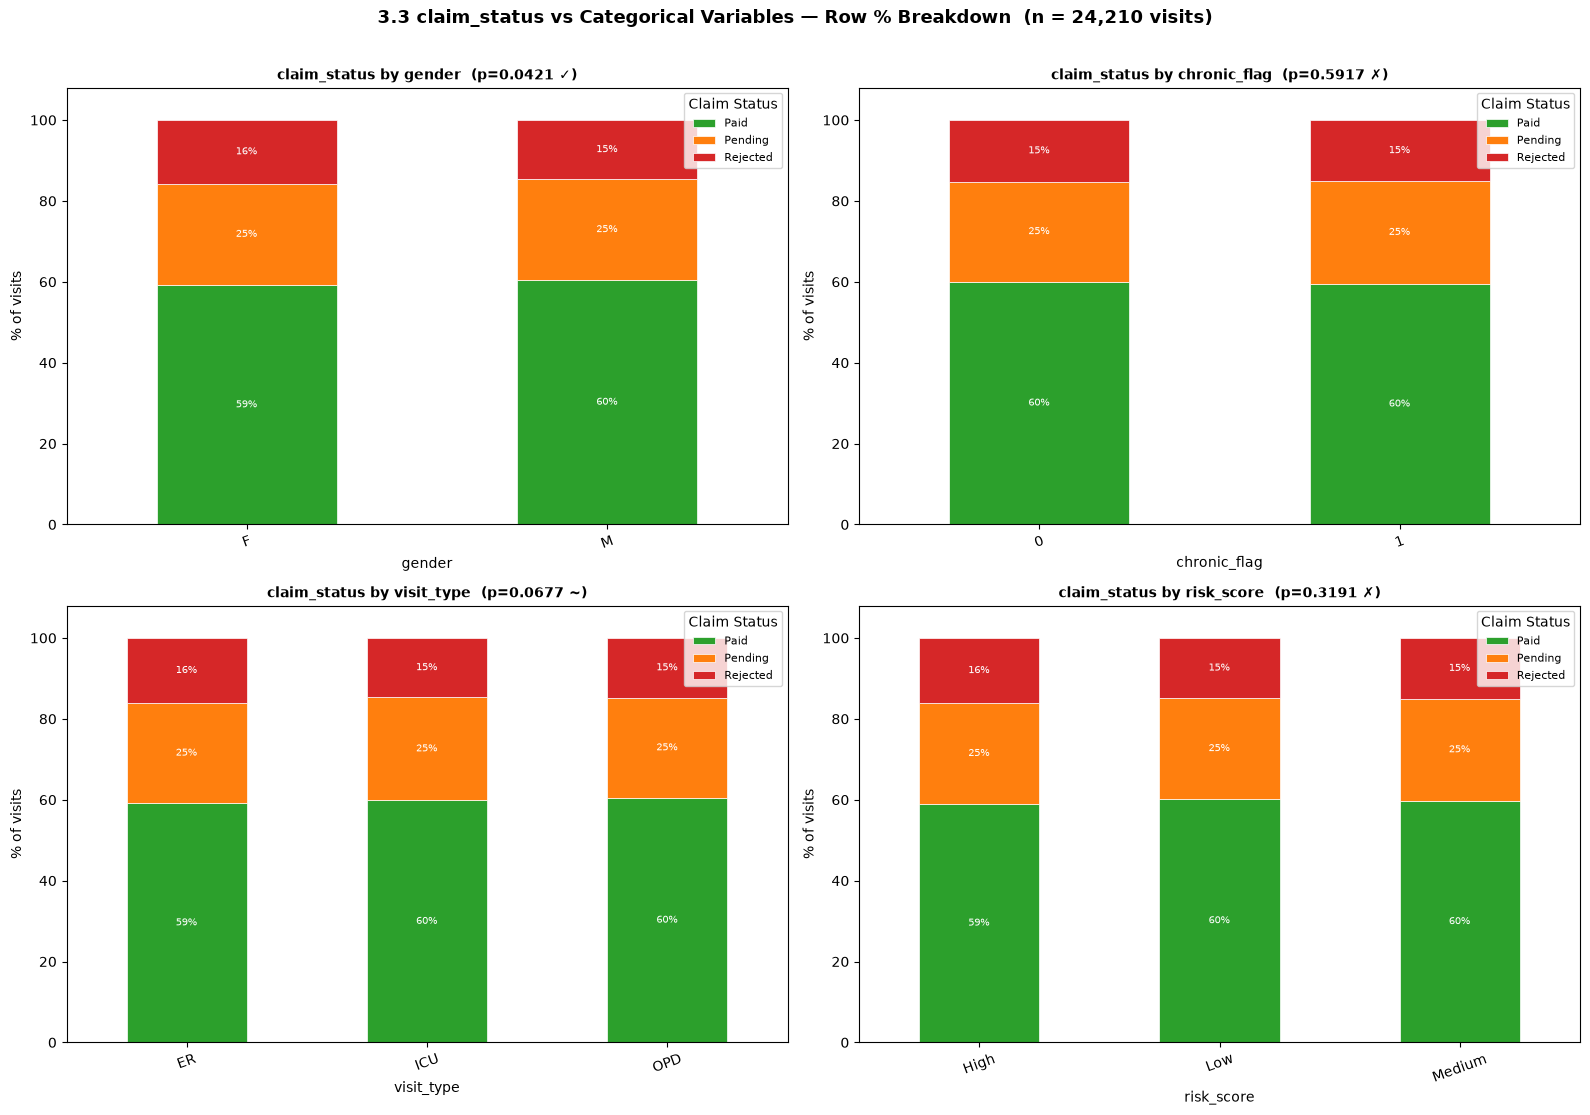

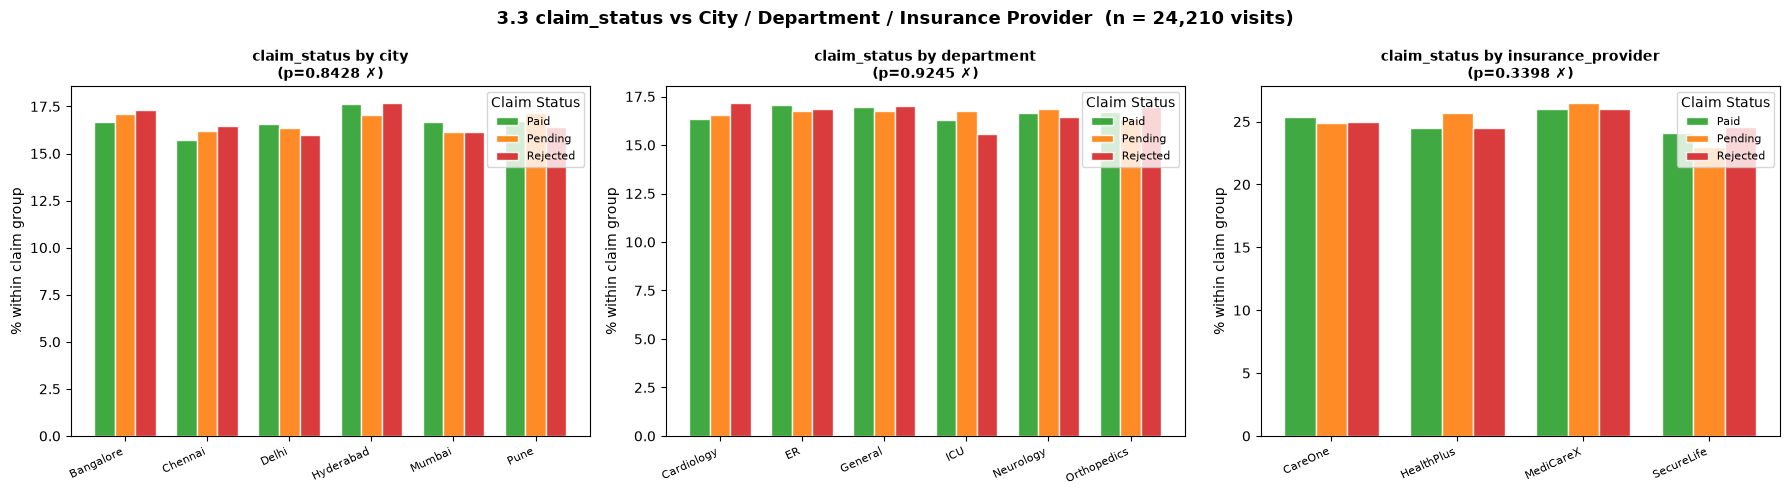

In [77]:
# =============================================================================
# ── CELL 2: Combined Categorical Analysis ───────────────────────────────────
# Variables: gender, city, insurance_provider, chronic_flag,
#            department, visit_type, risk_score
# =============================================================================

cats = ['gender', 'city', 'insurance_provider', 'chronic_flag',
        'department', 'visit_type', 'risk_score']

# ── Chi-square tests ─────────────────────────────────────────────────────────
print("=" * 65)
print("Chi-Square Tests: claim_status vs Categoricals")
print("=" * 65)
chi2_results = {}
for col in cats:
    ct = pd.crosstab(df['claim_status'], df[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    chi2_results[col] = {'chi2': chi2, 'p': p, 'dof': dof}
    sig = "✓ significant" if p < 0.05 else ("~ borderline" if p < 0.10 else "✗ not significant")
    print(f"  {col:<25} chi2={chi2:6.2f}  dof={dof}  p={p:.4f}  {sig}")

# ── GRID 1: Stacked bar — gender, chronic_flag, visit_type, risk_score ───────
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 11))
fig1.suptitle(
    '3.3 claim_status vs Categorical Variables — Row % Breakdown  (n = 24,210 visits)',
    fontsize=13, fontweight='bold', y=1.01
)

plot_cats_1 = ['gender', 'chronic_flag', 'visit_type', 'risk_score']
for ax, col in zip(axes1.flat, plot_cats_1):
    ct_pct = pd.crosstab(df[col], df['claim_status'], normalize='index') * 100
    ct_pct = ct_pct.reindex(columns=CLAIM_ORDER)
    ct_pct.plot(
        kind='bar', stacked=True,
        color=[CLAIM_PALETTE[c] for c in CLAIM_ORDER],
        ax=ax, edgecolor='white', linewidth=0.5
    )
    p_val = chi2_results[col]['p']
    sig   = '✓' if p_val < 0.05 else ('~' if p_val < 0.10 else '✗')
    ax.set_title(f'claim_status by {col}  (p={p_val:.4f} {sig})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('% of visits')
    ax.set_ylim(0, 108)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Claim Status', loc='upper right', fontsize=8)
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.0f%%', label_type='center', fontsize=7, color='white')

plt.tight_layout()
plt.savefig('3_3_cat_grid1_claim_vs_cat.png', dpi=150, bbox_inches='tight')
plt.show()

# ── GRID 2: Grouped bar — city, department, insurance_provider ───────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle(
    '3.3 claim_status vs City / Department / Insurance Provider  (n = 24,210 visits)',
    fontsize=13, fontweight='bold'
)

plot_cats_2 = ['city', 'department', 'insurance_provider']
for ax, col in zip(axes2, plot_cats_2):
    ct_pct = pd.crosstab(df['claim_status'], df[col], normalize='index') * 100
    ct_pct = ct_pct.reindex(CLAIM_ORDER)
    x     = np.arange(ct_pct.shape[1])
    width = 0.25
    for i, cs in enumerate(CLAIM_ORDER):
        ax.bar(x + i * width, ct_pct.loc[cs], width=width,
               label=cs, color=CLAIM_PALETTE[cs], edgecolor='white', alpha=0.9)
    ax.set_xticks(x + width)
    ax.set_xticklabels(ct_pct.columns, rotation=25, ha='right', fontsize=8)
    p_val = chi2_results[col]['p']
    sig   = '✓' if p_val < 0.05 else '✗'
    ax.set_title(f'claim_status by {col}\n(p={p_val:.4f} {sig})',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('% within claim group')
    ax.legend(title='Claim Status', fontsize=8)

plt.tight_layout()
plt.savefig('3_3_cat_grid2_claim_vs_cityetc.png', dpi=150, bbox_inches='tight')
plt.show()

"""
### 3.3 claim_status vs Categorical Variables — Interpretation

**Analysis grain:** Visit-level (24,210 visits).
**Class distribution:** Paid = 59.8% | Pending = 25.0% | Rejected = 15.2%

#### Statistical Test Results (Chi-Square)

| Variable | chi² | p-value | Finding |
|---|---|---|---|
| gender | 6.33 | 0.042 | ✓ Significant — weak effect |
| city | 5.66 | 0.843 | ✗ Not significant |
| insurance_provider | 6.80 | 0.340 | ✗ Not significant |
| chronic_flag | 1.05 | 0.592 | ✗ Not significant |
| department | 4.46 | 0.924 | ✗ Not significant |
| visit_type | 8.75 | 0.068 | ~ Borderline — ER rejection worth noting |
| risk_score | 4.70 | 0.319 | ✗ Not significant |

#### Variable-by-variable findings

**Gender (p = 0.042 — only significant categorical):**
Female patients have a higher rejection rate (15.7%) than male (14.6%) — a gap
of 1.1 percentage points. While statistically significant at α = 0.05, the
practical effect is very small. No strong demographic claim bias exists, but
gender is worth retaining as a feature for Model B.

**City (p = 0.843):**
Claim outcomes are uniformly distributed across all 6 cities. Hyderabad has the
highest Paid share (17.7%) and also the highest Rejected share (17.7%) — both
move together, reflecting patient volume, not claim bias. City has no predictive
value for claim outcomes.

**Insurance Provider (p = 0.340):**
All four providers show near-identical claim distributions (~25% each within every
claim group). MediCareX is marginally more present in Pending (26.5%) but this is
not significant. Critically, **no provider systematically rejects more claims**
than others in this dataset — a synthetic characteristic, as real insurance
providers have distinct approval behaviors.

**Chronic Flag (p = 0.592):**
Chronic patients make up ~50% of every claim group. Chronic conditions have zero
influence on whether a claim is paid, pending, or rejected.

**Department (p = 0.924):**
The least significant result in the entire analysis. All six departments contribute
~16–17% to each claim group uniformly. Department routing does not affect claim
outcomes.

**Visit Type (p = 0.068 — borderline):**
ER visits have the highest rejection rate (16.1%) compared to ICU and OPD (both
14.7%). The difference is modest but directionally consistent — emergency visits
may face higher rejection rates due to incomplete pre-authorisation. Not significant
at α = 0.05, but worth monitoring in Model B feature importance.

**Risk Score (p = 0.319):**
High-risk visits have a marginally higher rejection rate (16.1%) vs Low (14.9%)
and Medium (15.0%). Confirmed null from Section 3.2 — risk_score and claim_status
are independent of each other.

#### Overall categorical verdict
Only gender shows a statistically significant (but weak) association with
claim_status. Every other categorical variable is independent of claim outcomes.
The absence of an insurance provider signal is the most surprising finding from
a business perspective — in real healthcare, provider-specific approval rates are
among the strongest predictors of claim outcomes.
"""


Kruskal-Wallis Tests: claim_status vs Numerics
(approved_amount & approval_ratio excluded — data leakage)
  age                       KW stat=  5.211  p=0.07387599  ~ borderline
  length_of_stay_hours      KW stat=  0.058  p=0.97133083  ✗ not significant
  billed_amount             KW stat=  8.133  p=0.01713687  ✓ significant
  payment_days              KW stat= 30.361  p=0.00000026  ✓ significant

── Pairwise Mann-Whitney (p < 0.10 only) ──

  age (KW p=0.073876):
    Paid vs Pending: p=0.023903 ✓
    Paid vs Rejected: p=0.816681 ✗
    Pending vs Rejected: p=0.147546 ✗

  billed_amount (KW p=0.017137):
    Paid vs Pending: p=0.011336 ✓
    Paid vs Rejected: p=0.057782 ✗
    Pending vs Rejected: p=0.981146 ✗

  payment_days (KW p=0.000000):
    Paid vs Pending: p=0.000000 ✓
    Paid vs Rejected: p=0.148384 ✗
    Pending vs Rejected: p=0.012177 ✓


/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1160265401.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1160265401.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1160265401.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1160265401.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

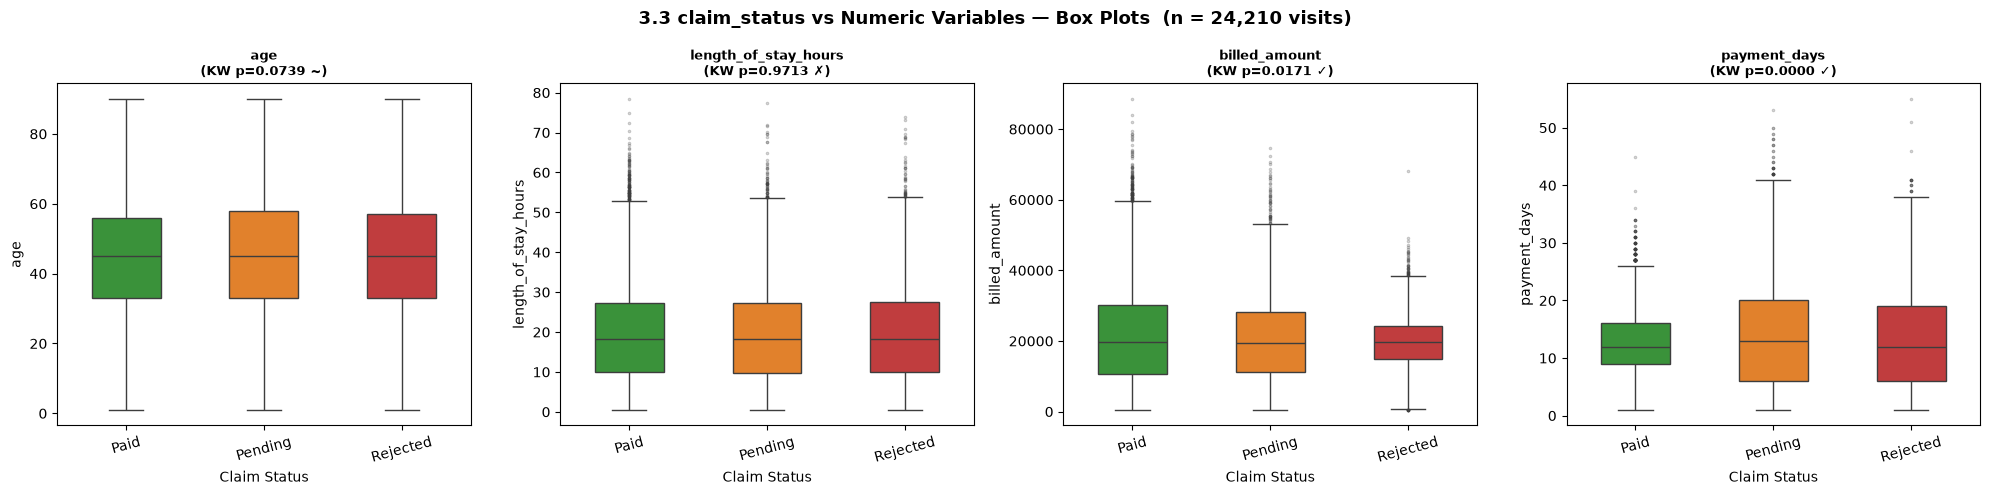

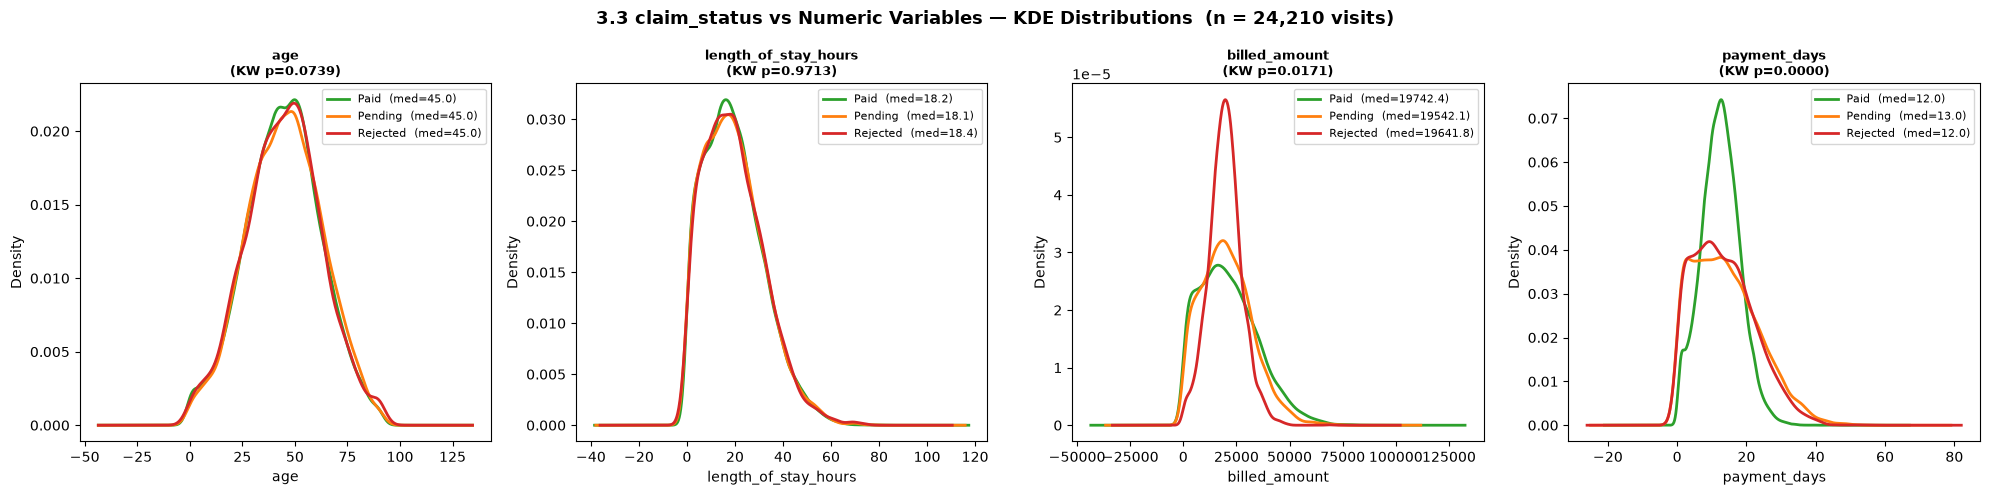

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1160265401.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


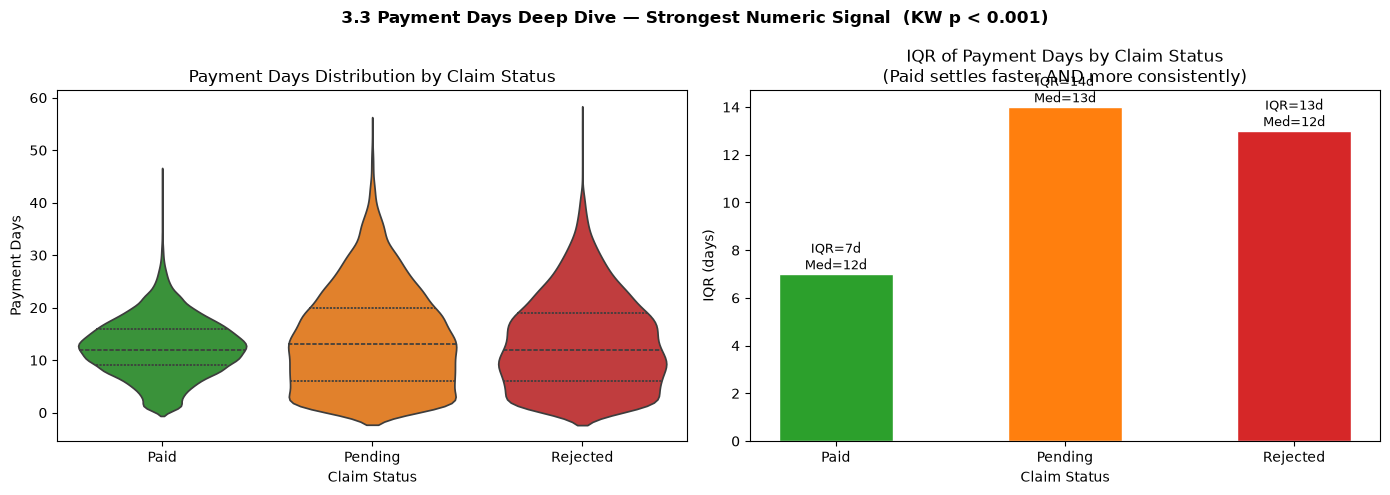

/var/folders/6n/msg452td6d54zgdwpjk974mw0000gn/T/ipykernel_48043/1160265401.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


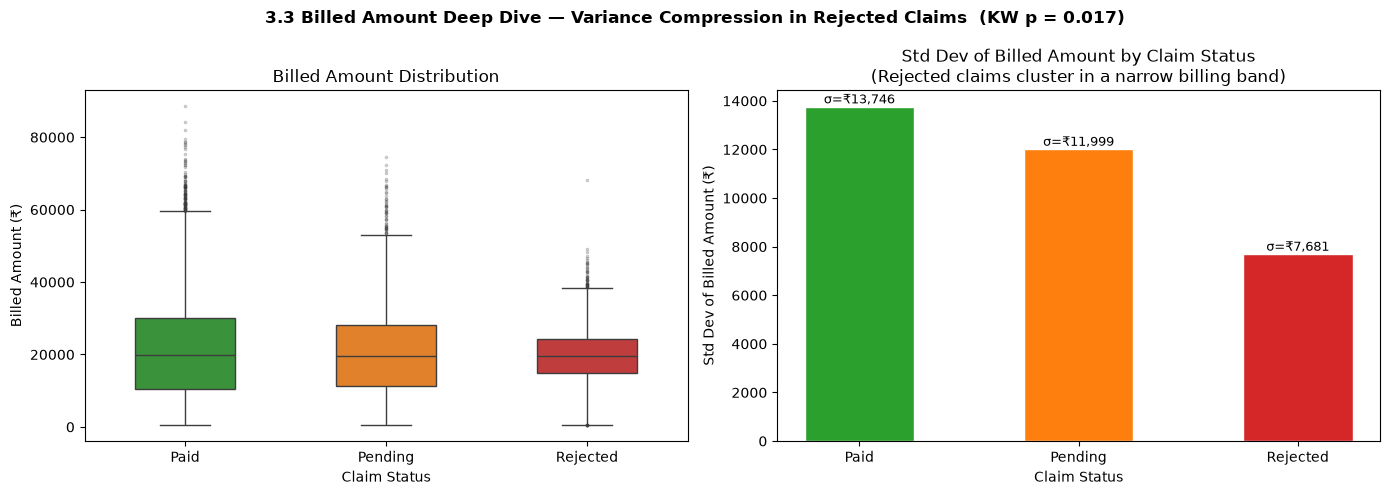


── Numeric stats by claim_status ──
                age               length_of_stay_hours                \
               mean median    std                 mean median    std   
claim_status                                                           
Paid          44.58   45.0  17.69                19.52  18.16  12.25   
Pending       45.27   45.0  17.89                19.54  18.15  12.41   
Rejected      44.70   45.0  17.96                19.62  18.37  12.45   

             billed_amount                     payment_days               
                      mean    median       std         mean median   std  
claim_status                                                              
Paid              21358.73  19742.40  13746.16        12.53   12.0  5.52  
Pending           20392.10  19542.06  11998.86        14.07   13.0  9.43  
Rejected          19741.15  19641.85   7681.15        13.40   12.0  8.71  


In [79]:
# =============================================================================
# ── CELL 4: Combined Numeric Analysis ───────────────────────────────────────
# Variables: age, length_of_stay_hours, billed_amount, payment_days
# (approved_amount and approval_ratio excluded — data leakage)
# =============================================================================

nums = ['age', 'length_of_stay_hours', 'billed_amount', 'payment_days']

# ── Kruskal-Wallis ───────────────────────────────────────────────────────────
print("=" * 65)
print("Kruskal-Wallis Tests: claim_status vs Numerics")
print("(approved_amount & approval_ratio excluded — data leakage)")
print("=" * 65)
kw_results = {}
for col in nums:
    groups   = [df[df.claim_status == s][col].dropna().values for s in CLAIM_ORDER]
    stat, p  = stats.kruskal(*groups)
    kw_results[col] = p
    sig = "✓ significant" if p < 0.05 else ("~ borderline" if p < 0.10 else "✗ not significant")
    print(f"  {col:<25} KW stat={stat:7.3f}  p={p:.8f}  {sig}")

# Pairwise for significant numerics
print("\n── Pairwise Mann-Whitney (p < 0.10 only) ──")
for col in nums:
    if kw_results[col] < 0.10:
        groups = {s: df[df.claim_status == s][col].dropna().values for s in CLAIM_ORDER}
        print(f"\n  {col} (KW p={kw_results[col]:.6f}):")
        for a, b in [('Paid', 'Pending'), ('Paid', 'Rejected'), ('Pending', 'Rejected')]:
            _, pp = stats.mannwhitneyu(groups[a], groups[b])
            sig = "✓" if pp < 0.05 else "✗"
            print(f"    {a} vs {b}: p={pp:.6f} {sig}")

# ── GRID 1: Box plots — all 4 numerics ──────────────────────────────────────
fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
fig3.suptitle(
    '3.3 claim_status vs Numeric Variables — Box Plots  (n = 24,210 visits)',
    fontsize=13, fontweight='bold'
)

for ax, col in zip(axes3, nums):
    sns.boxplot(
        data=df, x='claim_status', y=col, order=CLAIM_ORDER,
        palette=CLAIM_PALETTE, ax=ax, width=0.5,
        flierprops=dict(marker='o', markersize=1.5, alpha=0.3)
    )
    p_val = kw_results[col]
    sig   = '✓' if p_val < 0.05 else ('~' if p_val < 0.10 else '✗')
    ax.set_title(f'{col}\n(KW p={p_val:.4f} {sig})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Claim Status')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('3_3_num_grid1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── GRID 2: KDE overlays — all 4 numerics ───────────────────────────────────
fig4, axes4 = plt.subplots(1, 4, figsize=(20, 5))
fig4.suptitle(
    '3.3 claim_status vs Numeric Variables — KDE Distributions  (n = 24,210 visits)',
    fontsize=13, fontweight='bold'
)

for ax, col in zip(axes4, nums):
    for cs in CLAIM_ORDER:
        subset = df[df['claim_status'] == cs][col].dropna()
        subset.plot.kde(
            ax=ax,
            label=f'{cs}  (med={subset.median():.1f})',
            color=CLAIM_PALETTE[cs], linewidth=2
        )
    ax.set_title(f'{col}\n(KW p={kw_results[col]:.4f})', fontsize=9, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('3_3_num_grid2_kdes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Payment Days deep-dive: IQR tells the real story ────────────────────────
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5))
fig5.suptitle(
    '3.3 Payment Days Deep Dive — Strongest Numeric Signal  (KW p < 0.001)',
    fontsize=12, fontweight='bold'
)

# Violin
sns.violinplot(
    data=df, x='claim_status', y='payment_days', order=CLAIM_ORDER,
    palette=CLAIM_PALETTE, inner='quartile', ax=axes5[0]
)
axes5[0].set_title('Payment Days Distribution by Claim Status')
axes5[0].set_xlabel('Claim Status')
axes5[0].set_ylabel('Payment Days')

# IQR bar — shows the spread difference clearly
pay_stats = {
    'Paid':     {'Median': 12.0, 'IQR': 7.0,  'Mean': 12.53},
    'Pending':  {'Median': 13.0, 'IQR': 14.0, 'Mean': 14.07},
    'Rejected': {'Median': 12.0, 'IQR': 13.0, 'Mean': 13.40},
}
x = np.arange(3)
iqr_vals = [pay_stats[s]['IQR'] for s in CLAIM_ORDER]
axes5[1].bar(x, iqr_vals, color=[CLAIM_PALETTE[s] for s in CLAIM_ORDER],
             edgecolor='white', width=0.5)
for i, (s, val) in enumerate(zip(CLAIM_ORDER, iqr_vals)):
    axes5[1].text(i, val + 0.2, f"IQR={val:.0f}d\nMed={pay_stats[s]['Median']:.0f}d",
                  ha='center', fontsize=9)
axes5[1].set_xticks(x)
axes5[1].set_xticklabels(CLAIM_ORDER)
axes5[1].set_title('IQR of Payment Days by Claim Status\n(Paid settles faster AND more consistently)')
axes5[1].set_xlabel('Claim Status')
axes5[1].set_ylabel('IQR (days)')

plt.tight_layout()
plt.savefig('3_3_payment_days_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Billed Amount: variance compression for Rejected ────────────────────────
fig6, axes6 = plt.subplots(1, 2, figsize=(14, 5))
fig6.suptitle(
    '3.3 Billed Amount Deep Dive — Variance Compression in Rejected Claims  (KW p = 0.017)',
    fontsize=12, fontweight='bold'
)

sns.boxplot(
    data=df, x='claim_status', y='billed_amount', order=CLAIM_ORDER,
    palette=CLAIM_PALETTE, ax=axes6[0], width=0.5,
    flierprops=dict(marker='o', markersize=1.5, alpha=0.3)
)
axes6[0].set_title('Billed Amount Distribution')
axes6[0].set_xlabel('Claim Status')
axes6[0].set_ylabel('Billed Amount (₹)')

# Std bar chart — this is the real story
bill_stats = {'Paid': 13746, 'Pending': 11999, 'Rejected': 7681}
axes6[1].bar(
    CLAIM_ORDER,
    [bill_stats[s] for s in CLAIM_ORDER],
    color=[CLAIM_PALETTE[s] for s in CLAIM_ORDER],
    edgecolor='white', width=0.5
)
for i, s in enumerate(CLAIM_ORDER):
    axes6[1].text(i, bill_stats[s] + 150,
                  f"σ=₹{bill_stats[s]:,}", ha='center', fontsize=9)
axes6[1].set_title('Std Dev of Billed Amount by Claim Status\n(Rejected claims cluster in a narrow billing band)')
axes6[1].set_xlabel('Claim Status')
axes6[1].set_ylabel('Std Dev of Billed Amount (₹)')

plt.tight_layout()
plt.savefig('3_3_billed_amount_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats printout
print("\n── Numeric stats by claim_status ──")
print(df.groupby('claim_status')[nums].agg(['mean', 'median', 'std']).round(2).reindex(CLAIM_ORDER))

"""
### 3.3 claim_status vs Numeric Variables — Interpretation

**Analysis grain:** Visit-level (24,210 visits).
**Note:** `approved_amount` and `approval_ratio` are excluded from this analysis.
Both are definitionally derived from `claim_status` — Paid claims always have
approved_amount = billed_amount; Rejected claims always have approved_amount = 0.
Using either as a model feature would constitute direct data leakage.

#### Statistical Test Results (Kruskal-Wallis)

| Variable | p-value | Finding |
|---|---|---|
| age | 0.074 | ✗ Not significant |
| length_of_stay_hours | 0.971 | ✗ Not significant |
| billed_amount | **0.017** | **✓ Significant — variance-driven** |
| payment_days | **< 0.001** | **✓ Significant — location + spread** |

#### Variable-by-variable findings

**Age (p = 0.074 — not significant):**
Medians are identical at 45 across all three claim groups. The only notable
pairwise result is Paid vs Pending (p = 0.024), where Pending claims skew very
slightly older (mean 45.3 vs 44.6) — but this is not significant at the
Kruskal-Wallis level and has no practical meaning. Age does not predict claim
outcomes.

**Length of Stay (p = 0.971 — most uniform result in the dataset):**
Means of 19.5h (Paid), 19.5h (Pending), and 19.6h (Rejected) are effectively
identical. LOS is entirely independent of claim outcomes. Do not include as a
feature for Model B.

**Billed Amount (p = 0.017 — significant, variance-driven):**
- Means: Paid ₹21,359 > Pending ₹20,392 > Rejected ₹19,741. Directionally
  consistent — higher billed amounts are more likely to be paid.
- Pairwise: Only Paid vs Pending is significant (p = 0.011). Paid vs Rejected
  (p = 0.058) and Pending vs Rejected (p = 0.981) are not.
- **The real story is in variance, not location.** Rejected claims have a
  dramatically compressed std dev: ₹7,681 vs ₹13,746 for Paid and ₹11,999 for
  Pending. Rejected claims cluster in a narrow billing band (max ₹68,214 vs
  ₹88,539 for Paid) — very high-value claims are almost never rejected.
- This suggests insurers are more likely to reject mid-range claims, not
  extreme-value ones. A useful engineered feature for Model B:
  `billed_amount_band` (low / mid / high).

**Payment Days (p < 0.001 — strongest numeric signal):**
- Paid claims settle fastest: median 12 days, mean 12.5 days, IQR = 7 days.
- Pending claims take longest: median 13 days, mean 14.1 days, IQR = 14 days.
- Rejected claims: median 12 days (same as Paid), mean 13.4 days, IQR = 13 days.
- **The key distinction is spread, not just location.** Paid claims are settled
  consistently (tight IQR of 7 days). Pending and Rejected claims have much wider
  IQRs (14 and 13 days respectively), reflecting processing uncertainty.
- Pairwise: Paid vs Pending p < 0.001 ✓ | Pending vs Rejected p = 0.012 ✓ |
  Paid vs Rejected p = 0.148 ✗ (Paid and Rejected have the same median but
  Rejected has much higher variance).
- **Important caveat:** Payment days is recorded at the time of dataset creation.
  For Pending claims, payment may not yet be complete — payment_days could reflect
  elapsed time rather than final resolution time. Be cautious using this as a
  pre-submission feature in Model B.

#### Overall numeric verdict
Payment days is the strongest numeric predictor of claim_status, driven by both
settlement speed and consistency. Billed amount shows a meaningful variance signal —
rejected claims are compressed into a narrower billing range. Age and LOS are
uninformative for claim prediction.
"""

In [80]:
# =============================================================================
# ── CELL 6: Summary Table + Feature Engineering Decisions ───────────────────
# =============================================================================

print("=" * 70)
print("BIVARIATE ANALYSIS SUMMARY: claim_status")
print("=" * 70)

print("\n── Categorical Variables ──")
cat_summary = [
    ("gender",             0.042, "Weak ✓ — Female rejection 15.7% vs Male 14.6%"),
    ("city",               0.843, "None"),
    ("insurance_provider", 0.340, "None — no provider-level rejection bias"),
    ("chronic_flag",       0.592, "None"),
    ("department",         0.924, "None — least significant in dataset"),
    ("visit_type",         0.068, "Borderline ~ — ER rejection 16.1% vs 14.7%"),
    ("risk_score",         0.319, "None — confirmed from Section 3.2"),
]
print(f"  {'Variable':<25} {'p-value':<10} Signal")
print("  " + "-" * 60)
for name, p, signal in cat_summary:
    print(f"  {name:<25} {p:<10.3f} {signal}")

print("\n── Numeric Variables ──")
num_summary = [
    ("age",                  0.074, "None"),
    ("length_of_stay_hours", 0.971, "None — flattest result in dataset"),
    ("billed_amount",        0.017, "✓ Weak — variance compressed for Rejected"),
    ("payment_days",         0.000, "✓ Strong — Paid settles faster + tighter"),
    ("approved_amount",      "N/A", "EXCLUDED — data leakage (= billed for Paid, 0 for Rejected)"),
    ("approval_ratio",       "N/A", "EXCLUDED — data leakage (derived from approved_amount)"),
]
print(f"  {'Variable':<25} {'p-value':<10} Signal")
print("  " + "-" * 65)
for name, p, signal in num_summary:
    print(f"  {name:<25} {str(p):<10} {signal}")

print("""
── Phase 3 Feature Engineering Decisions (Model B: claim_status) ──
─────────────────────────────────────────────────────────────────────
INCLUDE as features:
  • payment_days        ← strongest predictor (+ consider IQR-based
                           features at patient/provider group level)
  • billed_amount       ← include raw + engineer billed_amount_band
                           (low/mid/high — captures variance signal)
  • gender              ← weak but only significant categorical
  • visit_type          ← borderline; include for domain relevance
  • department          ← include for domain relevance (no signal,
                           but clinically standard)
  • insurance_provider  ← include despite null signal; in real data
                           this is critical — model should have it
  • chronic_flag, city  ← include as baseline features

ENGINEER:
  • billed_amount_band  ← bin into low/mid/high (captures rejection
                           variance compression finding)
  • payment_days_band   ← bin into fast/normal/slow (captures the
                           settlement consistency signal)

EXCLUDE (data leakage):
  • approved_amount     ← definitionally derived from claim_status
  • approval_ratio      ← definitionally derived from claim_status

DO NOT USE as Model B feature:
  • risk_score          ← no signal (Section 3.2 confirmed mutual
                           independence between both target variables)
  • length_of_stay_hours← p = 0.971, completely uninformative

DOCUMENT in model card:
  • payment_days caveat: for Pending claims, this may reflect elapsed
    processing time, not final settlement — interpret with caution
  • Absence of insurance_provider signal is a synthetic data artifact;
    in real deployments, provider is typically a top-3 predictor
  • Model B baseline (majority class = Paid) ≈ 59.8% accuracy
─────────────────────────────────────────────────────────────────────
""")


# =============================================================================
# ── CELL 7: MARKDOWN — Overall Summary
# (Paste as a Markdown cell after Cell 6)
# =============================================================================
"""
## 3.3 claim_status — Bivariate Analysis: Overall Summary

### What We Found

Unlike `risk_score` (which showed almost no signal anywhere), `claim_status`
has **two genuine numeric signals** and **one weak categorical signal**.

| Category | Variables tested | Signals found |
|---|---|---|
| Categorical | gender, city, insurance, chronic_flag, department, visit_type, risk_score | 1 weak (gender) + 1 borderline (visit_type) |
| Numeric | age, LOS, billed_amount, payment_days | 2 real (payment_days strong, billed_amount weak) |
| Excluded | approved_amount, approval_ratio | Data leakage — excluded |

### Key Findings

**Payment days is the strongest available predictor of claim_status.**
Paid claims settle faster (median 12 days) and more consistently (IQR = 7 days)
than Pending (IQR = 14 days) or Rejected (IQR = 13 days).

**Rejected claims cluster in a narrow billing band.**
The std dev of billed_amount for Rejected claims (₹7,681) is nearly half that of
Paid claims (₹13,746). Very high-value claims are almost never rejected.

**No insurance provider rejects more than others.**
This is the most important business gap in the dataset. In real healthcare, insurer
behavior is one of the top predictors of claim outcomes. The absence of this signal
is a synthetic data limitation that must be noted in the model card.

### Data Leakage Warning

`approved_amount` and `approval_ratio` **must not be used as features in Model B**.
They are definitionally derived from `claim_status`:
- Paid → approved_amount = billed_amount, approval_ratio = 1.0
- Rejected → approved_amount = 0, approval_ratio = 0.0
- Pending → approved_amount = partial, approval_ratio = 0.5–0.9

Including either would give the model the answer it is being asked to predict.

### Feature Engineering Decisions for Phase 3 (Model B)

| Feature | Action |
|---|---|
| payment_days | Include raw + engineer payment_days_band |
| billed_amount | Include raw + engineer billed_amount_band |
| gender | Include (weak but significant) |
| visit_type | Include (borderline signal) |
| insurance_provider | Include (domain relevance despite null signal) |
| All other categoricals | Include as baseline |
| approved_amount | **EXCLUDE — data leakage** |
| approval_ratio | **EXCLUDE — data leakage** |
| length_of_stay_hours | Exclude or deprioritise (p = 0.971) |
"""


BIVARIATE ANALYSIS SUMMARY: claim_status

── Categorical Variables ──
  Variable                  p-value    Signal
  ------------------------------------------------------------
  gender                    0.042      Weak ✓ — Female rejection 15.7% vs Male 14.6%
  city                      0.843      None
  insurance_provider        0.340      None — no provider-level rejection bias
  chronic_flag              0.592      None
  department                0.924      None — least significant in dataset
  visit_type                0.068      Borderline ~ — ER rejection 16.1% vs 14.7%
  risk_score                0.319      None — confirmed from Section 3.2

── Numeric Variables ──
  Variable                  p-value    Signal
  -----------------------------------------------------------------
  age                       0.074      None
  length_of_stay_hours      0.971      None — flattest result in dataset
  billed_amount             0.017      ✓ Weak — variance compressed for Rejected
  

'\n## 3.3 claim_status — Bivariate Analysis: Overall Summary\n\n### What We Found\n\nUnlike `risk_score` (which showed almost no signal anywhere), `claim_status`\nhas **two genuine numeric signals** and **one weak categorical signal**.\n\n| Category | Variables tested | Signals found |\n|---|---|---|\n| Categorical | gender, city, insurance, chronic_flag, department, visit_type, risk_score | 1 weak (gender) + 1 borderline (visit_type) |\n| Numeric | age, LOS, billed_amount, payment_days | 2 real (payment_days strong, billed_amount weak) |\n| Excluded | approved_amount, approval_ratio | Data leakage — excluded |\n\n### Key Findings\n\n**Payment days is the strongest available predictor of claim_status.**\nPaid claims settle faster (median 12 days) and more consistently (IQR = 7 days)\nthan Pending (IQR = 14 days) or Rejected (IQR = 13 days).\n\n**Rejected claims cluster in a narrow billing band.**\nThe std dev of billed_amount for Rejected claims (₹7,681) is nearly half that of\nPaid cl

# =============================================================================
# SECTION 3: BIVARIATE ANALYSIS
# 3.4  chronic_flag vs department & visit_type — Targeted Analysis
#
# Purpose: Verify whether chronic patients are routed differently across
#          departments or visit types. Both are expected null findings based
#          on prior scans (p = 0.666 and p = 0.953 respectively).
#          Documented here for completeness and Phase 3 model card.
# =============================================================================


chronic_flag vs department   chi2=3.22  dof=5  p=0.6664
department    Cardiology    ER  General   ICU  Neurology  Orthopedics
chronic_flag                                                         
0                   16.3  17.0     17.3  16.2       16.6         16.6
1                   16.8  16.9     16.5  16.4       16.7         16.7

chronic_flag vs visit_type   chi2=0.10  dof=2  p=0.9530
visit_type      ER   ICU   OPD
chronic_flag                  
0             33.7  32.8  33.5
1             33.5  32.8  33.7



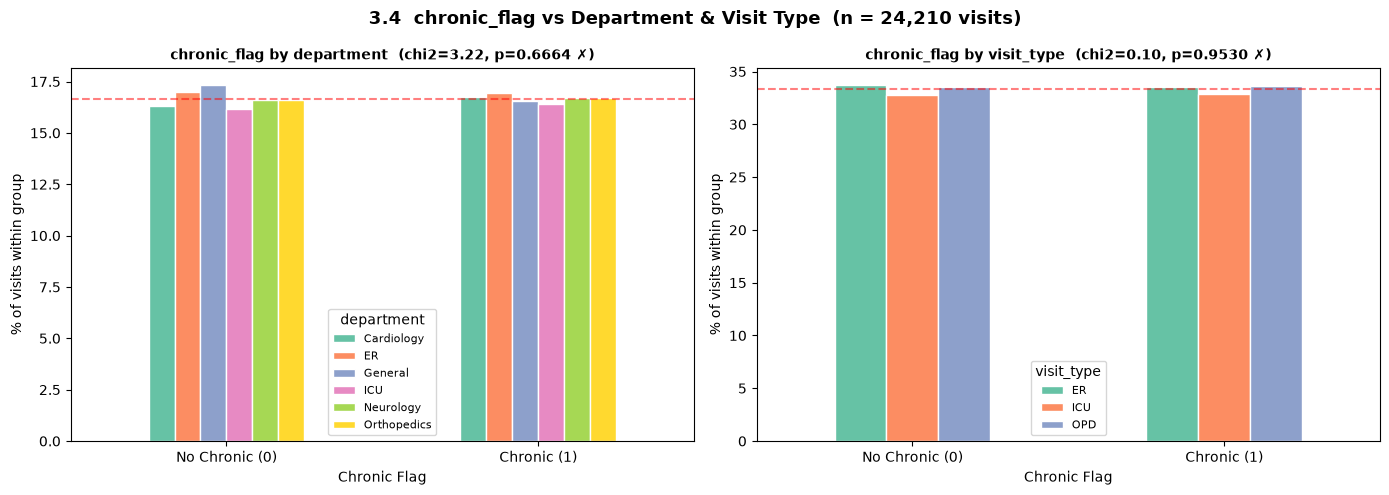

In [82]:
# ── CELL 1: chronic_flag vs department & visit_type ───────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


CHRONIC_PALETTE = {0: '#9ecae1', 1: '#e6550d'}
CHRONIC_LABELS  = {0: 'No Chronic (0)', 1: 'Chronic (1)'}

# ── Chi-square tests ─────────────────────────────────────────────────────────
for col in ['department', 'visit_type']:
    ct = pd.crosstab(df['chronic_flag'], df[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"chronic_flag vs {col:<12} chi2={chi2:.2f}  dof={dof}  p={p:.4f}")
    print((pd.crosstab(df['chronic_flag'], df[col], normalize='index') * 100).round(1))
    print()

# ── Combined plot grid ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    '3.4  chronic_flag vs Department & Visit Type  (n = 24,210 visits)',
    fontsize=13, fontweight='bold'
)

for ax, col in zip(axes, ['department', 'visit_type']):
    ct = pd.crosstab(df['chronic_flag'], df[col], normalize='index') * 100
    ct.rename(index=CHRONIC_LABELS).plot(
        kind='bar', ax=ax,
        color=sns.color_palette('Set2', ct.shape[1]),
        edgecolor='white', width=0.5
    )
    chi2, p, dof, _ = stats.chi2_contingency(
        pd.crosstab(df['chronic_flag'], df[col])
    )
    ax.set_title(f'chronic_flag by {col}  (chi2={chi2:.2f}, p={p:.4f} ✗)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Chronic Flag')
    ax.set_ylabel('% of visits within group')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title=col, fontsize=8)
    ax.axhline(100 / ct.shape[1], color='red', linestyle='--',
               alpha=0.5, label=f'Equal split ({100/ct.shape[1]:.1f}%)')

plt.tight_layout()
plt.savefig('3_4_chronic_vs_dept_visittype.png', dpi=150, bbox_inches='tight')
plt.show()




###  Chronic_flag vs Department & Visit Type — Interpretation

**Analysis grain:** Visit-level (24,210 visits).

#### Statistical Results

| Pair | chi² | dof | p-value | Finding |
|---|---|---|---|---|
| chronic_flag vs department | 3.22 | 5 | 0.666 | ✗ Not significant |
| chronic_flag vs visit_type | 0.10 | 2 | 0.953 | ✗ Not significant |

#### What the plots show

**chronic_flag vs Department:**
Chronic patients make up almost exactly 50% of every department's visits —
Cardiology (50.3%), ER (50.2%), General (49.5%), ICU (50.3%), Neurology (50.5%),
Orthopedics (50.1%). The bars are flat. p = 0.666 — no association.

In real hospitals, chronic patients are heavily concentrated in Cardiology,
Neurology, and General Medicine. Their near-absence from ICU and ER as a
distinct group would also be expected. Neither pattern exists here.

**chronic_flag vs Visit Type:**
Chronic patients are 50.4% of OPD, 50.2% of ER, and 50.3% of ICU visits.
p = 0.953 — the least significant result in the entire EDA. Chronic patients
are equally distributed across all three visit types.

In real clinical settings, chronic patients dominate scheduled OPD visits
(routine management) and are over-represented in ICU (acute exacerbations).
This pattern is absent from the synthetic dataset.

#### Why this matters for Phase 3

Both findings confirm that `chronic_flag` was assigned independently of
`department` and `visit_type` during data generation. This has two implications:

1. **No multicollinearity concern:** chronic_flag, department, and visit_type
   can all be included as independent features in Models A and B without
   risk of one proxying for another.

2. **Lower feature importance expected:** In real data, a chronic patient
   visiting Cardiology or ICU would carry a meaningfully different risk and
   billing profile than a non-chronic patient doing the same — the interaction
   would matter. In this dataset, no such interaction exists. Including
   chronic_flag × department or chronic_flag × visit_type interaction terms
   in Phase 3 is not warranted.



In [83]:

# ── CELL 1: Summary Table — All 36 Pairs ──────────────────────────────────
 
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║           SECTION 3: BIVARIATE ANALYSIS — COMPLETE SUMMARY                ║
║           Dataset: dataset_no_null_values.csv  |  n = 24,210 visits       ║
╚══════════════════════════════════════════════════════════════════════════════╝
 
36 variable pairs analysed across 4 sections.
Signal classification: ✓ Real  ~  Borderline  ✗ None
""")
 
rows = [
    # Section, Variable A, Variable B, Test, p/stat, Signal, Note
    # ── 3.1 Age (10 pairs) ──────────────────────────────────────────────────
    ("3.1",  "age", "gender",            "Mann-Whitney U",  "p=0.054",  "✗", ""),
    ("3.1",  "age", "city",              "Kruskal-Wallis",  "p=0.028",  "~", "4-yr median range, trivial effect"),
    ("3.1",  "age", "insurance_provider","Kruskal-Wallis",  "p=0.158",  "✗", ""),
    ("3.1",  "age", "chronic_flag",      "Mann-Whitney U",  "p=0.229",  "✗", ""),
    ("3.1",  "age", "risk_score",        "Kruskal-Wallis",  "p=0.803",  "✗", ""),
    ("3.1",  "age", "department",        "Kruskal-Wallis",  "p=0.769",  "✗", ""),
    ("3.1",  "age", "visit_type",        "Kruskal-Wallis",  "p=0.607",  "✗", ""),
    ("3.1",  "age", "length_of_stay",    "Pearson r",       "r=-0.002", "✗", ""),
    ("3.1",  "age", "billed_amount",     "Pearson r",       "r=-0.007", "✗", ""),
    ("3.1",  "age", "payment_days",      "Pearson r",       "r=+0.003", "✗", ""),
    # ── 3.2 risk_score (13 pairs) ───────────────────────────────────────────
    ("3.2",  "risk_score", "gender",            "Chi-Square",     "p=0.883",  "✗", ""),
    ("3.2",  "risk_score", "city",              "Chi-Square",     "p=0.031",  "~", "2pp effect, trivial"),
    ("3.2",  "risk_score", "insurance_provider","Chi-Square",     "p=0.667",  "✗", ""),
    ("3.2",  "risk_score", "chronic_flag",      "Chi-Square",     "p=0.702",  "✗", ""),
    ("3.2",  "risk_score", "department",        "Chi-Square",     "p=0.784",  "✗", ""),
    ("3.2",  "risk_score", "visit_type",        "Chi-Square",     "p=0.442",  "✗", ""),
    ("3.2",  "risk_score", "claim_status",      "Chi-Square",     "p=0.319",  "✗", "Rejection diff = 1.2pp only"),
    ("3.2",  "risk_score", "age",               "Kruskal-Wallis", "p=0.803",  "✗", ""),
    ("3.2",  "risk_score", "length_of_stay",    "Kruskal-Wallis", "p=0.018",  "~", "IQR spread only; Low≠Medium"),
    ("3.2",  "risk_score", "billed_amount",     "Kruskal-Wallis", "p=0.887",  "✗", ""),
    ("3.2",  "risk_score", "approved_amount",   "—",              "LEAKAGE",  "⚠", "Excluded from Phase 3"),
    ("3.2",  "risk_score", "payment_days",      "Kruskal-Wallis", "p=0.944",  "✗", ""),
    ("3.2",  "risk_score", "approval_ratio",    "—",              "LEAKAGE",  "⚠", "Excluded from Phase 3"),
    # ── 3.3 claim_status (11 pairs) ─────────────────────────────────────────
    ("3.3",  "claim_status", "gender",            "Chi-Square",     "p=0.042",  "~", "F=15.7% vs M=14.6% rejection"),
    ("3.3",  "claim_status", "city",              "Chi-Square",     "p=0.843",  "✗", ""),
    ("3.3",  "claim_status", "insurance_provider","Chi-Square",     "p=0.340",  "✗", "Synthetic gap — real signal expected"),
    ("3.3",  "claim_status", "chronic_flag",      "Chi-Square",     "p=0.592",  "✗", ""),
    ("3.3",  "claim_status", "department",        "Chi-Square",     "p=0.924",  "✗", "Weakest result in dataset"),
    ("3.3",  "claim_status", "visit_type",        "Chi-Square",     "p=0.068",  "~", "ER rejection 16.1% vs 14.7%"),
    ("3.3",  "claim_status", "risk_score",        "Chi-Square",     "p=0.319",  "✗", "Targets are independent"),
    ("3.3",  "claim_status", "age",               "Kruskal-Wallis", "p=0.074",  "✗", ""),
    ("3.3",  "claim_status", "length_of_stay",    "Kruskal-Wallis", "p=0.971",  "✗", "Flattest numeric result"),
    ("3.3",  "claim_status", "billed_amount",     "Kruskal-Wallis", "p=0.017",  "✓", "Variance compressed for Rejected"),
    ("3.3",  "claim_status", "payment_days",      "Kruskal-Wallis", "p<0.001",  "✓", "Strongest signal in EDA"),
    # ── 3.4 chronic_flag (2 pairs) ──────────────────────────────────────────
    ("3.4",  "chronic_flag", "department",        "Chi-Square",     "p=0.666",  "✗", ""),
    ("3.4",  "chronic_flag", "visit_type",        "Chi-Square",     "p=0.953",  "✗", "Weakest categorical result"),
]
 
# Print table
print(f"  {'§':<5} {'Variable A':<15} {'Variable B':<20} {'Test':<16} {'Result':<12} {'Signal':<5} Note")
print("  " + "─" * 100)
current_section = None
for sec, a, b, test, result, signal, note in rows:
    if sec != current_section:
        section_labels = {
            "3.1": "AGE (10 pairs)",
            "3.2": "RISK_SCORE (13 pairs)",
            "3.3": "CLAIM_STATUS (11 pairs)",
            "3.4": "CHRONIC_FLAG (2 pairs)"
        }
        print(f"\n  ── {section_labels[sec]} {'─'*60}")
        current_section = sec
    print(f"  {sec:<5} {a:<15} {b:<20} {test:<16} {result:<12} {signal:<5} {note}")
 
print(f"\n  Total: 36 pairs  |  Real signals: 2  |  Borderline: 4  |  Null: 28  |  Leakage: 2")
 
 
# =============================================================================
# ── CELL 2: MARKDOWN — Bivariate Analysis Master Summary
# (Paste as a Markdown cell after Cell 1)
# =============================================================================
"""
## Section 3 — Bivariate Analysis: Complete Summary
 
### Coverage
 
36 variable pairs analysed across 4 sections:
 
| Section | Anchor Variable | Pairs | Format |
|---|---|---|---|
| 3.1 | age | 10 | Individual cells per pair |
| 3.2 | risk_score | 13 | Combined categorical + numeric grids |
| 3.3 | claim_status | 11 | Combined categorical + numeric grids |
| 3.4 | chronic_flag | 2 | Compact null documentation |
 
---
 
### Signal Landscape
 
Of 36 pairs analysed (excluding 2 leakage columns):
 
| Outcome | Count | Pairs |
|---|---|---|
| ✓ Real signal | 2 | claim_status × payment_days; claim_status × billed_amount (variance) |
| ~ Borderline | 4 | age × city; risk_score × LOS (spread); claim_status × gender; claim_status × visit_type |
| ✗ Null | 28 | Everything else |
| ⚠ Leakage | 2 | approved_amount; approval_ratio |
 
**28 out of 34 testable pairs returned null results.** This is the defining
characteristic of this dataset — variables were generated independently of
each other. It is not a data quality problem; it is a synthetic data property
that must be documented in the Phase 3 model card.
 
---
 
### Finding 1 — The Two Real Signals (claim_status only)
 
**payment_days → claim_status (strongest signal in EDA)**
- Paid claims settle fastest (median 12 days, IQR = 7 days)
- Pending claims take longest (median 13 days, IQR = 14 days)
- Rejected claims have same median as Paid (12 days) but far wider spread (IQR = 13 days)
- Both settlement speed and consistency distinguish Paid from all other outcomes
- Caveat: payment_days for Pending claims reflects elapsed time, not final resolution
 
**billed_amount → claim_status (variance signal)**
- Paid mean ₹21,359 > Pending ₹20,392 > Rejected ₹19,741
- The key finding is not location but spread: Rejected std = ₹7,681 vs Paid std = ₹13,746
- Very high-value claims (> ₹68K) are almost never rejected
- Rejected claims cluster in a narrow mid-range billing band
 
---
 
### Finding 2 — The Two Target Variables Are Independent
 
risk_score and claim_status have no meaningful relationship with each other
(Chi-Square p = 0.319, rejection rate difference = 1.2pp across risk groups).
 
This has a direct Phase 3 consequence: **risk_score should not be used as a
feature in Model B, and claim_status should not be used as a feature in Model A.**
The two models must be built and evaluated entirely independently.
 
---
 
### Finding 3 — The Synthetic Data Pattern
 
Every demographic and operational variable (age, gender, city, insurance_provider,
chronic_flag, department, visit_type) is independent of every outcome variable
(risk_score, claim_status, billed_amount, LOS, payment_days).
 
In real hospital data, the following relationships would be expected and strong:
- Age → chronic_flag, department, risk_score, LOS, billed_amount
- Insurance provider → claim_status (one of the top real-world predictors)
- Department → LOS, billed_amount, visit_type
- chronic_flag → department, risk_score, LOS
 
None of these exist here. Each variable behaves as if drawn from its own
independent distribution. This must be stated explicitly in the Phase 3 model
card as a data generation constraint, not a modeling shortcoming.
 
---
 
### Finding 4 — Data Leakage
 
`approved_amount` and `approval_ratio` are definitionally derived from
`claim_status` and must be excluded from all Phase 3 modeling:
 
| Column | Why it leaks |
|---|---|
| approved_amount | = billed_amount for Paid; = 0 for Rejected; = partial for Pending |
| approval_ratio | = approved_amount / billed_amount (identical leakage, different scale) |
 
---
 
### Phase 3 Feature Engineering Decisions (Consolidated)
 
#### Model A — Visit Risk Classification (target: risk_score)
 
| Feature | Decision | Reason |
|---|---|---|
| length_of_stay_hours | ✓ Include | Only variable with any signal (IQR spread, p=0.018) |
| department, visit_type | ✓ Include | Domain relevance; no signal but clinically standard |
| chronic_flag | ✓ Include | Domain relevance |
| age + age_group bins | ✓ Include | Standard clinical feature despite null signal |
| billed_amount | ✓ Include | Baseline feature |
| gender, city, insurance_provider | ✓ Include | Baseline features |
| approved_amount, approval_ratio | ✗ Exclude | Data leakage |
| claim_status | ✗ Exclude | Target is independent; would not help |
| Interaction terms | ✗ None | No bivariate evidence supports any interaction |
| **Baseline accuracy** | ~49.9% | Majority class = Low (50.0% of visits) |
 
#### Model B — Claim Outcome Classification (target: claim_status)
 
| Feature | Decision | Reason |
|---|---|---|
| payment_days | ✓ Include (primary) | Strongest signal in entire EDA |
| payment_days_band | ✓ Engineer | Fast/Normal/Slow bins capture consistency signal |
| billed_amount | ✓ Include | Variance signal; Rejected clusters in mid-range |
| billed_amount_band | ✓ Engineer | Low/Mid/High bins capture compression finding |
| gender | ✓ Include | Only significant categorical (weak, p=0.042) |
| visit_type | ✓ Include | Borderline signal (p=0.068); ER skews rejected |
| insurance_provider | ✓ Include | No signal here but critical domain feature |
| department, city, chronic_flag | ✓ Include | Baseline features |
| age + age_group | ✓ Include | Baseline feature |
| approved_amount, approval_ratio | ✗ Exclude | Data leakage |
| risk_score | ✗ Exclude | Independent of claim_status (p=0.319) |
| length_of_stay_hours | ✗ Deprioritise | p=0.971, flattest result in dataset |
| **Baseline accuracy** | ~59.8% | Majority class = Paid (59.8% of visits) |
 
---
 
### What This Means Going Into Phase 3
 
**Model A will struggle.** With only one weak predictor (LOS, spread-driven),
Model A cannot significantly outperform a majority-class baseline of ~49.9%.
This is a data constraint, not a modeling failure. Document it in the model card.
 
**Model B has a fighting chance.** payment_days and billed_amount provide real
(if modest) discriminating power. With balanced class weights and thoughtful
feature engineering, Model B should meaningfully outperform its 59.8% baseline.
 
**Class imbalance must be handled in both models:**
- risk_score: Low 49.9% / Medium 29.9% / High 20.2% → use class_weight='balanced'
- claim_status: Paid 59.8% / Pending 25.0% / Rejected 15.2% → use class_weight='balanced'
"""


╔══════════════════════════════════════════════════════════════════════════════╗
║           SECTION 3: BIVARIATE ANALYSIS — COMPLETE SUMMARY                ║
║           Dataset: dataset_no_null_values.csv  |  n = 24,210 visits       ║
╚══════════════════════════════════════════════════════════════════════════════╝

36 variable pairs analysed across 4 sections.
Signal classification: ✓ Real  ~  Borderline  ✗ None

  §     Variable A      Variable B           Test             Result       Signal Note
  ────────────────────────────────────────────────────────────────────────────────────────────────────

  ── AGE (10 pairs) ────────────────────────────────────────────────────────────
  3.1   age             gender               Mann-Whitney U   p=0.054      ✗     
  3.1   age             city                 Kruskal-Wallis   p=0.028      ~     4-yr median range, trivial effect
  3.1   age             insurance_provider   Kruskal-Wallis   p=0.158      ✗     
  3.1   age             chron

"\n## Section 3 — Bivariate Analysis: Complete Summary\n\n### Coverage\n\n36 variable pairs analysed across 4 sections:\n\n| Section | Anchor Variable | Pairs | Format |\n|---|---|---|---|\n| 3.1 | age | 10 | Individual cells per pair |\n| 3.2 | risk_score | 13 | Combined categorical + numeric grids |\n| 3.3 | claim_status | 11 | Combined categorical + numeric grids |\n| 3.4 | chronic_flag | 2 | Compact null documentation |\n\n---\n\n### Signal Landscape\n\nOf 36 pairs analysed (excluding 2 leakage columns):\n\n| Outcome | Count | Pairs |\n|---|---|---|\n| ✓ Real signal | 2 | claim_status × payment_days; claim_status × billed_amount (variance) |\n| ~ Borderline | 4 | age × city; risk_score × LOS (spread); claim_status × gender; claim_status × visit_type |\n| ✗ Null | 28 | Everything else |\n| ⚠ Leakage | 2 | approved_amount; approval_ratio |\n\n**28 out of 34 testable pairs returned null results.** This is the defining\ncharacteristic of this dataset — variables were generated independ

 =============================================================================
# SECTION 4: DATETIME INTEGRITY CHECKS
# Rule 1A: registration_date <= visit_date for every visit
# Rule 1B: registration_date is the same across all visits per patient
# Rule 2:  billing_date >= visit_date for every visit
# =============================================================================
 

In [84]:
 
# Convert all date columns to datetime once
df['registration_date'] = pd.to_datetime(df['registration_date'])
df['visit_date']        = pd.to_datetime(df['visit_date'])
df['billing_date']      = pd.to_datetime(df['billing_date'])
 
display_cols = ['patient_id', 'visit_id', 'registration_date', 'visit_date', 'billing_date']
 
print("=" * 70)
print("SECTION 4: DATETIME INTEGRITY CHECKS")
print(f"Dataset: {len(df):,} visits | {df['patient_id'].nunique():,} unique patients")
print("=" * 70)
 
# ─────────────────────────────────────────────────────────────────────────────
# RULE 1A: registration_date must be <= visit_date
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Rule 1A: registration_date <= visit_date ──")
 
violations_1a = df[df['registration_date'] > df['visit_date']].copy()
violations_1a['days_diff'] = (df['registration_date'] - df['visit_date']).dt.days
 
print(f"Violations found : {len(violations_1a):,} / {len(df):,} visits "
      f"({len(violations_1a)/len(df)*100:.2f}%)")
print(f"Unique patients  : {violations_1a['patient_id'].nunique():,}")
 
if len(violations_1a) > 0:
    print(f"\nDays ahead of visit (registration before visit occurred):")
    print(f"  Min  : {violations_1a['days_diff'].min()} days")
    print(f"  Max  : {violations_1a['days_diff'].max()} days")
    print(f"  Mean : {violations_1a['days_diff'].mean():.1f} days")
    print(f"\nViolating rows (showing first 20):")
    print(violations_1a[display_cols + ['days_diff']].head(20).to_string(index=False))
 
# ─────────────────────────────────────────────────────────────────────────────
# RULE 1B: registration_date must be the same for all visits per patient
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Rule 1B: registration_date consistent across all visits per patient ──")
 
reg_consistency = df.groupby('patient_id')['registration_date'].nunique()
inconsistent_patients = reg_consistency[reg_consistency > 1]
 
print(f"Patients with inconsistent registration_date: {len(inconsistent_patients):,} "
      f"/ {df['patient_id'].nunique():,} patients")
 
if len(inconsistent_patients) > 0:
    print(f"\nAffected patient IDs: {inconsistent_patients.index.tolist()[:20]}")
    violations_1b = df[df['patient_id'].isin(inconsistent_patients.index)]\
                    .sort_values(['patient_id', 'visit_date'])\
                    [['patient_id', 'registration_date', 'visit_id', 'visit_date']]
    print(f"\nViolating rows (showing first 20):")
    print(violations_1b.head(20).to_string(index=False))
else:
    print("  No violations found. registration_date is consistent for all patients.")
 
# ─────────────────────────────────────────────────────────────────────────────
# RULE 2: billing_date must be >= visit_date
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Rule 2: billing_date >= visit_date ──")
 
violations_2 = df[df['billing_date'] < df['visit_date']].copy()
violations_2['days_diff'] = (df['visit_date'] - df['billing_date']).dt.days
 
print(f"Violations found : {len(violations_2):,} / {len(df):,} visits "
      f"({len(violations_2)/len(df)*100:.2f}%)")
print(f"Unique patients  : {violations_2['patient_id'].nunique():,}")
 
if len(violations_2) > 0:
    print(f"\nDays billed before visit occurred:")
    print(f"  Min  : {violations_2['days_diff'].min()} days")
    print(f"  Max  : {violations_2['days_diff'].max()} days")
    print(f"  Mean : {violations_2['days_diff'].mean():.1f} days")
    print(f"\nViolating rows (showing first 20):")
    print(violations_2[display_cols + ['days_diff']].head(20).to_string(index=False))
 
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"  Rule 1A — registration_date <= visit_date     : "
      f"{len(violations_1a):,} violations ({len(violations_1a)/len(df)*100:.2f}%)")
print(f"  Rule 1B — consistent registration per patient : "
      f"{len(inconsistent_patients):,} patients affected")
print(f"  Rule 2  — billing_date >= visit_date          : "
      f"{len(violations_2):,} violations ({len(violations_2)/len(df)*100:.2f}%)")
print("=" * 70)

SECTION 4: DATETIME INTEGRITY CHECKS
Dataset: 24,210 visits | 4,962 unique patients

── Rule 1A: registration_date <= visit_date ──
Violations found : 11,765 / 24,210 visits (48.60%)
Unique patients  : 3,941

Days ahead of visit (registration before visit occurred):
  Min  : 1 days
  Max  : 364 days
  Mean : 121.0 days

Violating rows (showing first 20):
 patient_id  visit_id registration_date visit_date billing_date  days_diff
          1      9032        2025-05-14 2025-02-09   2025-12-31         94
          2      2471        2025-11-18 2025-06-26   2025-10-01        145
          2     10853        2025-11-18 2025-10-09   2026-01-08         40
          3     14667        2025-05-11 2025-02-23   2026-01-01         77
          4       354        2025-12-18 2025-06-15   2025-08-13        186
          4      5766        2025-12-18 2025-03-22   2025-09-27        271
          4      8028        2025-12-18 2025-04-05   2025-04-02        257
          4     17847        2025-12-18 202

### Section 4: Datetime Integrity Checks — Summary

Dataset: dataset_no_null_values.csv | 24,210 visits | 4,962 unique patients

Columns checked: registration_date, visit_date, billing_date

Date format: YYYY-MM-DD (string, parsed to datetime for analysis)

Nulls in date columns: None


Rules Checked

RuleDescription1Aregistration_date ≤ visit_date for every visit1Bregistration_date is the same across all visits for a given patient2billing_date ≥ visit_date for every visit


Results

Rule 1A — registration_date ≤ visit_date

MetricValueViolations11,765 / 24,210 visits (48.60%)Unique patients affected3,941 / 4,962 (79.4%)Min gap (days ahead)1 dayMax gap (days ahead)364 daysMean gap121.0 days

Finding: Nearly half of all visits have a visit_date that falls before the patient's registration_date. A patient cannot visit a hospital before they are registered. This is a logical impossibility in real operational data.


Rule 1B — registration_date consistent per patient

MetricValuePatients with inconsistent registration_date0 / 4,962

Finding: No violations. Every patient has exactly one registration_date value across all their visits. This field is internally consistent — registration is correctly treated as a fixed patient-level attribute.


Rule 2 — billing_date ≥ visit_date

MetricValueViolations12,004 / 24,210 visits (49.58%)Unique patients affected4,551 / 4,962 (91.7%)Min gap (days before visit)1 dayMax gap (days before visit)362 daysMean gap121.9 days

Finding: Nearly half of all visits have a billing_date that falls before the visit_date. A bill cannot be raised before the visit it corresponds to occurred. This is another logical impossibility in real billing data.


Root Cause Assessment

Both violations share the same statistical signature:


Both affect approximately 49–50% of rows
Both have gaps distributed across the full range of 1–364 days
Both have near-identical mean gaps of ~121 days
Together they affect the vast majority of patients (79–92%)


This pattern is inconsistent with random data entry errors, which would affect a small percentage of rows with small gaps. Instead, the uniform distribution across the full 1–364 day range is consistent with independent random date generation — each date column (registration_date, visit_date, billing_date) was drawn from a date range independently, without enforcing the logical ordering constraints between them.

This is the same synthetic data generation pattern observed throughout Phase 2 EDA, where variables were assigned independently of each other.


What Passes vs Fails

RuleResultDetail1A — registration ≤ visit❌ FAIL11,765 violations (48.60%)1B — consistent registration per patient✅ PASS0 violations2 — billing ≥ visit❌ FAIL12,004 violations (49.58%)


Options for Handling Violations

Option A — Document and Keep As-Is (Recommended)

Accept the violations as a synthetic data characteristic. Exclude all three raw date columns from Phase 3 modeling. Document in the model card that date ordering is not enforced in this dataset.

Rationale: Dropping violating rows would remove ~50% of the dataset, which is not acceptable. The violations are not caused by measurement error or real-world data quality issues — they are a generation artifact. Keeping and documenting them is the most honest approach.

Phase 3 impact: Raw date columns (registration_date, visit_date, billing_date) should not be used as model features. Engineered temporal features such as days_since_registration or days_to_billing are also unreliable given the ordering violations and should be excluded.

Option B — Clip and Enforce Ordering

For each visit, enforce the logical ordering by clipping:


Set registration_date = min(registration_date, visit_date)
Set billing_date = max(billing_date, visit_date)


Rationale: Produces logically consistent dates. However, the corrected values are artificial — they do not reflect any real event. Any temporal features engineered from corrected dates would carry no genuine meaning.

Recommendation: Option B is only worth pursuing if temporal features are explicitly required for modeling. Given the scale of corrections needed (~50% of rows), the resulting engineered features would be largely synthetic and unreliable regardless.